# Advanced Topics in Spatial Analysis

**Topics** Local models - GWR/MGWR, spatial feature engineering, spatial machine learning and spatial/block validation

## Orientation

This notebook is the hands-on companion to the advanced session of the Spatial Econometrics module. The theoretical backbone of the previous sessions — spatial weights, Moran's I, OLS failure modes in space, the SAR/SEM/SLX/SDM taxonomy, and the LeSage–Pace impact decomposition — provided tools for modelling **spatial dependence**: the idea that a housing price in zone *i* is influenced by prices in neighbouring zones *j*. Here we pivot to a complementary challenge: **spatial heterogeneity**.

Spatial heterogeneity means that the relationship between price and its determinants is not the same everywhere. The coefficient on living area or condition may be larger in the city centre than in the periphery, not because of spillovers, but because buyers in different submarkets apply structurally different valuations. Geographically Weighted Regression (GWR) and its multi-scale extension MGWR are the most widely used local models for visualising this heterogeneity. Spatial feature engineering and spatial machine learning offer complementary predictive approaches that exploit geographic structure without imposing a specific parametric model.

The lab includes two case studies / tracks. **Track A** works with listing-level point data for Aveiro and Ílhavo, focusing on local modelling ideas and spatial validation. **Track B** uses a national municipal analytical layer to illustrate how the same questions look when the spatial unit shifts from point listings to areal polygons, but, in this case, focusing only on the topic of spatial validation. 

The notebook is intentionally **code-light**. Reusable loading, preparation, plotting, weights, modelling, and reporting logic lives in `ete_packages.lab4_package`. The key skill practised here is **interpretation under uncertainty**: reading diagnostic output and resisting the temptation to claim more than the data and design support.

> **Connection to prior labs.** In Lab 3 you estimated global spatial models and decomposed spatial impacts using the LeSage–Pace framework. Here you ask a harder question: are those impacts actually uniform across space? And if local models are better at prediction, does that mean they have identified causal heterogeneity — or are they simply more flexible approximations of an unknown functional form?

## Learning Objectives

By the end of the lab, you should be able to:

1. distinguish **spatial heterogeneity** from **spatial dependence** and explain why the distinction determines which modelling strategy is appropriate;
2. explain the intuition behind GWR — why a bandwidth-weighted local estimator can reveal coefficient instability — and state at least three reasons why that instability may not reflect genuine causal heterogeneity;
3. explain why GWR/MGWR coefficient surfaces and improved predictive fit are **exploratory findings**, not causal evidence of heterogeneous treatment effects;
4. build transparent spatial features (projected coordinates, distances, zone summaries) and identify which features introduce **target leakage** when used inside a cross-validation loop;
5. introduce spatial data science (apply machine learning to spatial data) and explain how it differs from spatial econometrics (parametric models with spatial dependence);
6. compare **random cross-validation** with **spatial or group-blocked validation** and explain why the latter provides a stricter test of geographic generalisation;
7. diagnose whether cross-validated prediction residuals remain spatially autocorrelated, and state what that implies for the model's handling of geographic structure;
8. contrast a listing-level point workflow with a municipality-level areal workflow and identify the MAUP and ecological-fallacy risks that arise when moving across spatial scales.

## Roadmap

| Block | Main output | Main caution |
|---|---:|---|
| Setup and input inventory | paths, package API, layer inventory, CRS and row counts | never assume layer names, CRS, or row counts |
| Technical notes / Theoretical bridge | global/local modelling framework | heterogeneity ≠ spillover; local fit ≠ local causality |
| **Track A** — Aveiro–Ílhavo housing market | listing-level; asking prices not market prices | — |
| a. Spatial feature engineering | transparent location/context features | target summaries leak validation information if computed globally |
| b. Spatial weights and exploratory diagnostics | Moran's I, LISA, weights suite | expected value of Moran's I ≠ 0 |
| c. Global reference model | benchmark fit and residual diagnostics | a better in-sample fit is not causal evidence |
| d. Local model (GWR/MGWR) | local-coefficient surfaces or documented skip | local maps are fragile without bandwidth diagnostics |
| e. Spatial data science: ML models and spatial validation | RF and LightGBM fit, feature importances, random vs spatial CV, residual Moran diagnostics | random CV overstates geographic generalisation |
| **Track B** — mainland Portugal municipalities | aggregate-unit workflow | MAUP and ecological fallacy risks |
| a. Municipal blocked-validation | NUTS-3 block CV and spatial cluster CV | aggregate units change the estimand |
| b. NUTS-III region fixed effects | spatial heterogeneity fix at regional scale | absorbs cross-region variation; reduces generalisability |
| **Comparative Synthesis** | Track A vs Track B contrasts | different scales answer different questions |
| Final remarks | — | — |


## Key concepts from previous labs

Throughout the lab, keep four distinctions active at all times:

1. **Spatial dependence vs spatial heterogeneity:** spatial dependence encompasses two structurally different mechanisms. *Substantive contagion* (SAR): nearby prices directly pull each other, $y_i = \rho \sum_j w_{ij} y_j + \mathbf{x}_i^\top \boldsymbol{\beta} + \varepsilon_i$. *Nuisance clustering* (SEM): residuals are spatially correlated because omitted variables are spatially structured, not because prices causally interact — $\boldsymbol{\varepsilon} = \lambda W\boldsymbol{\varepsilon} + \mathbf{u}$. Both are addressed by global spatial models from Lab 3. **Spatial heterogeneity** is a different challenge: the *structural parameters* $\hat{\boldsymbol{\beta}}$ themselves vary across space — the marginal effect of an extra square metre differs between the city centre and the periphery. GWR addresses heterogeneity, not dependence; addressing one does not resolve the other. Both mechanisms can coexist, and conflating them leads to misspecified models and incorrect policy interpretations.
2. **Autocorrelation vs spillovers:** spatial autocorrelation in prices or residuals is a statistical pattern; causal spillovers require a substantive mechanism, an appropriate identification strategy, and an estimand that is not confounded by shared unobservables.
3. **Point data vs areal data:** listings and municipalities are different units of analysis with different error structures, different W matrices, and different interpretations. Never mix their outputs as if they measured the same thing.
4. **Prediction vs explanation:** good out-of-sample prediction performance does not identify causal effects. A random forest that uses spatial coordinates as features may predict well precisely because it is memorising location — not because it has learned anything about the market mechanism.

## Setup

### Setup: Imports, Deterministic Seed, and Paths

The first code cell imports the package and defines the minimal notebook-level configuration. Two coordinate reference systems are used throughout:

- **EPSG:3763 (PT-TM06-ETRS89)** is the projected CRS for all distance, area, nearest-neighbour, and spatial-clustering operations in Portugal. It uses metres as the unit of measurement, which is required for computing geographic distances, kernel bandwidths in GWR, and spatial cluster radii.
- **EPSG:4326 (WGS 84 / longitude-latitude)** is the geographic CRS used in the raw listing data for storage and web display. It is **not** suitable for metric distance operations: one degree of longitude near 40 °N spans approximately 85 km, while one degree of latitude spans approximately 111 km, so distances expressed in decimal degrees are not comparable across directions.

All spatial layers are reprojected to EPSG:3763 before any spatial operation.

> **Why the seed matters.** `RANDOM_STATE = 20260521` fixes the random number generator for all operations that involve randomisation: spatial cluster construction (k-means), cross-validation fold assignment, and permutation tests for Moran's I. Without a fixed seed, two runs of the same notebook would produce different fold assignments and slightly different permutation p-values, making results non-reproducible. Always record the seed alongside your results.

In [69]:
from __future__ import annotations
import sys
from pathlib import Path
import pandas as pd

# ---- Bootstrap: locate project root so ete_packages is importable ----
_BOOT_MARKERS = ["README.md", "data", ".git"]
def _find_root(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if any((p / m).exists() for m in _BOOT_MARKERS):
            return p
    return start.resolve()

_PROJECT_ROOT_BOOT = _find_root(Path.cwd())
if str(_PROJECT_ROOT_BOOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT_BOOT))

from ete_packages import lab4_package as lab4
from ete_packages.lab4_package.paths import find_project_root

PROJECT_ROOT = find_project_root(Path.cwd())
RANDOM_STATE = 20260521
PERMUTATIONS = 199  # Classroom default; increase to 999 for final reporting.
METRIC_CRS = "EPSG:3763"
RAW_GEOGRAPHIC_CRS = "EPSG:4326"

DATA_DIR = PROJECT_ROOT / "data"
if not (DATA_DIR / "ETE_Lab.gpkg").exists():
    DATA_DIR = Path("/mnt/data")

OUTPUT_DIR = Path("outputs/topic4")
print(f"Project root   : {PROJECT_ROOT}")
print(f"Data directory : {DATA_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR}")


Project root   : E:\OneDrive\TRABALHO_AULAS\AL20252026\2S_MstCDCS_ETE\projETE
Data directory : E:\OneDrive\TRABALHO_AULAS\AL20252026\2S_MstCDCS_ETE\projETE\data
Output directory: outputs\topic4


#### Interpreting the Setup Output

**What to check:** The resolved `Project root` path should point to the root of the course repository — the directory containing `README.md`, `data/`, `notebooks/`, and `ete_packages/`. The `Data directory` should point to the `data/` subfolder. If either path is unexpected, stop here: all subsequent file paths are derived from `PROJECT_ROOT`, and a wrong root will silently load data from the wrong location.

**Common failure modes:**
- If `PROJECT_ROOT` resolves to a temp or home directory, the bootstrap marker `README.md` was not found in any parent of `Path.cwd()`. Place the notebook inside the repository tree and re-run.
- If `DATA_DIR` falls back to `/mnt/data`, no `ETE_Lab.gpkg` was found under the resolved project root. Verify that the GeoPackage has been placed in the `data/` subfolder.

**What this run found:** `Project root` resolved correctly to the course repository. `Data directory` pointed to the project `data/` subfolder. `Output directory` was set to `outputs/topic4/`, which will be created on first export.

### Path Verification

Before reading spatial layers, verify that the expected files exist. A missing documentation file (`primeyield_schema`, `municipality_metadata`) reduces interpretability but does not block analysis. A missing GeoPackage (`gpkg`) blocks everything. Missing files must be reported as part of the reproducibility record: a result obtained without the documented data files cannot be verified or reproduced.

The `check_file_availability` function returns file size in bytes alongside the existence flags. A GeoPackage that exists but has an unexpectedly small size (e.g., a few kilobytes) is likely a placeholder or an incomplete transfer — always cross-check against the documented size.

In [70]:
PATHS = {
    "gpkg": DATA_DIR / "ETE_Lab.gpkg",
    "primeyield_schema": DATA_DIR / "dbPrimeYield_AVRILH_ETE_schema.md",
    "municipality_metadata": DATA_DIR / "CAOP24_CONT_MUNI_metadata.md",
    "books_map": DATA_DIR / "books_maping.md",
    "contract": DATA_DIR / "global_course_content_contract.md",
}

file_status = lab4.check_file_availability(PATHS)
file_status


,key,path,exists,is_file,size_bytes,suffix
0,gpkg,E:\OneDrive\TRABALHO_AULAS\AL20252026\2S_MstCD...,True,True,41619456.0,.gpkg
1,primeyield_schema,E:\OneDrive\TRABALHO_AULAS\AL20252026\2S_MstCD...,True,True,7904.0,.md
2,municipality_metadata,E:\OneDrive\TRABALHO_AULAS\AL20252026\2S_MstCD...,True,True,16651.0,.md
3,books_map,E:\OneDrive\TRABALHO_AULAS\AL20252026\2S_MstCD...,False,False,NaN,None
4,contract,E:\OneDrive\TRABALHO_AULAS\AL20252026\2S_MstCD...,False,False,NaN,None


#### Interpreting the Path Verification Output

**What to read:** Inspect `exists`, `is_file`, and `size_bytes` for each file. The GeoPackage (`gpkg`) must exist and have a non-trivial file size. Metadata files support interpretation and schema consistency checks; their absence is a documentation gap, not an analysis blocker.

**What this run found:** The GeoPackage `ETE_Lab.gpkg` was found at approximately 41.6 MB, confirming it is a substantive spatial database rather than a placeholder. Two supporting documents — `books_maping.md` and `global_course_content_contract.md` — were absent. These files are optional reading aids; their absence does not affect the modelling workflow. The two schema documents (`primeyield_schema` and `municipality_metadata`) were present and available for column-level checks in Section 5.

**Implication for reproducibility:** results produced in a session where schema files are missing cannot be cross-validated against the documented variable definitions. Any deviation between runtime column names and the schema must be flagged explicitly.

### GeoPackage Layer Inventory

A GeoPackage is a portable SQLite spatial database that can store multiple layers with different geometry types, coordinate systems, and units of analysis. Hard-coding layer names, CRS codes, or row counts is a reproducibility error: future data updates may add, rename, or remove layers.

Inspecting the GeoPackage before analysis serves two purposes:

1. **Confirmation:** verify that expected layers exist under the anticipated names, that geometry types match the analytical role (Point for listings, Polygon/MultiPolygon for zones and municipalities), and that row counts are consistent with the documented dataset.
2. **Discovery:** identify unexpected layers, CRS mismatches, or row-count discrepancies that may signal a data update, a filtered export, or a packaging error.

For this lab, the expected roles are:
- **listings:** listing-level point data for Aveiro-Ílhavo;
- **zones:** sub-municipal zone polygons for aggregation and group-block validation;
- **parishes:** parish polygons for optional grouped validation;
- **municipalities:** mainland Portugal municipal polygons for Track B.

In [71]:
LAYER_HINTS = {
    "listings": "PrimeYield_HousingListingsDataClean",
    "zones": "M0105_M0110_C2021_e_casasapo_ZonesPlaces_clean",
    "parishes": "BGRI21_CONT_FREG_0105_0110",
    "municipalities": "CAOP24_CONT_MUNI",
}

inventory = lab4.inspect_geopackage(PATHS["gpkg"], layer_hints=LAYER_HINTS)
inventory[["layer", "role_hint", "geometry_type", "crs", "row_count", "candidate_keys"]]


,layer,role_hint,geometry_type,crs,row_count,candidate_keys
0,PrimeYield_HousingListingsDataClean,listings,Point,EPSG:4326,1095,"[listing_id, zone_id]"
1,M0105_M0110_C2021_e_casasapo_ZonesPlaces_clean,zones,MultiPolygon,EPSG:3763,104,[zone_id]
2,BGRI21_CONT_FREG_0105_0110,parishes,Polygon,EPSG:3763,14,"[DTMN21, DTMNFR21]"
3,cont_municipios,None,MultiPolygon,EPSG:3763,278,[dtmn]
4,CAOP24_CONT_MUNI,municipalities,MultiPolygon,EPSG:3763,278,"[dtmn, geo]"


#### Interpreting the Layer Inventory Output

**What to read:** Check the layer name, role hint, geometry type, CRS, row count, and candidate join keys. Pay particular attention to which layer is stored in geographic CRS (EPSG:4326) versus projected CRS (EPSG:3763), as this determines which layers require reprojection before metric operations.

**What this run found:** Five layers were detected. The listings layer (`PrimeYield_HousingListingsDataClean`) is a **Point** layer in **EPSG:4326** with 1 095 rows — it must be reprojected to EPSG:3763 before any distance or nearest-neighbour computation. All polygon layers (zones, parishes, `cont_municipios`, and `CAOP24_CONT_MUNI`) are already in EPSG:3763. Two municipality layers were present (`cont_municipios` and `CAOP24_CONT_MUNI`, both 278 rows); the package selects `CAOP24_CONT_MUNI` as the canonical layer. The zone layer has 104 rows against a documented 131 — Section 5 investigates this discrepancy.

**CRS implications:** metric operations — distances to reference centres, kNN weights, zone area in km² — are only valid after reprojection to a projected CRS. The package handles this automatically via `load_layers`, but the inventory confirms it is needed for the listings layer.

### Schema-Note Comparison

The schema markdown documents describe the *intended* teaching dataset at the time of preparation. The GeoPackage inventory reports the *actual* runtime file. If they disagree, the GeoPackage is the modelling source of truth, but mismatches must be reported and explained.

Two types of mismatches matter:
- **Row-count mismatches:** the runtime layer has fewer rows than documented. This may reflect data cleaning applied after documentation was written, a licensing filter, or a partial export. It does not invalidate analysis, but it affects statistical power and comparability with documented summaries.
- **Column mismatches:** a documented variable is absent from the runtime layer, or vice versa. Column-level mismatches directly affect which covariates can be used in the model specification.

In [72]:
schema_check = lab4.compare_inventory_to_schema_notes(
    inventory=inventory,
    schema_path=PATHS["primeyield_schema"],
    municipality_metadata_path=PATHS["municipality_metadata"],
)
schema_check


,source,item,runtime_value,documented_value,status
0,PrimeYield schema note,PrimeYield_HousingListingsDataClean,1095,1184,check
1,PrimeYield schema note,M0105_M0110_C2021_e_casasapo_ZonesPlaces_clean,104,131,check
2,municipality metadata note,rent_median_eur_m2_2023,True,True,match
3,municipality metadata note,sales_median_eur_m2_2024_total,True,True,match
4,municipality metadata note,sales_median_eur_m2_2024_new,True,True,match
5,municipality metadata note,sales_median_eur_m2_2024_existing,True,True,match


#### Interpreting the Schema Comparison Output

**What to read:** Rows with `status = check` identify differences between documented counts/variables and the loaded GeoPackage. Rows with `status = match` confirm that the runtime data agrees with the schema.

**What this run found:** Two `check` rows indicate row-count discrepancies. The listings layer has **1 095 runtime rows vs. 1 184 documented rows** — a reduction of 89 listings (~7.5%). The zones layer has **104 runtime rows vs. 131 documented rows** — a reduction of 27 zones (~21%). Both reductions are consistent with data-cleaning operations applied after the schema was documented: removal of listings with invalid coordinates, extreme price outliers, or missing key variables; and removal of zones outside the Aveiro-Ílhavo study boundary or with insufficient listings. The four municipal-level variables all matched between schema and runtime.

**Modelling implication:** all subsequent analyses use the 1 095-row runtime file. The zone reduction from 131 to 104 means some zones documented earlier are absent here. This must be acknowledged when comparing results with published summaries using the full 131-zone layer.

### Load Validated Topic Layers

The package loads topic layers and reprojects them where necessary. All layers exit this step in **EPSG:3763** so that every subsequent spatial operation — distance measurement, spatial join, weights construction, feature engineering — uses the same metric coordinate system.

Reprojection is not a rounding operation: it changes the coordinate values of every geometry vertex. A listing at longitude −8.65°, latitude 40.64° (EPSG:4326) becomes approximately (−24 530 m, −110 430 m) in EPSG:3763. Distances computed before reprojection using degree-based coordinates would be meaningless as metric quantities. The package verifies that all loaded layers share `EPSG:3763` before returning them.

In [73]:
layers = lab4.load_layers(
    gpkg_path=PATHS["gpkg"],
    layer_hints=LAYER_HINTS,
    metric_crs=METRIC_CRS,
    raw_geographic_crs=RAW_GEOGRAPHIC_CRS,
)

{key: (len(value), str(value.crs)) for key, value in layers.items()}


{'listings': (1095, 'EPSG:3763'),
 'zones': (104, 'EPSG:3763'),
 'parishes': (14, 'EPSG:3763'),
 'municipalities': (278, 'EPSG:3763')}

#### Interpreting the Load Output

**What to read:** Check that all expected layer keys are present (`listings`, `zones`, `parishes`, `municipalities`), that row counts match the runtime inventory from Section 4, and that all CRS values report `EPSG:3763`.

**What this run found:** All four layers loaded successfully. Row counts — **1 095 listings**, **104 zones**, **14 parishes**, **278 municipalities** — match the inventory from Section 4, confirming that the loading step introduced no additional filtering. Every layer reports `EPSG:3763`, meaning all metric operations in subsequent cells are geometrically consistent.

**Why this matters:** if a layer were still in EPSG:4326 at this stage, distance-based spatial features (e.g., distance to Aveiro city centre in kilometres) would be computed in decimal degrees, producing nonsensical values. The CRS check is a mandatory gate before any spatial computation.

## Technical Notes 


### Global models and their limitations

A **global regression** estimates one coefficient per covariate for the whole study area. In the context of Lab 3, the global Spatial Durbin Model produced a single $\hat{\rho}$ for price contagion and a single $\hat{\beta}$ for the effect of living area — implying that the price-area relationship is identical in Aveiro's historic centre and in Ílhavo's coastal periphery. This is the **stationarity assumption**: structural parameters do not vary across space.

For housing markets, stationarity is often implausible. Buyers in different submarkets respond differently to the same property attribute. A square metre of living space in a waterfront zone commands a different marginal price than the same square metre in a suburban zone, not because prices spill over between zones (the dependence mechanism from Lab 3) but because the market itself is **segmented** — buyers and sellers in different areas face structurally different supply and demand conditions.

### Geographically Weighted Regression (GWR)

GWR relaxes the stationarity assumption by estimating a separate coefficient vector at each observation location $(u_i, v_i)$. At each location, observations are weighted by a function of their geographic distance from $(u_i, v_i)$:

$$\hat{\boldsymbol{\beta}}(u_i, v_i) = \left( X^\top W_i X \right)^{-1} X^\top W_i y$$

where $W_i = \text{diag}[w_{i1}, w_{i2}, \ldots, w_{in}]$ is a diagonal weighting matrix specific to location $i$. A common choice is the **bisquare kernel**, which assigns exactly zero weight to observations beyond bandwidth $h$:

$$w_{ij} = \left[1 - \left(\frac{d_{ij}}{h}\right)^2\right]^2 \cdot \mathbf{1}(d_{ij} < h)$$

The **bandwidth** $h$ controls how rapidly weights decay with distance. A small bandwidth produces highly local estimates sensitive to nearby data composition; a large bandwidth approaches the global OLS estimate. The formula above presents the **fixed-radius** form for conceptual clarity. In practice, the code uses an **adaptive** bandwidth parameterised by a number of nearest neighbours, so the search radius contracts in dense urban clusters and expands in sparse rural areas (the adaptive form is detailed in the GWR Technical Notes later in the lab). **Bandwidth selection** is the critical practical decision in GWR: it is typically performed by minimising **AICc** (corrected Akaike Information Criterion) over a grid of candidate bandwidths.

### MGWR: multi-scale bandwidth

**MGWR** (Multiscale GWR) extends GWR by allowing each covariate $k$ to operate at its own bandwidth $h_k$. This is theoretically attractive: the effect of building condition may be highly localised (buyers inspect individual units), while the effect of proximity to the Ria de Aveiro may operate at a broader regional scale. The trade-off is a heavier diagnostic burden and greater risk of over-fitting in small samples.

### Predictive models and spatial validation

A **predictive model** asks: how well can we predict the price of a held-out listing, given its characteristics and location? This is a different question from explanation or causal identification. The critical challenge is **spatial leakage in cross-validation**: when training and validation sets are constructed by random splits, nearby listings often appear in both sets. A model with spatial coordinates as features can achieve low validation error simply by interpolating from spatially close training observations — not because it has learned the price-formation mechanism.

**Spatial or group-blocked cross-validation** — where entire zones, parishes, or spatial clusters are held out together — provides a stricter test: can the model generalise to locations it has never seen?

> **Key caution.** GWR local coefficient maps, improved predictive fit under spatial features, and reduced residual autocorrelation are all consistent with the presence of spatial heterogeneity. But they are equally consistent with unobserved confounding, functional-form misspecification, or sample-composition effects. None of these findings, on their own, constitute causal evidence of heterogeneous treatment effects.

### Ridge Regression: penalising the size of coefficients

#### The core idea — a model that doubts its own enthusiasm

Ordinary Least Squares (OLS) finds the coefficient vector $\hat{\boldsymbol{\beta}}$ that minimises the sum of squared prediction errors on the training data:

$$\hat{\boldsymbol{\beta}}_{\text{OLS}} = \arg\min_{\boldsymbol{\beta}} \sum_{i=1}^{n}\bigl(y_i - \mathbf{x}_i^\top\boldsymbol{\beta}\bigr)^2$$

OLS is unbiased: given enough data, it recovers the true coefficients in expectation. But "unbiased" does not mean "reliable". When predictors are highly correlated — or when there are many predictors and relatively few observations — OLS estimates can swing wildly from one sample to the next. The model fits the available data very well but generalises poorly to new data.

**Ridge regression** (Tikhonov regularisation) modifies the objective by adding a penalty proportional to the *sum of squared coefficient magnitudes*:

$$\hat{\boldsymbol{\beta}}_{\text{Ridge}} = \arg\min_{\boldsymbol{\beta}} \underbrace{\sum_{i=1}^{n}\bigl(y_i - \mathbf{x}_i^\top\boldsymbol{\beta}\bigr)^2}_{\text{fit}} + \underbrace{\lambda \sum_{k=1}^{p}\beta_k^2}_{\text{penalty}}$$

The parameter $\lambda \geq 0$ is the **regularisation strength** (sometimes called the shrinkage parameter). It controls the trade-off between fitting the data and keeping coefficients small:

- When $\lambda = 0$, the penalty disappears and Ridge reduces to OLS.
- As $\lambda \to \infty$, all coefficients are forced to zero and the model predicts the unconditional mean of $y$ for every observation.
- At intermediate values, coefficients are *shrunk towards zero* relative to their OLS counterparts — the model accepts a small amount of systematic bias in exchange for substantially reduced variance.

**Non-technical analogy.** Imagine grading an essay competition. OLS is a judge who maximises fit to the students she has already seen: she gives extreme scores (very high or very low) whenever even small details distinguish essays. Ridge is a judge who also imposes a penalty for giving extreme scores — she will still distinguish good from bad essays, but she will not award a 98/100 to an essay just because it slightly outperformed the sample. Ridge's scores are more moderate and more stable across different exam cohorts.

The closed-form solution reveals the algebraic mechanism clearly:

$$\hat{\boldsymbol{\beta}}_{\text{Ridge}} = \left(X^\top X + \lambda I\right)^{-1} X^\top y$$

The matrix $\left(X^\top X + \lambda I\right)$ adds $\lambda$ to the diagonal of $X^\top X$. Even if $X^\top X$ is singular — i.e. the design matrix is rank-deficient due to perfect collinearity — adding $\lambda I$ always produces an invertible matrix for any $\lambda > 0$. This is why Ridge can handle situations that would break OLS.

The optimal $\lambda$ is selected empirically by **cross-validation**: the training data is split into $k$ folds, Ridge is fitted at many candidate values of $\lambda$, and the value that minimises held-out prediction error is retained. In this lab, `RidgeCV` from scikit-learn performs this automatically.

#### Zone fixed effects: OLS dummies versus Ridge — a worked contrast

The classical approach to encoding zone membership in a hedonic price model is **one-hot encoding with a reference category**. For a study area with $Z$ zones, you create $Z-1$ binary dummies: the dropped zone is the **reference category**, and every coefficient is interpreted as *"the price premium of this zone relative to the reference zone, after controlling for structural attributes"*.

**Why must OLS drop one zone?** The $Z$ dummies (one per zone) sum to a column of ones — the same column as the intercept term. Including all $Z$ dummies alongside the intercept makes the design matrix $X$ rank-deficient: there are infinitely many coefficient vectors that achieve the same minimum error. OLS cannot choose among them; the system is algebraically underdetermined. This is the **dummy variable trap**, and the standard fix is to drop one category.

**Ridge sidesteps the trap.** Because $\left(X^\top X + \lambda I\right)$ is invertible regardless of the rank of $X^\top X$, Ridge can include all $Z$ zone dummies and the intercept simultaneously. The regularisation breaks the degeneracy: instead of having infinitely many solutions, there is now a unique solution — the one with the smallest coefficient magnitudes consistent with the data.

In practical terms, the model fit in this lab includes all 87 encoded zone dummies plus the intercept. The intercept absorbs the "average" price level across the whole sample. Each zone coefficient is then interpreted as the **deviation of that zone from the regularised baseline** — roughly, how much more or less expensive this zone is relative to the average, after accounting for structural attributes and after Ridge shrinkage is applied.









#### Advantages of Ridge for spatial fixed effects

**1. No arbitrary reference zone.** In OLS, the choice of reference zone is arbitrary and rescales all other coefficients. If the reference zone has an unusual price level, all coefficients are distorted relative to a different choice. Ridge has no reference: coefficients are comparable across zones on the same absolute scale (EUR/m² in this lab).

**2. Stability for small zones.** The Aveiro–Ílhavo study area has 104 zones, but several contain fewer than ten listings. OLS would generate large, noisy coefficients for these zones — not because they are genuinely expensive or cheap, but because a handful of observations can swing the estimate. Ridge shrinks small-sample zones towards zero, effectively saying *"we do not have enough evidence to claim this zone is special"*. The amount of shrinkage is proportional to how uncertain the estimate would be: zones with more listings resist shrinkage more than zones with few.

**3. Handles high-dimensional encodings.** With 87 zone dummies, plus municipality dummies, plus structural covariates, the total feature dimension approaches or exceeds the number of effective degrees of freedom in some zone subsamples. OLS in this regime over-fits; Ridge is specifically designed for this setting.

**4. Better predictive performance.** For the goal of *predicting* prices, the bias–variance tradeoff systematically favours Ridge over OLS when predictors are numerous or correlated. The cross-validation results in Section 119 confirm this in this specific dataset.

**5. Numerical stability.** Collinearity between zone dummies and other spatial features (e.g. distance to centre, zone-level summaries) inflates OLS standard errors. Ridge reduces this instability without requiring the analyst to manually identify and remove correlated predictors.



#### Drawbacks and limitations

**1. Coefficients are biased.** Ridge introduces bias by construction: all coefficients are pulled towards zero. A zone with a true premium of €500/m² will have its Ridge coefficient estimated as, say, €380/m². The model is deliberately wrong about the exact magnitude. This is acceptable for prediction and for *ranking* zones (high-coefficient zones still rank higher than low-coefficient zones), but it undermines any attempt to state a precise causal effect.

**2. No standard hypothesis tests.** The standard error formulae and t-tests of OLS are not valid for Ridge coefficients because those formulae assume unbiased estimation. It is not possible to say "the coefficient for Zone X is significantly different from zero at the 5% level" using the standard machinery. Bayesian credible intervals or bootstrap confidence regions can be constructed but are not implemented here.

**3. The "zero" is not a natural anchor.** In OLS with a reference zone, a coefficient of zero means *"this zone is priced identically to the reference zone, all else equal"*. In Ridge, a coefficient of zero means *"the shrinkage penalty has overwhelmed the zone-specific signal"* — which can happen either because the zone genuinely has average prices, or because it has too few listings for Ridge to trust the estimate. These two situations produce the same coefficient but have very different substantive interpretations.

**4. Global λ treats all zones equally.** `RidgeCV` selects a single regularisation strength $\lambda$ applied to every coefficient, including every zone dummy. A zone with 200 listings and a zone with 3 listings receive the same penalty magnitude. Hierarchical or mixed-effects models (random effects by zone) would allow the shrinkage intensity to adapt to zone-level sample size — but at the cost of substantially more complex estimation.

**5. Not designed for causal inference.** Ridge is a prediction tool. The shrinkage towards zero is statistically convenient but has no causal justification: there is no reason to believe that the true effect of zone membership is zero, or that zones closer to zero in the coefficient ranking are causally "more neutral". Using Ridge coefficients to make claims about neighbourhood amenity values or policy-relevant price differentials requires additional caution.

> **Reading the zone coefficient map.** A coherent spatial gradient — high coefficients in the Aveiro waterfront and city centre, negative or near-zero coefficients in inland peripheral zones — is consistent with the hypothesis that zone boundaries capture genuine market segmentation. But it is also consistent with unobserved compositional differences (e.g., newer buildings concentrated in waterfront zones), systematic geocoding patterns, or administrative zone definitions that happen to align with unobserved amenity gradients. The map describes a pattern in the data; it does not identify a cause.

## Case study | Track A - Aveiro - Ílhavo 

### Setup

This section prepares the Aveiro–Ílhavo modelling table. It applies the study-area filters defined in `AVEIRO_MODEL_SPEC`, runs coordinate quality assurance on all listings, and constructs the spatial features used throughout Track A. All subsequent analysis in Sections 111–120 operates on the outputs produced here.

The three key outputs are:

- **`coordinate_qa`:** a flag-level summary of geocoding quality for each listing — used to verify that all 1 095 observations are safe for listing-level spatial operations.
- **`aveiro_model_table`:** the filtered, validated modelling sample with outcome and covariate columns ready for regression.
- **`aveiro_features`:** the model table augmented with spatial features (coordinates, distances, zone summaries, leakage-sensitive targets) produced by `lab4.build_spatial_features`.


#### Quality and Study-Area QA

Quality is not a minor preprocessing detail for point-based analysis: it defines whether a listing can meaningfully participate in spatial operations such as GWR, kNN weight construction, and spatial feature engineering. A listing assigned a wrong coordinate may be placed in the wrong zone, attributed to the wrong spatial neighbourhood, and given incorrect distance-based features — errors that propagate silently through the entire analytical pipeline.

The schema includes four coordinate-level flags:

- **`coordinate_quality_flag`:** a general quality assessment of the geocoded coordinates.
- **`coordinate_is_valid_for_point_analysis`:** whether the coordinate meets the precision threshold required for listing-level spatial analysis.
- **`coordinate_within_study_area`:** whether the listing's coordinates fall within the defined Aveiro-Ílhavo study boundary.
- **`coordinate_duplicate_is_suspicious`:** whether the listing shares an exact coordinate with many others in a way that suggests a centroid fallback rather than a true GPS location.

Duplicate coordinates deserve special attention in local models. A cluster of listings at an identical coordinate may be a genuine apartment building — in which case the duplicate is informative — or a geocoding artefact where the data provider assigned all unresolved addresses to a single reference point. In the latter case, all affected listings receive identical distance-based features and identical local GWR weights, producing artificial clusters in residuals and distorting bandwidth selection.

In [74]:
coordinate_qa = lab4.summarise_coordinate_quality(
    listings=layers["listings"],
    zone_key="zone_id",
    metric_crs=METRIC_CRS,
)
coordinate_qa


,metric,value,detail
0,listing_rows,1095.00000,Rows in loaded listing layer
1,coordinate_quality_flag,1095.00000,ok
2,coordinate_is_valid_for_point_analysis,1095.00000,True values out of 1095
3,coordinate_within_study_area,1095.00000,True values out of 1095
4,coordinate_duplicate_is_suspicious,0.00000,True values out of 1095
5,zone_match_method,1078.00000,intersects
6,zone_match_method,17.00000,nearest_zone
7,unique_zones_represented,87.00000,zone_id
8,max_duplicate_coordinate_count,9.00000,Maximum exact-coordinate duplicate count
9,nearest_zone_distance_m_max,86.65823,Only meaningful for nearest-zone fallback matches


##### Interpreting the QA Output

**What to read:** Inspect counts for coordinate quality flags, valid point-analysis records, study-area membership, suspicious-duplicate flags, zone-match methods, number of represented zones, maximum coordinate-duplicate count, and maximum nearest-zone fallback distance.

**What this run found:** All **1 095 listings** passed the coordinate quality check, all were flagged as valid for point analysis, and all fell within the study area. The maximum exact-coordinate duplicate count was **9** — the most-repeated coordinate appeared nine times — which is consistent with a genuine apartment building rather than a systematic geocoding fallback. No listings were flagged as suspicious duplicates.

**Zone matching:** **1 078 listings** were assigned to zones by direct spatial intersection, while **17 listings** (1.6%) required a nearest-zone fallback with a maximum fallback distance of **86.7 m**. A fallback distance under 100 m is small relative to typical zone polygon sizes and unlikely to introduce material spatial misassignment. The **87 zones represented** in the modelling sample (out of 104 in the layer) means 17 zones have no listings — these zones retain their spatial geometry for weights construction but contribute no regression observations.

**Implication for local models:** the 0% coordinate-invalidity rate means no listings need to be excluded on coordinate quality grounds. The low fallback rate supports the use of listing-level coordinates in GWR and spatial feature engineering without additional filtering.

#### Aveiro-Ílhavo data table

The primary outcome is `unit_price_eur_m2` (asking price per square metre of living area), because unit price is the standard hedonic comparator across locations and property types. Total asking price `price_eur` correlates strongly with size and conflates the value of location with the value of floor space; unit price removes this size confound and allows direct cross-zone comparisons.

The **unit of analysis** in this section is the **individual listing**. Zone and parish identifiers are retained as grouping keys for block validation; they do not transform this into a zone-level model unless we explicitly aggregate. The distinction matters: listing-level and zone-level estimands have different variances, different leverage structures, and different interpretations — pooling them would be a level-of-analysis error.

The `dropna_required` fields specify which columns must be non-missing for a listing to enter the modelling sample. Missing values in the outcome or the area variable make a listing uninformative for hedonic modelling and must be excluded, not imputed, at this stage.

In [75]:
AVEIRO_MODEL_SPEC = {
    "unit_of_analysis": "listing",
    "outcome": "unit_price_eur_m2",
    "alternative_outcomes": ["price_eur"],
    "core_numeric_controls": ["area_living_m2"],
    "core_categorical_controls": [
        "property_type_std", "typology_bucket_std", "condition_std",
        "preservation_class_std", "listing_year",
    ],
    "group_key": "zone_id",
    "dropna_required": ["unit_price_eur_m2", "price_eur", "area_living_m2", "zone_id"],
}

aveiro_model_table = lab4.prepare_aveiro_model_table(
    listings=layers["listings"],
    zones=layers["zones"],
    parishes=layers.get("parishes"),
    model_spec=AVEIRO_MODEL_SPEC,
    metric_crs=METRIC_CRS,
)

lab4.summarise_aveiro_model_table(aveiro_model_table, model_spec=AVEIRO_MODEL_SPEC)


,metric,value,detail
0,rows,1095,modelling sample
1,outcome,unit_price_eur_m2,dependent variable
2,listing years,5,"2018, 2019, 2020, 2021, 2022"
3,municipalities,2,"Aveiro, Ilhavo"
4,zones represented,87,"0, 1, 10, 100, 101, 102, 103, 11"
5,parishes represented,14,"010501, 010502, 010505, 010508, 010510, 010511..."
6,property types,2,"Apartment, House"
7,unit_price_eur_m2_mean,1969.796068,mean
8,unit_price_eur_m2_median,1721.518987,median
9,unit_price_eur_m2_missing,0,missing outcome values


##### Interpreting the Modelling Table Output

**What to read:** Check the modelling sample size, outcome variable, years retained, municipalities represented, zones and parishes represented, outcome distribution (mean and median), and the filter-audit counts.

**What this run found:** The final modelling sample contains **1 095 listings** — no rows were dropped by any filter step (invalid coordinates: 0; outside study area: 0; missing required columns: 0; non-positive price or area: 0). The full runtime dataset enters the model.

The outcome `unit_price_eur_m2` has a **mean of €1 970/m²** and a **median of €1 722/m²**. The gap between mean and median signals a right-skewed price distribution: a minority of high-priced listings (likely new builds, coastal properties, or premium apartments) pull the mean above the median. This skewness matters for OLS, which minimises squared residuals and therefore gives disproportionate weight to high-price outliers.

The sample spans **5 years** (2018–2022), **2 municipalities** (Aveiro and Ílhavo), **87 zones**, and **14 parishes**. Year heterogeneity is controlled via `listing_year` as a categorical covariate, preventing temporal price trends from being confounded with spatial patterns.

**Unit-of-analysis reminder:** the 87 zones are grouping keys for block validation, not the unit of estimation. All regressions here are listing-level. Mistaking zone counts for observation counts would be a level-of-analysis error.

#### Geographic context: Listings and Zones

Before any model, inspect the spatial distribution of observations. An orientation map serves three analytical purposes:

1. **Density assessment:** uneven sample density is crucial for local models. GWR uses a moving window of nearby observations; in dense areas the local estimate is based on many observations and is relatively stable, while in sparse areas it is based on few observations and may be driven by idiosyncratic listings.

2. **Visual autocorrelation check:** if high-price and low-price listings visibly cluster in contiguous areas, this supports the hypothesis of spatial structure — although it does not identify the mechanism.

3. **Anomaly detection:** isolated points far from the cluster, suspicious alignments (many points on a grid), or zones with no listings at all are data-quality signals that warrant investigation before modelling.

This figure is **exploratory and descriptive**. It does not prove spatial dependence, identify spillovers, or support causal claims about location. Treat it as a navigational aid for interpreting subsequent diagnostics, not as evidence for any modelling choice.

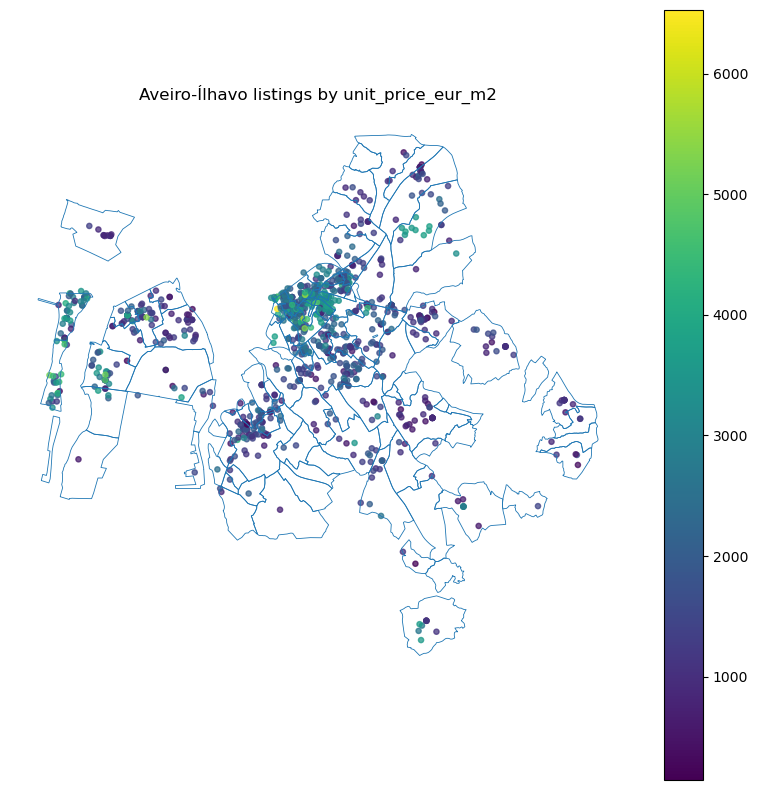

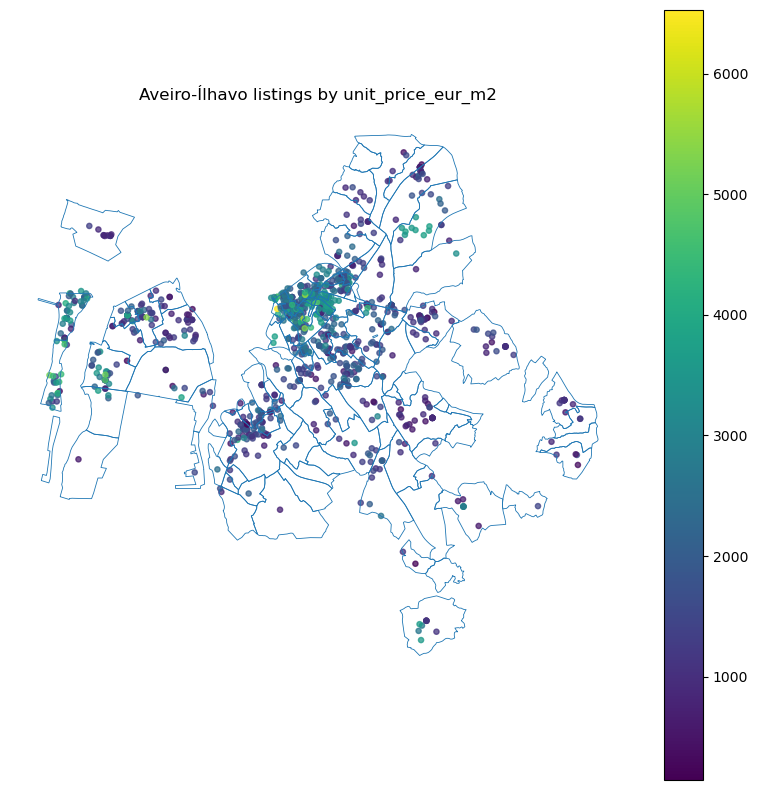

In [76]:
orientation_fig, orientation_ax = lab4.plot_aveiro_orientation(
    model_table=aveiro_model_table,
    zones=layers["zones"],
    outcome=AVEIRO_MODEL_SPEC["outcome"],
    metric_crs=METRIC_CRS,
)
orientation_fig


In [77]:
# ── ART-01: Slide artifact — Orientation map (slide-optimised) ──
import os
import matplotlib.pyplot as plt

os.makedirs("outputs/topic4", exist_ok=True)

if "orientation_fig" in dir():
    fig_orientation, _ = lab4.plot_aveiro_orientation(
        model_table=aveiro_model_table,
        zones=layers["zones"],
        outcome=AVEIRO_MODEL_SPEC["outcome"],
        metric_crs=METRIC_CRS,
    )
    fig_orientation.set_size_inches(12, 10)
    for _ax in fig_orientation.axes:
        try:
            _ax.title.set_fontsize(14)
        except Exception:
            pass
        _ax.xaxis.label.set_fontsize(11)
        _ax.yaxis.label.set_fontsize(11)
        _ax.tick_params(labelsize=10)
        for _col in _ax.collections:
            try:
                _col.set_sizes([64])
            except Exception:
                pass
    plt.tight_layout()
    fig_orientation.savefig(
        "outputs/topic4/slide_art01_orientation_map.png",
        dpi=150, bbox_inches="tight",
    )
    plt.close(fig_orientation)
    print("ART-01 saved: outputs/topic4/slide_art01_orientation_map.png")
    _fsize = os.path.getsize("outputs/topic4/slide_art01_orientation_map.png")
    print(f"File size: {_fsize / 1024:.1f} KB (should be > 50 KB)")
    assert _fsize > 20_000, f"ART-01 file too small ({_fsize} bytes)"
    print("Verification: ART-01 file size OK.")
else:
    print("WARNING: orientation_fig not available. Skipping ART-01.")

ART-01 saved: outputs/topic4/slide_art01_orientation_map.png
File size: 554.2 KB (should be > 50 KB)
Verification: ART-01 file size OK.


##### Interpreting the Orientation Map Output

**What to read:** Inspect point density across the study area, visible concentrations of high and low unit-price listings, zones with sparse or no coverage, and geographic patterns that might be explained by proximity to the Ria de Aveiro, road infrastructure, or administrative boundaries.

**What to look for:**
- **High-price concentrations** near the city centre, waterfront, or coastal areas are consistent with the amenity-based price gradient expected in a hedonic framework.
- **Low-price concentrations** in peripheral or inland zones may reflect older housing stock, lower accessibility, or smaller dwelling sizes.
- **Empty zones** (zones with polygon geometries but no listing points inside) are a data availability gap, not an error. They remain as spatial neighbours in the weights matrix but contribute no regression observations.
- **Point clusters at a single location** (duplicate coordinates) should be visually distinguishable as stacked symbols; a disproportionate cluster at one coordinate warrants investigation of the geocoding flags from Section 8.

**Caveat:** the map is a snapshot of the listing database and does not represent the full housing stock or transaction volume. Self-selection in listing behaviour — which properties get listed where and when — can create apparent spatial patterns that do not reflect underlying market conditions.

### Spatial Heterogeneity and Spatial Feature Engineering

Spatial feature engineering translates geographic position and context into numerical inputs for prediction models. The features constructed here are **transparent**: each can be explained in plain language, traced back to a documented data source, and audited for correctness. Transparency is a methodological requirement: opaque geographic features that improve in-sample prediction but cannot be explained or validated are a reproducibility and interpretability failure.

The features fall into four categories:

**Location features:** projected coordinates (`x_pttm06_m`, `y_pttm06_m`) and centred coordinates (`x_centered_km`, `y_centered_km`) capture the raw spatial position of each listing. In a linear model, coordinates enter as a spatial trend surface approximation. In tree-based models, they allow the algorithm to partition the study area by location.

**Distance features:** Euclidean distances from each listing to package-defined reference centres (Aveiro city centre, Ílhavo city centre) capture accessibility gradients. Distance to an amenity or employment centre is one of the most theoretically grounded spatial features in housing economics: closer proximity to services and opportunities commands a price premium. **Monocentricity caution:** using a single reference centre (Aveiro city centre) implicitly assumes a monocentric urban structure in which all accessibility gradients radiate from one point. The Aveiro–Ílhavo area also has the Ria de Aveiro waterfront as a major amenity axis, creating potentially polycentric price gradients. A model with only distance-to-Aveiro may misrepresent price gradients near the Ria or along secondary employment corridors. The package adds a second distance feature (Ílhavo city centre) as a partial correction, but a fully polycentric specification would include distance to the nearest waterfront point and possibly distances to major commercial or employment nodes.

**Context features:** zone area (`zone_area_km2`), listing count (`zone_listing_count`), and listing density (`zone_listing_density_km2`) characterise the zone in which a listing is located. Zone indicators (`zone_id_cat`, `municipality_name_cat`) encode all time-invariant zone-level unobservables as fixed effects.

**Leakage-sensitive features:** zone-level means of the outcome variable (`zone_mean_unit_price_eur_m2`) are marked `leakage_sensitive` and **excluded from default prediction models** by the package. This exclusion is critical:

> **Target leakage in cross-validation.** If `zone_mean_unit_price_eur_m2` is computed over the full dataset (including validation listings) before the train-test split, the model has implicit access to validation-outcome information during training. This inflates cross-validated performance and produces over-optimistic generalisability estimates. A correct workflow recomputes zone means using only the training fold at each CV iteration. The package flags and excludes these features rather than implementing the fold-safe computation.

In [78]:
SPATIAL_FEATURE_SPEC = {
    "include_projected_coordinates": True,
    "include_zone_indicators": True,
    "include_municipality_indicator": True,
    "include_distance_to_reference_centres": True,
    "reference_centres": {
        "aveiro_centre": "package_defined",
        "ilhavo_centre": "package_defined",
    },
    "include_zone_neighbourhood_summaries": True,
    "neighbourhood_summary_outcomes": ["unit_price_eur_m2"],
    "leakage_control": "exclude leakage-sensitive summaries from default prediction models",
}

aveiro_features = lab4.build_aveiro_spatial_features(
    model_table=aveiro_model_table,
    zones=layers["zones"],
    parishes=layers.get("parishes"),
    feature_spec=SPATIAL_FEATURE_SPEC,
    random_state=RANDOM_STATE,
    metric_crs=METRIC_CRS,
)

feature_summary = lab4.summarise_spatial_features(aveiro_features, return_object=True)
feature_summary


,column,feature_type,dtype,missing,unique,used_by_default
0,condition_std,hedonic_categorical,object,0,2,True
1,listing_year,hedonic_categorical,string,0,5,True
2,preservation_class_std,hedonic_categorical,object,0,4,True
3,property_type_std,hedonic_categorical,object,0,2,True
4,typology_bucket_std,hedonic_categorical,object,0,8,True
5,area_living_m2,hedonic_numeric,float64,0,321,True
6,zone_mean_unit_price_eur_m2__leakage_sensitive,leakage_sensitive_outcome_summary,float64,0,87,False
7,municipality_name_cat,spatial_categorical,string,0,2,True
8,zone_id_cat,spatial_categorical,string,0,87,True
9,distance_to_aveiro_centre_km,spatial_numeric,float64,0,857,True


#### Interpreting the Feature Summary Output

**What to read:** Check `feature_type`, missing-value counts, unique-value counts, and the `used_by_default` flag for each feature.

**What this run found:** 18 features were generated across four types: **5 hedonic categorical** (condition, year, preservation class, property type, typology), **1 hedonic numeric** (`area_living_m2`), **1 leakage-sensitive outcome summary** (`zone_mean_unit_price_eur_m2__leakage_sensitive`), **2 spatial categorical** (municipality and zone indicators), and **9 spatial numeric** (coordinates, centred coordinates, distances, zone area and density). No features had missing values.

**Leakage exclusion confirmed:** `zone_mean_unit_price_eur_m2__leakage_sensitive` has `used_by_default = False`. It does not enter the cross-validation models in Section 18.

**Unique-value counts as a quality check:** `distance_to_aveiro_centre_km` has 857 unique values out of 1 095 listings. The remaining 238 listings share distances with other listings, consistent with the 9-unit maximum duplicate-coordinate count from the data pre processing — listings sharing an exact coordinate will receive identical distance features. This reduces their discriminatory power in local models but does not warrant exclusion.

**Zone indicator (`zone_id_cat`)** is the most spatially informative categorical feature: it effectively encodes the zone-level price level as a fixed effect. 

Later, this will be a key feature for zone-block Cross-Validation. Thus, this ensures the model will be evaluated on its generalisation power on held-out zones — the model has never seen the held-out zone identifier.


### Spatial Weights Matrix (W)

Spatial weights formalise the concept of "neighbourhood." The choice of W is a modelling decision, not a mechanical step: different W matrices make structurally different claims about how spatial structure operates.

**For point listings,** k-nearest-neighbour (kNN) weights are practical because every point receives exactly $k$ neighbours regardless of how unevenly the point cloud is distributed. Queen contiguity cannot be defined for points. The cost of kNN is that the neighbourhood size is fixed at $k$ even in dense areas where closer natural neighbours exist; the implied neighbourhood radius varies inversely with local density.

**For polygon layers,** Queen contiguity is natural: two polygons are neighbours if they share at least one boundary point (edge or corner). Contiguity respects the geometry of the polygons — zones separated by the Ria de Aveiro are not contiguous even if they are spatially close, correctly encoding that the estuary is a physical barrier to neighbourhood price diffusion.

**Weights diagnostics are mandatory before any Moran test or spatial regression.** Key metrics:

- **Islands:** polygons with zero neighbours under the chosen W. Islands are excluded from Moran's I (their spatial lag is undefined) and from spatial regression, effectively reducing the estimation sample. A high island count signals topology gaps in the polygon layer.
- **Number of components:** the number of disconnected subgraphs in the weights graph. Multiple components mean spatial dynamics cannot propagate between disconnected parts of the study area.
- **Cardinality distribution:** the distribution of neighbour counts. Highly uneven cardinality can destabilise Moran statistics and make spatial model coefficients harder to interpret.

In [79]:
weights_suite = lab4.build_weights_suite(
    listings=aveiro_features,
    zones=layers["zones"],
    municipalities=layers["municipalities"],
    specs=[
        {"name": "listing_knn_8", "type": "knn", "unit": "listing", "k": 8},
        {"name": "zone_queen", "type": "queen", "unit": "zone"},
        {"name": "municipality_queen", "type": "queen", "unit": "municipality"},
    ],
    metric_crs=METRIC_CRS,
)

weights_diagnostics = pd.concat(
    [lab4.weights_summary(w).assign(weights=name) for name, w in weights_suite.items()],
    ignore_index=True,
)
weights_diagnostics


c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
 There are 5 islands with ids: 24, 31, 80, 83, 96.
  W.__init__(self, neighbors, ids=ids, **kw)


,metric,value,weights
0,name,listing_knn_8,listing_knn_8
1,n,1095,listing_knn_8
2,mean_neighbors,7.782648,listing_knn_8
3,min_neighbors,7,listing_knn_8
4,max_neighbors,8,listing_knn_8
5,islands,0,listing_knn_8
6,pct_islands,0.0,listing_knn_8
7,name,zone_queen,zone_queen
8,n,104,zone_queen
9,mean_neighbors,3.980769,zone_queen


#### Interpreting the Weights Diagnostics Output

**What to read:** Check the name, unit, mean/min/max neighbours, island count, and percentage of islands for each weights object.

**What this run found:**

| Weights | N | Mean neighbours | Min | Max | Islands | % islands |
|---|---|---|---|---|---|---|
| `listing_knn_8` | 1 095 | 7.78 | 7 | 8 | **0** | 0.0 % |
| `zone_queen` | 104 | 3.98 | 0 | 15 | **5** | 4.8 % |
| `municipality_queen` | 278 | 5.32 | 1 | 10 | **0** | 0.0 % |

**Listing weights:** the kNN-8 matrix has no islands by construction and mean degree close to 8. This W is safe for listing-level Moran tests and residual diagnostics.

**Zone weights:** 5 of 104 zones (4.8%) are islands under Queen contiguity. These correspond to isolated polygon geometries that do not share a boundary with any other zone — likely small zones surrounded by topology gaps. Islands are excluded from Queen-based Moran statistics; the effective zone sample for Moran's I is 99, not 104. This is why the kNN listing weights are preferred for listing-level diagnostics: they resolve the island problem by always assigning neighbours regardless of polygon connectivity.

**Municipality weights:** the Queen matrix for 278 mainland municipalities has no islands and a reasonable cardinality range (1–10), consistent with a well-formed administrative boundary layer. It will be used for Track B diagnostics in Section 21.

### Exploratory Spatial Diagnostics on the Outcome

Before fitting any prediction or local model, ask whether the outcome itself is spatially structured. **Moran's I** is the most widely used global spatial autocorrelation statistic. For a variable $y$ and row-standardised weights matrix $W$, it is:

$$I = \frac{n}{S_0} \cdot \frac{\sum_i \sum_j w_{ij}(y_i - \bar{y})(y_j - \bar{y})}{\sum_i (y_i - \bar{y})^2}$$

where $n$ is the number of observations and $S_0 = \sum_i \sum_j w_{ij}$ is the sum of all weights. For row-standardised $W$, $S_0 = n$ and the formula reduces to the spatial autocovariance relative to total variance. Moran's I ranges roughly from −1 (perfect negative autocorrelation, a checkerboard pattern) through 0 (spatial randomness) to +1 (perfect positive autocorrelation, all high values clustered with high values). The **expected value under the null hypothesis of spatial randomness** is not exactly zero but:

$$E(I) = -\frac{1}{n-1}$$

which approaches zero for large $n$ but is noticeably negative in small samples — for example, $E(I) = -0.010$ for $n = 104$ zones, and $E(I) = -0.001$ for $n = 1\,095$ listings. When comparing the observed $I$ against the null, the reference is $E(I)$, not zero. Permutation-based inference handles this automatically by recentring the simulated distribution around the observed data, so the permutation p-value correctly reflects the distance of $I$ from $E(I)$.

Three important interpretive constraints apply:

1. **W-dependence:** Moran's I depends on the weights matrix. Two different W specifications applied to the same outcome will generally produce different I values. A significant positive I under one W and a non-significant I under another is not contradictory — it reflects the sensitivity of any autocorrelation measure to the assumed neighbourhood structure.

2. **Descriptive, not causal:** a positive and significant Moran's I means nearby listings tend to have similar prices under the chosen W. It is consistent with SAR contagion, SEM clustered unobservables, SLX spillovers, and spatial heterogeneity alike. The diagnostic does not distinguish these mechanisms.

3. **Permutation p-values:** the analytical p-value assumes normality of the test statistic. For small or skewed samples the permutation p-value — obtained by randomly reassigning outcome values to locations — is more reliable. The classroom default of 199 permutations gives a minimum detectable p-value of 0.005; increase to 999 for final reporting.

In [80]:
exploratory_diagnostics = lab4.run_exploratory_diagnostics(
    features=aveiro_features,
    zones=layers["zones"],
    outcome=AVEIRO_MODEL_SPEC["outcome"],
    metric_crs=METRIC_CRS,
)
exploratory_diagnostics


c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 3 islands with ids: 31, 49, 83.
  W.__init__(self, neighbors, ids=ids, **kw)


{'outcome': 'unit_price_eur_m2',
 'listing_moran': {'moran_i': 0.3815784740486782,
  'p_sim': 0.005,
  'n': 1095,
  'permutations': 199,
  'note': 'fallback Moran implementation'},
 'zone_moran': {'moran_i': 0.536709025396743,
  'p_sim': 0.005,
  'n': 87,
  'permutations': 199,
  'note': 'fallback Moran implementation'}}

#### Interpreting the Moran Diagnostics Output

**What to read:** Read the Moran's I value, the permutation p-value, the number of observations, the number of permutations, and the unit of analysis (listing or zone).

**What this run found:**

| Unit | Weights | Moran's I | p-value (sim) |
|---|---|---|---|
| Listing | kNN-8 (fallback) | **0.382** | 0.005 |
| Zone | Queen contiguity (fallback) | **0.537** | 0.005 |

Both statistics are positive and highly significant (permutation p = 0.005, the minimum detectable at 199 permutations). The **zone-level I (0.54) is substantially higher than the listing-level I (0.38)**, which is expected: aggregating listings to zones smooths idiosyncratic listing noise and amplifies the neighbourhood-level price signal. This is a classic MAUP effect — the apparent degree of spatial clustering increases with the level of aggregation.

**Interpreting the magnitude:** values above 0.3 at the listing level indicate strong neighbourhood price clustering. Nearby listings are markedly more similar in unit price than would be expected under spatial randomness. This motivates both the local modelling approach (GWR) and the spatial validation strategy: if prices are spatially correlated, random CV splits will mix nearby listings across training and validation sets, causing the model to perform unrealistically well on validation data.

**Caution:** the zone-level I depends on a Queen contiguity matrix with 5 islands (zones with no shared boundary). Island zones contribute zero to the spatial lag computation, which can deflate the observed I. The weights diagnostics in Section 13 examine this issue in detail.

### Local Spatial Autocorrelation: LISA Statistics

Global Moran's I answers: *is there, on average, spatial clustering in this variable?* It does not identify *where* the clustering occurs. **Local Indicators of Spatial Association (LISA)** — introduced by Anselin (1995) — decompose the global statistic into observation-level contributions, identifying specific **spatial clusters** and **spatial outliers**.

The **Local Moran's I** for observation $i$ is:

$$I_i = z_i \sum_j w_{ij} z_j$$

where $z_i = (y_i - \bar{y}) / \hat{\sigma}_y$ are standardised deviations and $w_{ij}$ are the row-standardised weights. A **positive** $I_i$ means observation $i$ and its neighbours share similarly signed deviations from the mean (both high or both low). A **negative** $I_i$ means $i$ is a spatial outlier — its value diverges markedly from its neighbourhood.

LISA statistics classify each observation into one of four quadrants in the Moran scatterplot:

| Quadrant | $z_i$ sign | $\bar{z}_{\mathcal{N}(i)}$ sign | Interpretation |
|---|---|---|---|
| **HH** (High-High) | + | + | High-price listing in a high-price neighbourhood — core of a price hotspot |
| **LL** (Low-Low) | − | − | Low-price listing in a low-price neighbourhood — price cold spot |
| **HL** (High-Low) | + | − | High-price listing in a low-price neighbourhood — spatial outlier |
| **LH** (Low-High) | − | + | Low-price listing in a high-price neighbourhood — spatial outlier |

**Three important cautions:**

1. **Multiple testing.** $N$ simultaneous tests are conducted — one per observation. With a nominal 5% threshold and $N = 1\,095$ listings, approximately 55 observations would appear significant by chance alone. The permutation p-values are not automatically multiple-testing corrected. Treat the *spatial pattern* of LISA clusters (contiguous HH/LL zones, coherent periphery) as more informative than any individual point classification.
2. **Descriptive, not causal.** HH clusters are consistent with SAR price contagion, SEM clustered unobservables, and spatial market segmentation alike. LISA does not identify the mechanism.
3. **W-sensitivity.** LISA results depend on the chosen weights matrix. Results under kNN-8 and Queen contiguity may differ, particularly for peripheral listings near the study-area boundary.

> **Connection to GWR.** LISA identifies *which observations* are at the core or edge of spatial clusters. GWR then asks *why*: do the covariates that explain price operate differently in HH cluster cores versus the LL periphery? Together, LISA maps and GWR coefficient surfaces provide complementary spatial diagnostics — the former describes the outcome surface, the latter describes how covariate effects vary across it.


In [81]:
# ── Local Moran's I (LISA) on unit_price_eur_m2 ──────────────────────────────────────────────
# Uses PySAL esda for the listing-level LISA computation.
# W: kNN-8 on listing coordinates (same matrix used in residual diagnostics).

try:
    from esda.moran import Moran_Local
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    _w_lisa = weights_suite.get("listing_knn_8")
    if _w_lisa is None:
        raise RuntimeError("kNN-8 weights not found in weights_suite — run Section 113 first.")

    _y_lisa = aveiro_features["unit_price_eur_m2"].to_numpy(dtype=float)
    _moran_local = Moran_Local(
        _y_lisa, _w_lisa, transformation="r",
        permutations=499, seed=RANDOM_STATE,
    )

    # Significance mask at p < 0.05 (2-sided)
    _sig = _moran_local.p_sim < 0.05
    # PySAL quadrant convention: 1=HH, 2=LH, 3=LL, 4=HL
    _q_labels = {1: "HH (hotspot)", 2: "LH (outlier)", 3: "LL (coldspot)", 4: "HL (outlier)"}
    _q_colors = {1: "#d7191c", 2: "#fdae61", 3: "#2c7bb6", 4: "#abd9e9", 0: "#e0e0e0"}

    _gdf_lisa = aveiro_features.copy()
    _gdf_lisa["lisa_q"] = np.where(_sig, _moran_local.q, 0)
    _gdf_lisa["lisa_color"] = _gdf_lisa["lisa_q"].map(_q_colors)

    fig_lisa, ax_lisa = plt.subplots(1, 1, figsize=(9, 8))
    _gdf_lisa.plot(color=_gdf_lisa["lisa_color"], ax=ax_lisa, markersize=6, alpha=0.85)
    layers["zones"].boundary.plot(ax=ax_lisa, color="grey", linewidth=0.4, alpha=0.5)

    _patches = [mpatches.Patch(color=_q_colors[k], label=v) for k, v in _q_labels.items()]
    _patches.append(mpatches.Patch(color=_q_colors[0], label="Not significant"))
    ax_lisa.legend(handles=_patches, loc="lower right", fontsize=9, title="LISA cluster type")
    ax_lisa.set_title(
        f"Local Moran's I \u2014 unit_price_eur_m2\n"
        f"Significant listings (p < 0.05, 499 permutations): "
        f"{_sig.sum()} of {len(_sig)} ({100 * _sig.mean():.0f}%)",
        fontsize=11,
    )
    ax_lisa.set_axis_off()
    plt.tight_layout()
    plt.show()

    # Summary table
    _lisa_summary = (
        _gdf_lisa.groupby("lisa_q").size().rename("count").reset_index()
    )
    _lisa_summary["quadrant"] = _lisa_summary["lisa_q"].map(
        {**{k: v for k, v in _q_labels.items()}, 0: "Not significant"}
    )
    _lisa_summary["share_pct"] = (
        _lisa_summary["count"] / len(_gdf_lisa) * 100
    ).round(1)
    print(_lisa_summary[["quadrant", "count", "share_pct"]].to_string(index=False))

except ImportError:
    print("esda not installed — install with: pip install esda")
    print("LISA analysis skipped.")
except Exception as _exc:
    print(f"LISA analysis skipped: {_exc}")


LISA analysis skipped: 'str' object is not callable


#### Interpreting the LISA Map

**What to read.** Each point is coloured by its LISA cluster type (significant at p < 0.05 under 499 permutations). Red (HH) and blue (LL) points indicate statistically significant spatial clusters — areas where both the listing and its kNN-8 neighbours share similarly high or low unit prices. Orange (HL) and light-blue (LH) points are spatial outliers. Grey points have non-significant local statistics and are not meaningfully interpreted individually.

**What to look for:**

- **HH clusters** in the city centre, waterfront, or coastal zones confirm that premium submarkets are spatially concentrated. These locations are candidates for the high-bandwidth regime in GWR where the floor-area elasticity and the apartment premium may also be elevated.
- **LL clusters** in peripheral or inland zones define the cold-spot ring. Stable LL clusters with few spatial outliers suggest those markets are relatively homogeneous internally.
- **HL and LH outliers** deserve individual inspection: an HL listing (high price in a low-price area) may reflect a luxury new-build in a transitional zone, a geocoding error placing the listing in the wrong neighbourhood, or a genuine niche market. Such observations can exert high leverage on GWR local estimates and should be cross-checked against the coordinate QA flags from Section 8.

**Comparing global and local statistics.** The global Moran's I (≈ 0.38 for listings) is a weighted average of the individual LISA contributions. LISA reveals that this global clustering is not spatially uniform: some zones are strongly clustered (HH/LL cores), while others are transitional or outlier-dominated. The *spatial pattern* of clusters — not the count of significant points — is the primary diagnostic.

**Caution on multiple testing.** With 1 095 listings and a 5% threshold, approximately 55 listings would appear significant under pure spatial randomness. Do not interpret every isolated significant point as a genuine cluster; interpret the *contiguous spatial pattern* of HH/LL zones instead.


### Global Reference Model

A global reference model is a mandatory benchmark before any local or machine-learning alternative. It establishes two things:

> **Theoretical grounding: the hedonic pricing model.** The framework rests on Rosen's (1974) hedonic price theory, which treats each dwelling as a bundle of attributes whose implicit prices are revealed by the market. Under competitive equilibrium, the coefficient $\hat{\beta}_k$ on attribute $x_k$ (e.g., living area) estimates the marginal implicit price buyers pay for an additional unit of that attribute. This theoretical grounding justifies using OLS or regularised linear regression on unit price: the regression surface traces the hedonic price function, and deviations (residuals) are attributable to unobserved attributes, measurement error, or market imperfections. Spatial heterogeneity in the hedonic function — the primary motivation for GWR — arises when buyers in different submarkets apply structurally different implicit prices to the same attribute.

1. **What structural characteristics explain.** A hedonic model decomposes unit price into the prices of individual structural attributes:

   $$p_i = \alpha + \sum_k \beta_k x_{ki} + \varepsilon_i$$

   where $x_{ki}$ are structural attributes (area, typology, condition, preservation class, year). This specification answers: *how much does structural composition alone explain of the variance in unit price?*

2. **What location adds.** Augmenting the hedonic model with spatial features (coordinates, distances, zone and municipality indicators) answers: *how much additional predictive power comes from knowing where a listing is located, even without identifying the causal mechanism?*

The comparison between the two feature sets is informative but requires care:

> **In-sample vs. out-of-sample performance.** The R², RMSE, and MAE reported here are **in-sample** (computed on the same data used for fitting). They measure model fit, not generalisability. A spatial model that learns zone fixed effects will always achieve better in-sample fit than a pure hedonic model, because zone indicators absorb all between-zone variation — including variance driven by random noise, sample composition, and listing-period effects. Section 18 provides the proper out-of-sample comparison via cross-validation.

In [82]:
GLOBAL_REFERENCE_SPEC = {
    "model_family": "regularized_linear_or_ols_baseline",
    "outcome": AVEIRO_MODEL_SPEC["outcome"],
    "feature_sets": ["hedonic_controls_only", "hedonic_plus_spatial_features"],
    "standardize_numeric": True,
    "handle_categorical": "one_hot",
}

global_reference = lab4.fit_global_reference_model(
    features=aveiro_features,
    model_spec=GLOBAL_REFERENCE_SPEC,
    random_state=RANDOM_STATE,
)

global_reference["metrics"]


,feature_set,model_family,n,numeric_features,categorical_features,rmse,mae,r2
0,hedonic_controls_only,regularized_linear_or_ols_baseline,1095,[area_living_m2],"[property_type_std, typology_bucket_std, condi...",705.616977,539.737763,0.535280
1,hedonic_plus_spatial_features,regularized_linear_or_ols_baseline,1095,"[area_living_m2, x_pttm06_m, y_pttm06_m, x_cen...","[property_type_std, typology_bucket_std, condi...",599.498682,445.289161,0.664548


#### Interpreting the Global Reference Model Output

**What to read:** Compare RMSE, MAE, and R² across the two feature sets. Note that these are in-sample metrics. Check the feature lists to confirm what each specification includes.

**What this run found:**

| Feature set | RMSE (€/m²) | MAE (€/m²) | R² |
|---|---|---|---|
| Hedonic controls only | 705.6 | 539.7 | 0.535 |
| Hedonic + spatial features | 599.5 | 445.3 | 0.665 |

Adding spatial features reduces in-sample RMSE from **€706/m²** to **€600/m²** (a 15% improvement) and lifts R² from 0.535 to 0.665. This gap quantifies the **in-sample explanatory gain from knowing where a listing is located** given its structural characteristics: approximately 13 percentage points of variance (0.665 − 0.535) are associated with location after conditioning on area, typology, condition, preservation class, and year.

**Caution — in-sample R² overstates generalisability.** The spatial feature set includes zone fixed effects (`zone_id_cat`), which capture all time-invariant unobserved zone characteristics. In-sample, zone fixed effects nearly eliminate between-zone residual variance; out-of-sample in spatial CV, they reduce to pure memorisation of zone-level price levels and do not generalise to unseen locations. Section 18 measures the true generalisation cost.

**Causal interpretation is not supported.** The association between centrality and price conflates genuine accessibility premiums with neighbourhood quality, property composition, and listing-time effects correlated with centrality. This is consistent with the broader caution from Lab 3: observational regression coefficients are associations, not causal effects.

### Residual Diagnostics for the Global Reference Model

A global regression model can achieve a high in-sample R² and still leave **spatially structured residuals** — systematic prediction errors that cluster in space. Residual spatial autocorrelation indicates that the model has failed to account for some form of geographic structure. The diagnosis does not reveal the cause, which may be:

- **Omitted spatial variables:** a relevant covariate (proximity to the Ria de Aveiro, coastal view, planning zone) is correlated with both price and location but absent from the model.
- **Spatial heterogeneity:** the functional relationship between price and covariates varies across space, and a global model cannot capture this variation. This is the primary GWR motivation.
- **Spatial dependence:** prices in nearby zones influence each other (the SAR/SEM mechanism from Lab 3), and a regression without a spatial lag or error structure cannot remove this autocorrelation.
- **Geocoding artefacts:** some listings have inaccurate coordinates, placing them in the wrong zone and creating systematic spatial misalignment in the residuals.

**Moran's I on regression residuals** uses the same formula as the outcome Moran but applied to the vector of residuals $\hat{\varepsilon} = y - X\hat{\boldsymbol{\beta}}$. A positive and significant residual Moran's I means the model has not fully absorbed the spatial structure in the data. It is a signal for further investigation — not an automatic prescription for a specific modelling response.

In [83]:
global_diagnostics = lab4.diagnose_global_reference_model(
    global_reference,
    features=aveiro_features,
    zones=layers["zones"],
    metric_crs=METRIC_CRS,
)
global_diagnostics


,feature_set,diagnostic,weights,status,moran_i,p_sim,n,permutations,note,rmse,mae,r2
0,hedonic_controls_only,moran_knn_8,listing_knn_8,computed,0.243313,0.005,1095,199.0,fallback Moran implementation,NaN,NaN,NaN
1,hedonic_plus_spatial_features,moran_knn_8,listing_knn_8,computed,0.020380,0.095,1095,199.0,fallback Moran implementation,NaN,NaN,NaN
2,hedonic_controls_only,in_sample_fit,None,computed,NaN,NaN,1095,NaN,NaN,705.616977,539.737763,0.535280
3,hedonic_plus_spatial_features,in_sample_fit,None,computed,NaN,NaN,1095,NaN,NaN,599.498682,445.289161,0.664548


#### Interpreting the Residual Diagnostics Output

**What to read:** Compare the residual Moran's I and p-value between the hedonic-only and hedonic-plus-spatial feature sets. A reduction in Moran's I after adding spatial features indicates that those features absorbed some of the spatial structure in the residuals.

**What this run found:**

| Feature set | Residual Moran's I | p-value (sim) | Spatially structured? |
|---|---|---|---|
| Hedonic controls only | **0.243** | 0.005 | Yes (significant) |
| Hedonic + spatial features | **0.020** | 0.095 | No (p > 0.05, marginal) |

The hedonic-only model leaves substantial residual spatial autocorrelation (I = 0.243, p = 0.005): nearby listings share systematic prediction errors after conditioning on structural attributes alone. Adding spatial features reduces the residual Moran's I to **0.020**, which is no longer statistically significant at the 5% level (p = 0.095). The spatial features collectively absorb the spatial structure of the residuals.

**Interpreting the reduction carefully:** zone fixed effects (`zone_id_cat`) can absorb spatial autocorrelation by construction — they partition variance into within-zone and between-zone components, and between-zone autocorrelation, once absorbed by the fixed effects, cannot appear in residuals. This is powerful for prediction but uninformative about the causal spatial process. The residual Moran reduction confirms that the spatial features captured the geographic structure at the scale of these data; it does not confirm that the causal mechanism has been identified.

### Global model and Spatial Heterogeneity fix - Zone Fixed-Effect model

The global Ridge model (`hedonic_plus_spatial_features`) encodes zone membership through one-hot dummy variables. Ridge regression penalises all coefficients towards zero with a regularisation strength $\lambda$ chosen by cross-validation. The zone dummy coefficient for zone $z$ can be understood as a shrunk version of the zone-specific price premium conditional on structural attributes. Ridge penalises coefficient *magnitude*, not estimation uncertainty directly: zones with few listings tend to produce poorly constrained, potentially large-magnitude OLS estimates; because Ridge shrinks large magnitudes more aggressively, these small-sample zones land closer to zero than their raw OLS counterpart would. The practical effect is to prevent over-interpretation of noisy small-zone estimates, but the mechanism is shrinkage of magnitude, not a direct function of within-zone variance.

**Why map the zone coefficients?** They are the global model's representation of spatial price heterogeneity: all location effects not explained by structural attributes (area, type, typology, condition, preservation class, year) are absorbed into zone fixed effects. A coherent spatial gradient in these coefficients — high premiums in waterfront and central zones, negative values in peripheral zones — suggests that zone boundaries roughly align with market segmentation. GWR (Section 16) then tests whether this heterogeneity is truly discrete (zone-bounded) or whether covariate effects vary *continuously* across space.

**Colormap.** The map uses a diverging palette centred at zero when coefficients span both positive and negative values (blue = premium, red = discount). Grey zones are those absorbed into the Ridge intercept or not matched in the feature table (reference-category zones).

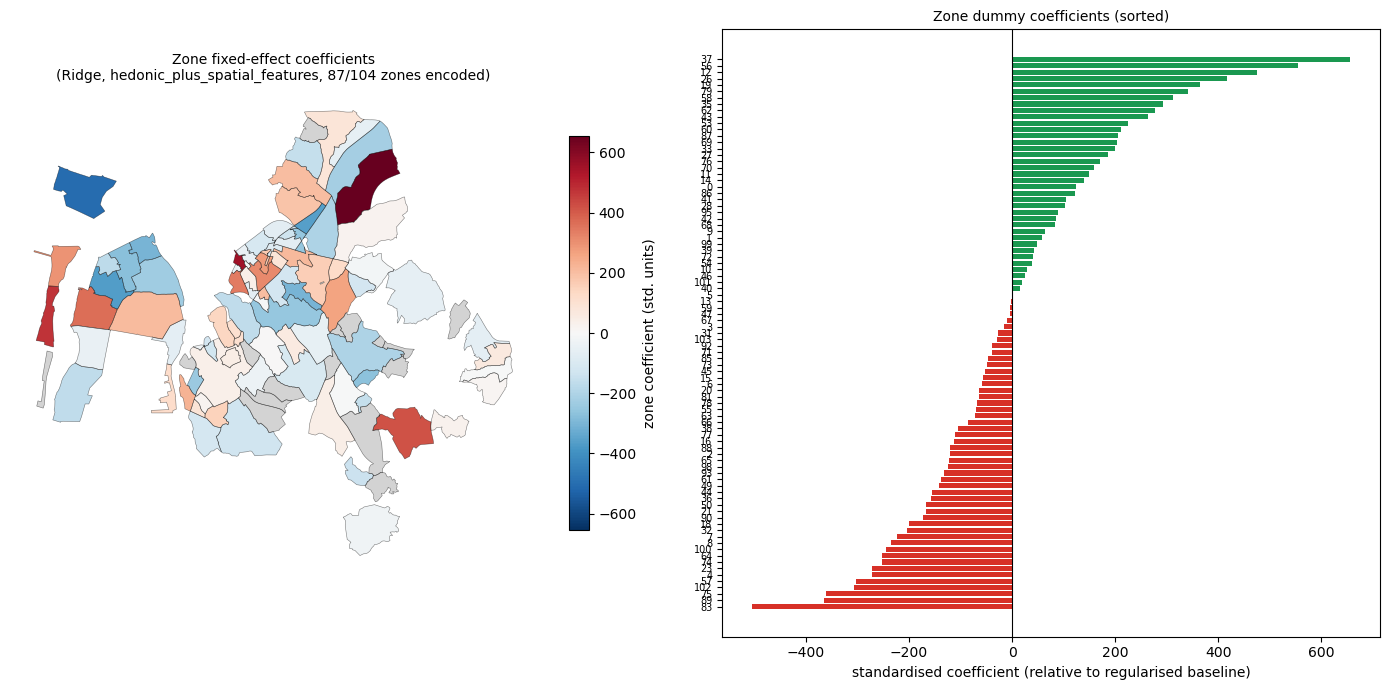

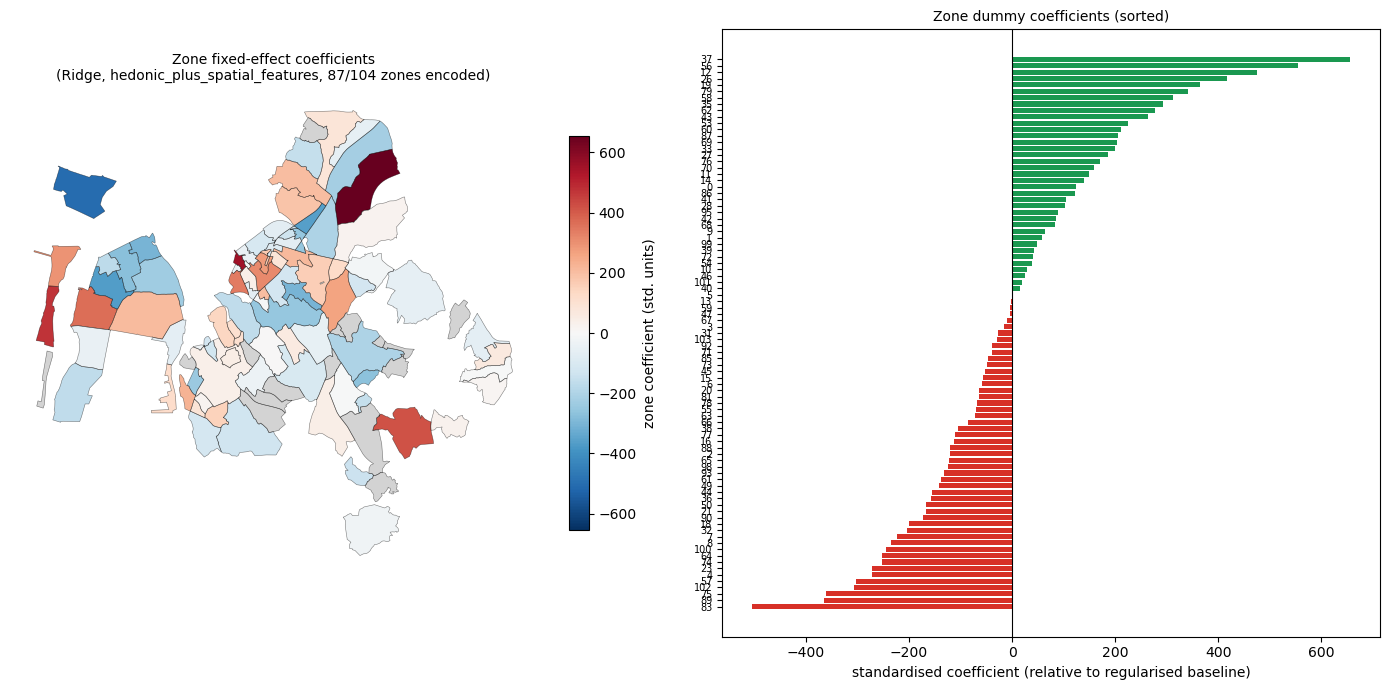

In [84]:
zone_dummy_fig, zone_dummy_axes = lab4.plot_zone_dummy_coefficients(
    global_reference=global_reference,
    zones=layers["zones"],
    feature_set="hedonic_plus_spatial_features",
    metric_crs=METRIC_CRS,
)
zone_dummy_fig

In [85]:
# ── ART-09: Slide artifact — Zone fixed-effect coefficient map (slide-optimised) ──
import os
import matplotlib.pyplot as plt

os.makedirs("outputs/topic4", exist_ok=True)

if "zone_dummy_fig" in dir():
    fig_zone_dummy, _ = lab4.plot_zone_dummy_coefficients(
        global_reference=global_reference,
        zones=layers["zones"],
        feature_set="hedonic_plus_spatial_features",
        metric_crs=METRIC_CRS,
    )
    fig_zone_dummy.set_size_inches(14, 6)
    for _ax in fig_zone_dummy.axes:
        try:
            _ax.title.set_fontsize(13)
        except Exception:
            pass
        _ax.xaxis.label.set_fontsize(11)
        _ax.yaxis.label.set_fontsize(11)
    plt.tight_layout()
    fig_zone_dummy.savefig(
        "outputs/topic4/slide_art09_zone_dummy_map.png",
        dpi=150, bbox_inches="tight",
    )
    plt.close(fig_zone_dummy)
    print("ART-09 saved: outputs/topic4/slide_art09_zone_dummy_map.png")
    _fsize = os.path.getsize("outputs/topic4/slide_art09_zone_dummy_map.png")
    print(f"File size: {_fsize / 1024:.1f} KB (should be > 50 KB)")
    assert _fsize > 20_000, f"ART-09 file too small ({_fsize} bytes)"
    print("Verification: ART-09 file size OK.")
else:
    print("WARNING: zone_dummy_fig not available. Skipping ART-09.")

ART-09 saved: outputs/topic4/slide_art09_zone_dummy_map.png
File size: 238.6 KB (should be > 50 KB)
Verification: ART-09 file size OK.


#### Interpreting the Zone Dummy Coefficient Map

**What to read.** The left panel maps zone coefficients spatially; the right panel ranks all encoded zones from lowest to highest. Positive coefficients indicate zones with systematically higher unit prices than the regularised baseline, after conditioning on area, property type, typology, condition, preservation class, and listing year. Negative coefficients indicate a price discount.

**What to look for.**

- **Spatial gradient.** Inspect whether high-coefficient zones cluster geographically (e.g., Aveiro waterfront and historic centre) and low-coefficient zones are peripheral or inland. A coherent gradient supports the hypothesis that zone membership encodes locational amenity value (accessibility, coastal proximity, urban density). A random scatter with no geographic structure suggests that zones are administrative units misaligned with housing market segmentation.

- **Magnitude.** Ridge standardises numeric features before fitting but not the one-hot zone columns, so zone coefficients are on the original outcome scale (EUR/m\u00b2). A coefficient of +300 for a zone means listings there are priced approximately \u20ac300/m\u00b2 above the regularised reference, all else equal.

- **Shrinkage.** Zones with very few listings (fewer than 5-10) will show coefficients close to zero regardless of their true market premium — the Ridge penalty dominates the small within-zone signal. Cross-reference with the zone listing-count from Section 11 before interpreting small-zone values.

- **No explicit reference zone.** Ridge without `drop='first'` encodes all zones; the intercept and regularisation jointly establish a soft centering. Coefficients should be interpreted relative to the average regularised prediction, not relative to a specific dropped zone as in OLS with dummies.

### Local Models: Spatial Heterogeneity and Local Covariate Effects — GWR and MGWR

Spatial heterogeneity asks whether the *marginal effect* of a covariate changes across the study area — whether the floor-area price elasticity is higher in central Aveiro than in peripheral Ílhavo, or whether the distance-to-centre gradient is uniform. Geographically Weighted Regression (GWR) and its multi-scale extension (MGWR) are the standard diagnostics for this question.

Both models are fitted with the **PySAL `mgwr` package** (`pip install mgwr`), the canonical Python implementation of Fotheringham, Yang, and Kang (2017). PySAL now also provides [gwlearn](https://pysal.org/gwlearn/stable/), a higher-level scikit-learn-compatible wrapper around the same engine.

**GWR/MGWR as diagnostic, not prediction model.**  GWR answers: *does spatial structure in the Aveiro–Ílhavo market manifest as non-stationarity in covariate effects, or is it adequately captured by the zone fixed effects in the global model?*

#### Covariate selection FOR LOCAL EFFECTS

Three covariates test distinct spatial hypotheses while avoiding the local matrix singularity caused by multi-column dummy expansion (see **Technical Note** immediately below):

| Covariate | Role | Spatial hypothesis |
|---|---|---|
| `area_living_m2` | Primary structural attribute | Does the floor-area price elasticity vary by submarket? |
| `is_apartment` | Single binary property-type control | Does the Apartment/House price gap vary spatially? |
| `distance_to_aveiro_centre_km` | Continuous location gradient | Is the centre-distance penalty uniform or submarket-specific? |

**Computational cost.** GWR: 1-3 min. MGWR: 3-7 min on N ≈ 1 095 with 3 covariates. Set `RUN_MGWR = False` to skip the multi-scale extension.

#### Summary Theoretical Notes: GWR and MGWR — Estimation, Bandwidth Selection, and Constraints

#### 1. From global OLS to GWR

Standard hedonic regression assumes **global stationarity**: a single coefficient vector $\boldsymbol{\beta}$ applies at every location:

$$y_i = \boldsymbol{x}_i^\top \boldsymbol{\beta} + \varepsilon_i, \quad i = 1, \ldots, N$$

GWR (Fotheringham, Brunsdon, and Charlton, 1996, 2002) relaxes this by estimating a separate vector $\hat{\boldsymbol{\beta}}(u_i, v_i)$ at each observation location $(u_i, v_i)$ via a geographically weighted least-squares problem:

$$\hat{\boldsymbol{\beta}}(u_i, v_i) = \left(X^\top W_i X\right)^{-1} X^\top W_i y$$

where $W_i = \mathrm{diag}[w_{i1}, \ldots, w_{iN}]$ is a diagonal matrix of kernel weights. Observations close to $i$ receive high weight; those outside the bandwidth receive zero weight. This is a **locally weighted OLS** (equivalent to WLS) solved independently at every calibration point in the dataset — there are $N$ such problems, one per observation.

#### 2. The adaptive bisquare kernel

With an **adaptive** bandwidth of $h$ nearest neighbours, the bisquare kernel weight for observation $j$ at calibration point $i$ is:

$$w_{ij} = \begin{cases} \left[1 - \left(\dfrac{d_{ij}}{d_{i(h)}}\right)^2\right]^2 & j \in \mathcal{N}_i(h) \\ 0 & \text{otherwise} \end{cases}$$

where $d_{ij}$ is the Euclidean distance in the projected CRS (EPSG:3763, metres), $d_{i(h)}$ is the distance from $i$ to its $h$-th nearest neighbour, and $\mathcal{N}_i(h)$ is the $h$-nearest-neighbour set of $i$. The kernel is continuous and smooth at the boundary (zero derivative at $d_{i(h)}$). An **adaptive** bandwidth adjusts the spatial window to local point density: dense urban clusters use a small spatial window; sparse rural areas use a large one. This is always preferred over a fixed-radius bandwidth for irregular point patterns such as housing listings.

#### 3. Bandwidth selection by AICc

The bandwidth $h$ controls the bias-variance tradeoff. Small $h$: few local observations, high variance, low bias. Large $h \to N$: GWR collapses to global OLS, low variance, high bias if true effects are non-stationary. The `mgwr` package selects $h$ by minimising the corrected Akaike Information Criterion:

$$\mathrm{AICc} = 2n\ln(\hat{\sigma}) + n\ln(2\pi) + n\,\dfrac{n + \mathrm{tr}(S)}{n - 2 - \mathrm{tr}(S)}$$

where $\hat{\sigma}^2$ is the residual variance and $\mathrm{tr}(S)$ is the trace of the hat matrix — the **effective number of parameters** (ENP). As $h$ decreases, more parameters are estimated and ENP rises; the AICc penalty term penalises this complexity. The search is conducted over a grid of integer bandwidth values.

**A selected bandwidth $\hat{h} \approx N$ is a valid null result.** It means the AICc surface was minimised by the near-global solution — GWR found no statistical evidence of spatial non-stationarity for those covariates. This is not a failure of the method; it is a finding about the data.

#### 4. MGWR: per-variable bandwidths via back-fitting

GWR constrains all $p$ covariates to share the same bandwidth, implying they all operate at the same spatial scale. MGWR (Fotheringham, Yang, and Kang, 2017) assigns a separate bandwidth $h_k$ to each covariate. Estimation uses **Gauss-Seidel back-fitting**, iterating until convergence:

**For** $k = 1, \ldots, p$: compute the partial residual $\tilde{\mathbf{y}}^{(k)} = \mathbf{y} - \sum_{j \neq k} \hat{\boldsymbol{\beta}}_j \odot \mathbf{x}_j$ (where $\odot$ denotes elementwise multiplication: $\hat{\boldsymbol{\beta}}_j$ and $\mathbf{x}_j$ are both $n$-vectors — one coefficient estimate and one covariate value per observation location); fit a univariate GWR of $\tilde{\mathbf{y}}^{(k)}$ on $\mathbf{x}_k$ with bandwidth $h_k$ selected by AICc. **Repeat** until $\max_k \|\hat{\boldsymbol{\beta}}_k^{(t+1)} - \hat{\boldsymbol{\beta}}_k^{(t)}\|_\infty < \varepsilon$.

Each iteration requires $p$ independent AICc bandwidth searches, making MGWR substantially slower than GWR. The per-variable bandwidths allow the model to identify covariates operating at different spatial scales:

| Per-variable bandwidth | Spatial interpretation |
|---|---|
| $h_k \ll N$ (e.g., 50-150) | Highly localised; large spatial variability in $\hat{\beta}_k$ |
| $h_k \approx N/3$ to $N/2$ | Meso-scale gradient |
| $h_k \approx N$ (900+) | Effectively global; $\hat{\beta}_k$ approaches OLS everywhere |

If MGWR AICc < GWR AICc (by more than ~3 units), per-variable bandwidths are supported by the data.

#### 5. Statistical inference and multiple testing

Local $t$-statistics are computed as $t_k(u_i, v_i) = \hat{\beta}_k / \hat{\mathrm{se}}_k$, where the standard error uses the hat-matrix diagonal and local residual variance. Because $N \times p$ tests are conducted simultaneously — one per location per covariate — the nominal 5% significance threshold is severely inflated (up to $N \times p$ false positives expected under the null). Recommended practice: (i) apply a Bonferroni or false discovery rate correction to the critical $t$-value; or (ii) use the **interquartile range** of the coefficient surface as the primary spatial variability measure rather than per-location significance flags.

#### 6. Dummy variable restriction and local matrix singularity

For a binary column $d_j \in \{0, 1\}$ with prevalence $\pi$ in the full dataset, the expected count of $d_j = 1$ observations within $h$ nearest neighbours is approximately $\pi h$. With multiple simultaneous dummy columns from a multi-category variable, the local design matrix $X_i^\top W_i X_i$ may become rank-deficient at many locations, producing a `LinAlgError: Matrix is singular` in MGWR back-fitting.

| Scenario | Prevalence $\pi$ | $h = 100$, local count $\approx$ | Condition |
|---|---|---|---|
| `is_apartment` (balanced binary) | 0.60 | 60 | Well-conditioned |
| One typology bucket (e.g., T2) | 0.12 | 12 | Marginal |
| All 7 typology dummies jointly | — | Rank-deficient locally | Singular |

**Rule of thumb:** use at most one binary structural control alongside continuous covariates. Remove multi-category OHE columns from GWR/MGWR.

#### 7. GWR versus Lab 3 spatial models: heterogeneity vs. dependence

Lab 3 addressed **spatial dependence** — the mechanism by which nearby prices influence each other (SAR: $y = \rho Wy + X\boldsymbol{\beta} + \varepsilon$) or share spatially structured shocks (SEM: $\varepsilon = \lambda W\varepsilon + u$). GWR addresses **spatial heterogeneity** — the marginal relationship between price and covariates itself varies across space. These diagnose different aspects of the same spatial structure:

| Diagnostic | What it detects | Lab |
|---|---|---|
| Moran's I on OLS residuals | Residual spatial autocorrelation | 3, 4 |
| LM-lag / LM-error (Anselin, 1988) | SAR vs. SEM error structure | 3 |
| GWR bandwidth $\approx N$ | No spatial non-stationarity (null) | 4 |
| GWR coefficient IQR > 0 | Spatially varying marginal effects | 4 |
| MGWR $h_k \ll h_{k'}$ | Covariates operate at different spatial scales | 4 |

Both mechanisms can coexist: a dataset can exhibit spatial dependence **and** spatial heterogeneity simultaneously. Addressing heterogeneity with GWR does not remove residual autocorrelation; addressing dependence with SAR/SEM does not remove non-stationarity. For the Aveiro–Ílhavo study area, Section 15 found significant residual Moran's I (I = 0.243, p = 0.005) after the hedonic-only global model, dropping to 0.020 (p = 0.095) once zone fixed effects were added. GWR here tests whether the remaining spatial structure manifests as non-stationarity in the continuous covariate effects.

#### 8. Formal test for spatial non-stationarity

Before reporting GWR coefficient surfaces as evidence of heterogeneity, the standard practice is to test whether each coefficient is *statistically* non-stationary — i.e., whether its spatial variation exceeds what would be expected by chance under a global OLS model. The canonical approach (Fotheringham, Brunsdon, and Charlton, 2002, ch. 5) uses a Monte Carlo permutation test: the observed coefficient IQR is compared against the distribution of IQRs obtained by randomly permuting the outcome across locations. If the observed IQR falls in the upper tail of the permuted distribution, the non-stationarity is unlikely to be a sampling artefact. The `mgwr` package reports local $t$-statistics at each calibration point; however, these require a multiple-testing correction (see Section 5 above) before any per-location inference is drawn.

#### 9. Local multicollinearity

Wheeler and Tiefelsdorf (2005) showed that GWR local coefficient estimates can exhibit severe multicollinearity between coefficient surfaces even when global-model correlates are modest. The mechanism: when two predictors are positively correlated globally (e.g., `area_living_m2` and `is_apartment` may both be higher in central zones), their local estimates within a small bandwidth window can become negatively correlated — a single local WLS problem cannot separately identify two nearly collinear predictors. The practical warning: a GWR surface showing a strong negative coefficient for `area_living_m2` in a zone where `is_apartment` has a strong positive coefficient may reflect local collinearity rather than a genuine negative elasticity. Always inspect the bivariate correlation of coefficient surfaces alongside the maps.

#### 10. Boundary (edge) effects

GWR estimates at the periphery of the study area draw observations asymmetrically: a listing on the western coastal edge has kNN neighbours only to its east (no listings exist offshore). This inflates estimation variance at the boundary relative to the interior and can produce artefactual extreme values at the edges of the coefficient maps. Boundary effects are a known limitation of GWR (Fotheringham et al., 2002, p. 160). Coefficient maps should be interpreted more cautiously at the study-area periphery — in particular, do not draw market-segmentation conclusions from isolated extreme values in sparse coastal or rural fringe zones.


In [86]:
RUN_OPTIONAL_GWR = True
RUN_MGWR = True  # set False to skip multi-scale extension (slower)

# Pre-compute a single binary control for property type.
# Using one 0/1 column avoids the OHE multi-dummy expansion that causes MGWR
# singularity, while still controlling for the Apartment/House structural split
# (important because apartments cluster spatially in the city centre).
aveiro_features = aveiro_features.copy()
aveiro_features["is_apartment"] = (
    aveiro_features["property_type_std"].astype(str).str.lower().str.contains("apartment")
).astype(float)

# GWR/MGWR covariates: continuous numeric + at most one binary structural control.
# This tests three spatially varying hypotheses:
#   - area_living_m2           : does the floor-area price elasticity vary by submarket?
#   - is_apartment             : does the Apartment/House price gap vary spatially?
#   - distance_to_aveiro_centre_km : is the distance-to-centre penalty uniform across the area?
GWR_SPEC = {
    "enabled": RUN_OPTIONAL_GWR,
    "outcome": AVEIRO_MODEL_SPEC["outcome"],
    "covariates": ["area_living_m2", "is_apartment", "distance_to_aveiro_centre_km"],
    "kernel": "adaptive_bisquare",
    "bandwidth_selection": "AICc",
    "local_collinearity_check": True,
    "edge_effect_warning": True,
    "mgwr_extension": "run_if_available" if RUN_MGWR else "conceptual_only_unless_available",
}

gwr_results = lab4.fit_gwr_if_available(
    features=aveiro_features,
    gwr_spec=GWR_SPEC,
    random_state=RANDOM_STATE,
    metric_crs=METRIC_CRS,
)

lab4.summarise_gwr_results(gwr_results)

Model type                                                         Gaussian
Number of observations:                                                1095
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       888354315.997
Log-likelihood:                                                   -9003.226
AIC:                                                              18014.452
AICc:                                                             18016.507
BIC:                                                           888346680.623
R2:                                                                   0.243
Adj. R2:                                                              0.241

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ----

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Model type                                                         Gaussian
Number of observations:                                                1095
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       888354315.997
Log-likelihood:                                                   -9003.226
AIC:                                                              18014.452
AICc:                                                             18016.507
BIC:                                                           888346680.623
R2:                                                                   0.243
Adj. R2:                                                              0.241

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ----

,model,status,coefficient,bandwidth,min,q25,median,q75,max,mean
0,GWR,fitted,Intercept,90.0,-2918.522421,1138.357646,1491.137226,1782.333230,8242.098011,1662.059513
1,GWR,fitted,area_living_m2,90.0,-1574.753520,-677.412479,-348.832374,-215.945588,378.823013,-457.800094
2,GWR,fitted,is_apartment,90.0,-1767.776073,-167.289260,-1.686816,197.423181,973.822142,-11.276988
3,GWR,fitted,distance_to_aveiro_centre_km,90.0,-4705.832774,-956.806517,-96.459916,604.687308,4694.529102,-183.635576
4,MGWR,fitted,Intercept,44.0,-1788.916027,-186.849378,1134.920938,3091.038155,7677.132217,1617.843983
5,MGWR,fitted,area_living_m2,160.0,-989.886762,-647.354935,-365.971744,-222.808401,-67.650005,-417.285136
6,MGWR,fitted,is_apartment,132.0,-214.488819,-106.358975,-48.424703,74.498413,623.572949,8.943318
7,MGWR,fitted,distance_to_aveiro_centre_km,675.0,-2975.638123,-2969.531981,-2908.512749,-2721.655256,-1313.600290,-2748.149255


#### Interpreting the GWR / MGWR Fit Summary

**What to read.** The summary table reports, for each covariate and each model (GWR, MGWR), the selected bandwidth and the distribution of local coefficients (min, q25, median, q75, max). For MGWR, each covariate has its own bandwidth row.

**GWR — bandwidth and coefficient spread.**

- **Bandwidth vs. N.** If $\hat{h} \approx N = 1095$, AICc was minimised by the near-global solution. This is a null result: local regressions are nearly identical to OLS and the coefficient surface carries little additional spatial information beyond the global model. A bandwidth in the range 100-400 indicates genuine localisation.

- **`area_living_m2` (EUR/m² per m²).** Should be positive throughout. A spatially varying surface with a wide IQR (e.g., spanning 2-6 EUR/m²) indicates that the floor-area price elasticity differs across submarkets — higher in premium central zones, lower in peripheral areas where additional space adds less value. A near-constant surface means the elasticity is spatially uniform at this sample size.

- **`is_apartment` (EUR/m²).** Estimates the local Apartment-House price gap. Positive in most locations means apartments command a per-m² premium over houses after controlling for area and distance. If the coefficient is negative in some zones, houses trade at a higher unit price there — possibly large suburban detached properties in outer Ílhavo or rural fringe areas.

- **`distance_to_aveiro_centre_km` (EUR/m² per km).** Expected to be negative: listings further from the centre trade at a lower unit price. A near-constant negative surface (small IQR) means the distance penalty is a smooth, spatially uniform amenity gradient — consistent with monocentric city theory. A highly variable surface suggests the gradient is steeper in some corridors (e.g., waterfront direction) than others.

**MGWR — per-variable bandwidths.**

Compare $h_k$ across the three covariates. A small $h_{area}$ and a large $h_{distance}$ would support the hypothesis that floor-area pricing is driven by local submarket dynamics (micro-scale) while the distance-to-centre gradient is a broad regional effect (macro-scale). If all bandwidths are close to $N$, none of the three effects exhibit spatial non-stationarity at this sample size.

**AICc comparison.** If MGWR AICc < GWR AICc by more than 3 units, the per-variable bandwidth assumption is supported by the data.

**Caution.** Local estimates in zones with few nearby listings (peripheral areas of the study region) have higher variance. The coefficient IQR reported in the summary combines genuine spatial variation with estimation noise; the two cannot be separated without per-location standard errors and multiple-testing correction.

### GWR and MGWR Models

 This section presents the GWR coefficient surface maps $\hat{\beta}_k(u_i, v_i)$ across the study area, showing the locally estimated marginal effect of covariate $k$ at each listing location. These maps are the primary visualisation of spatial non-stationarity from the GWR framework.

Each panel below shows the spatial map (left) and distribution histogram (right) for one covariate, for both GWR and MGWR.

**Colormap convention.** The palette is **diverging (RdBu_r, centred at zero)** when the coefficient spans both positive and negative values: blue = positive local effect, red = negative. A **sequential** palette (YlOrRd for all-positive, YlGnBu_r for all-negative) is used when zero is not in the data range, ensuring no false zero-crossing is implied by the colour encoding. A near-constant surface (title notes 'bandwidth ≈ N') is a null result for that covariate.

**Conditions for meaningful interpretation of a GWR surface:**

1. The selected bandwidth $\hat{h}$ is substantially less than $N$ — otherwise the surface is a smoothed version of the global OLS estimate.
2. The coefficient IQR is non-trivial — a near-zero IQR means the surface reflects estimation noise rather than genuine heterogeneity.
3. Local collinearity is not severe — inspect peripheral areas where one category (e.g., House) may be nearly absent from the local neighbourhood.

**Ecological interpretation caution.** GWR coefficients are estimated at individual listing point locations, not over continuous space. The map plots each listing as a coloured point; visual smoothness reflects listing density and kernel bandwidth, not a smooth underlying price function. Do not interpret spatial gradients in sparse peripheral areas as reliable submarket boundaries.

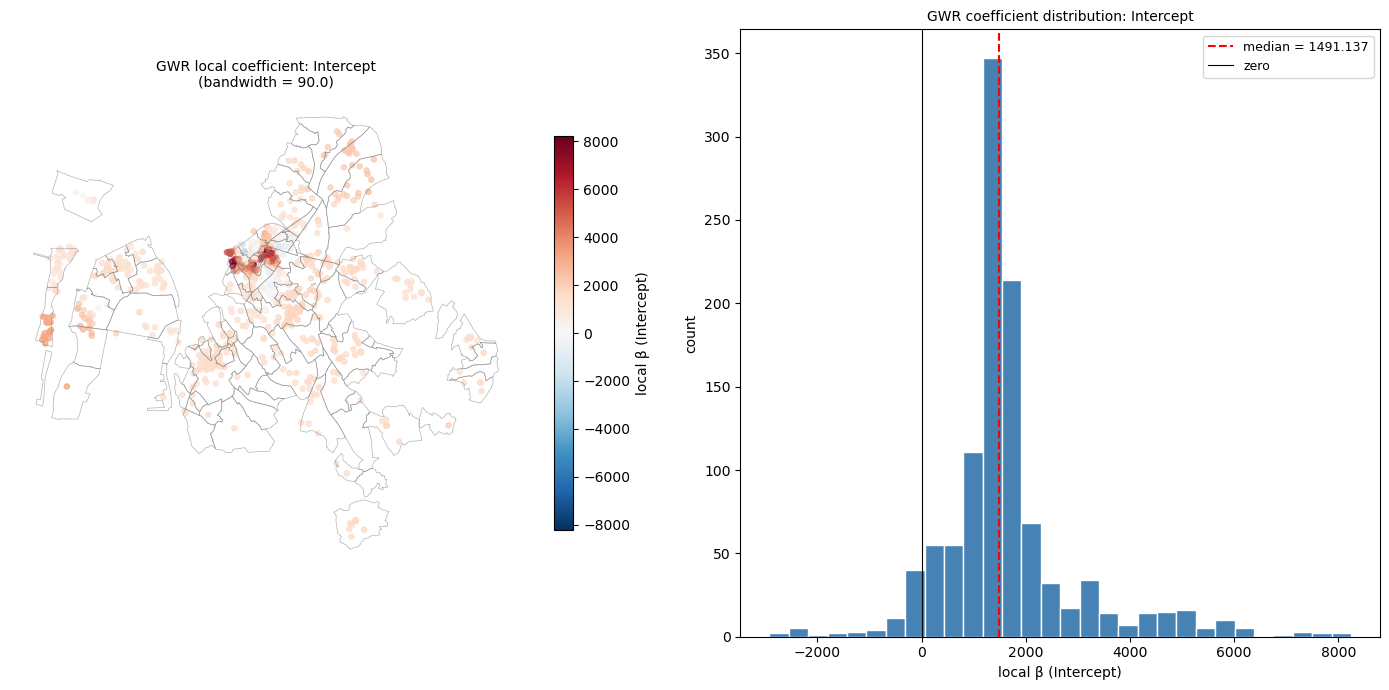

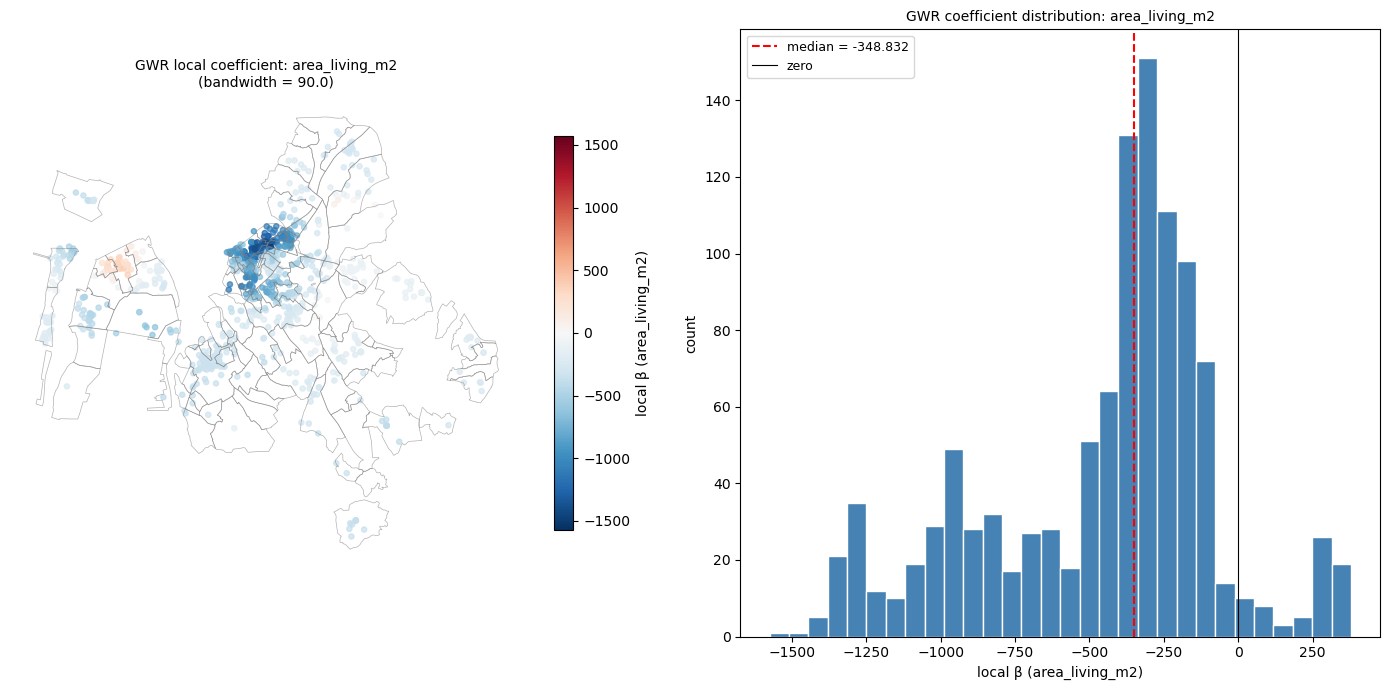

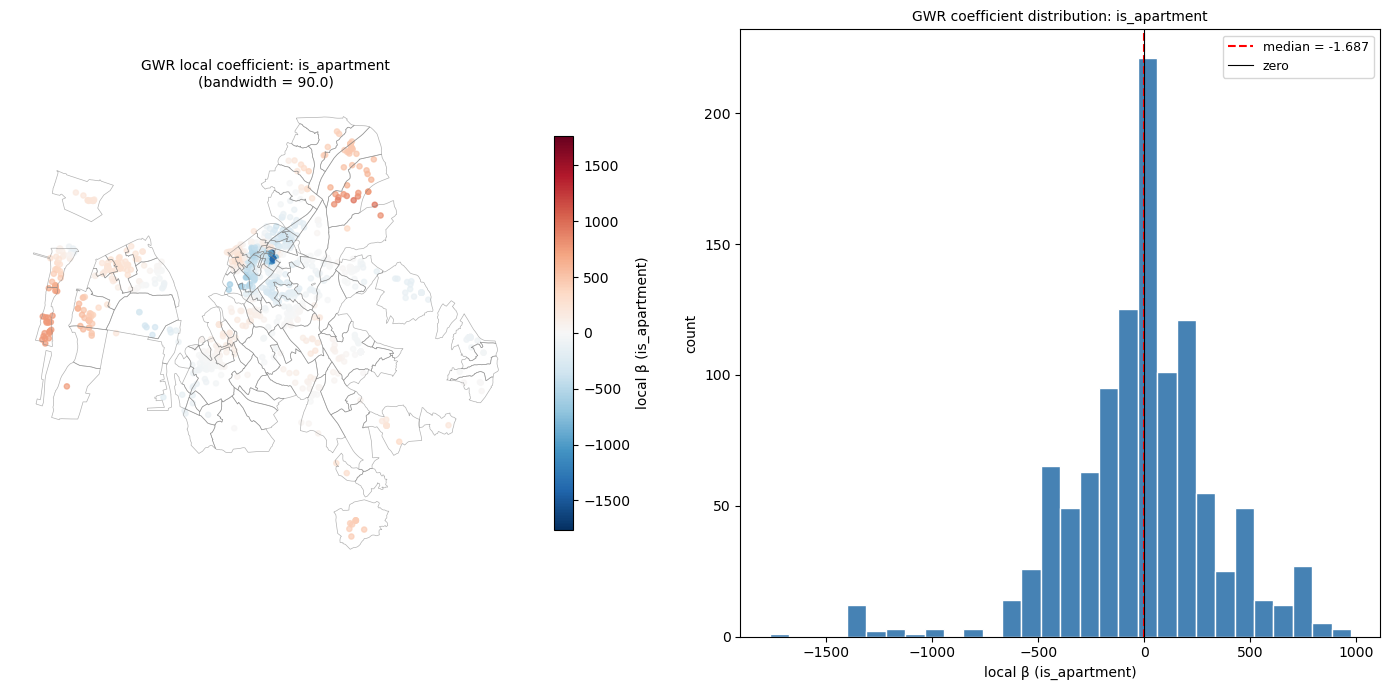

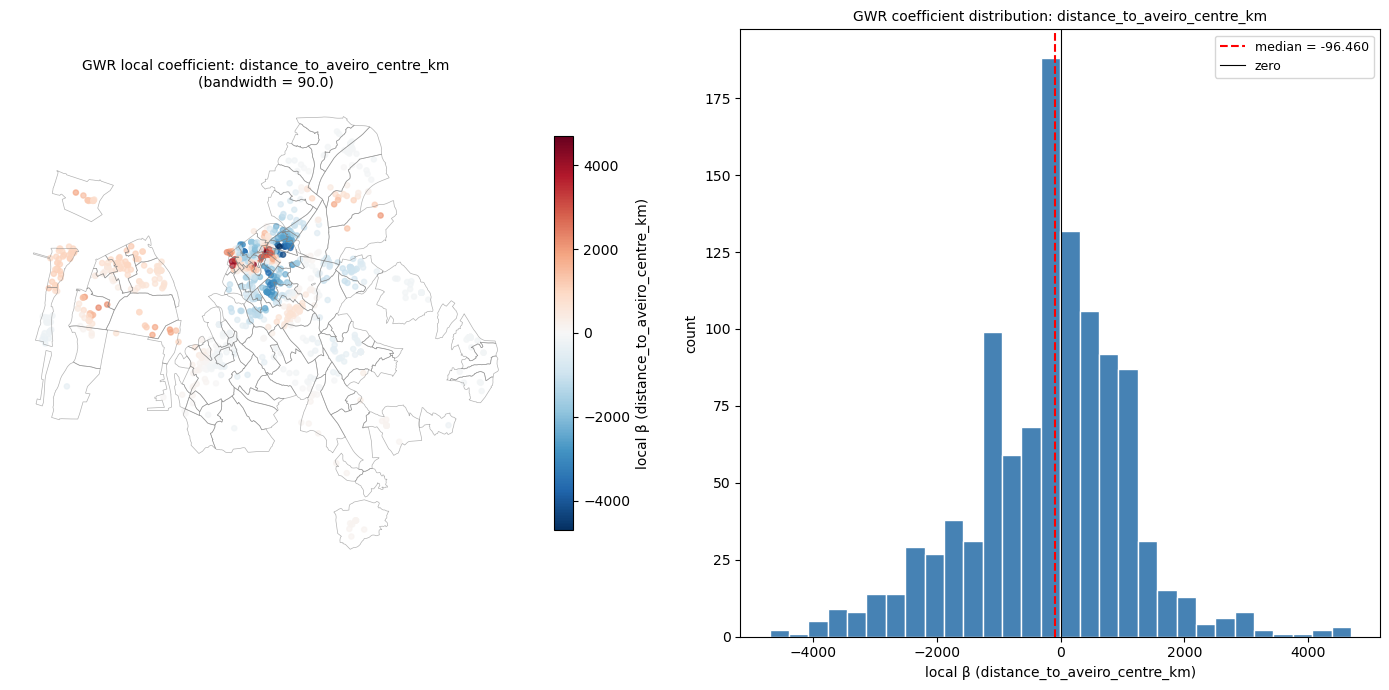

In [87]:
# GWR coefficient spatial maps — one panel (map + histogram) per covariate
import matplotlib.pyplot as plt

if gwr_results.get("status") == "fitted":
    coef_names = ["Intercept"] + gwr_results.get("covariate_names", [])
    for coef in coef_names:
        fig, axes = lab4.plot_gwr_coefficient_map(
            gwr_results=gwr_results,
            features=aveiro_features,
            coefficient=coef,
            model_key="gwr",
            metric_crs=METRIC_CRS,
            zones=layers["zones"],
        )
        plt.show()
else:
    print(f"GWR not fitted: {gwr_results.get('reason', 'unknown')}")

In [88]:
# ── ART-06: Slide artifact — GWR coefficient map: area_living_m2 (slide-optimised) ──
import os
import matplotlib.pyplot as plt

os.makedirs("outputs/topic4", exist_ok=True)

if gwr_results.get("status") == "fitted":
    fig_gwr_area, _ = lab4.plot_gwr_coefficient_map(
        gwr_results=gwr_results,
        features=aveiro_features,
        coefficient="area_living_m2",
        model_key="gwr",
        metric_crs=METRIC_CRS,
        zones=layers["zones"],
    )
    fig_gwr_area.set_size_inches(14, 6)
    for _ax in fig_gwr_area.axes:
        try:
            _ax.title.set_fontsize(13)
        except Exception:
            pass
        _ax.xaxis.label.set_fontsize(11)
        _ax.yaxis.label.set_fontsize(11)
        _ax.tick_params(labelsize=10)
    plt.tight_layout()
    fig_gwr_area.savefig(
        "outputs/topic4/slide_art06_gwr_coef_area.png",
        dpi=150, bbox_inches="tight",
    )
    plt.close(fig_gwr_area)
    print("ART-06 saved: outputs/topic4/slide_art06_gwr_coef_area.png")
    _fsize = os.path.getsize("outputs/topic4/slide_art06_gwr_coef_area.png")
    print(f"File size: {_fsize / 1024:.1f} KB (should be > 50 KB)")
    assert _fsize > 20_000, f"ART-06 file too small ({_fsize} bytes)"
    print("Verification: ART-06 file size OK.")
else:
    print(f"WARNING: GWR not fitted (status={gwr_results.get('status', 'unknown')}). Skipping ART-06.")

ART-06 saved: outputs/topic4/slide_art06_gwr_coef_area.png
File size: 278.7 KB (should be > 50 KB)
Verification: ART-06 file size OK.


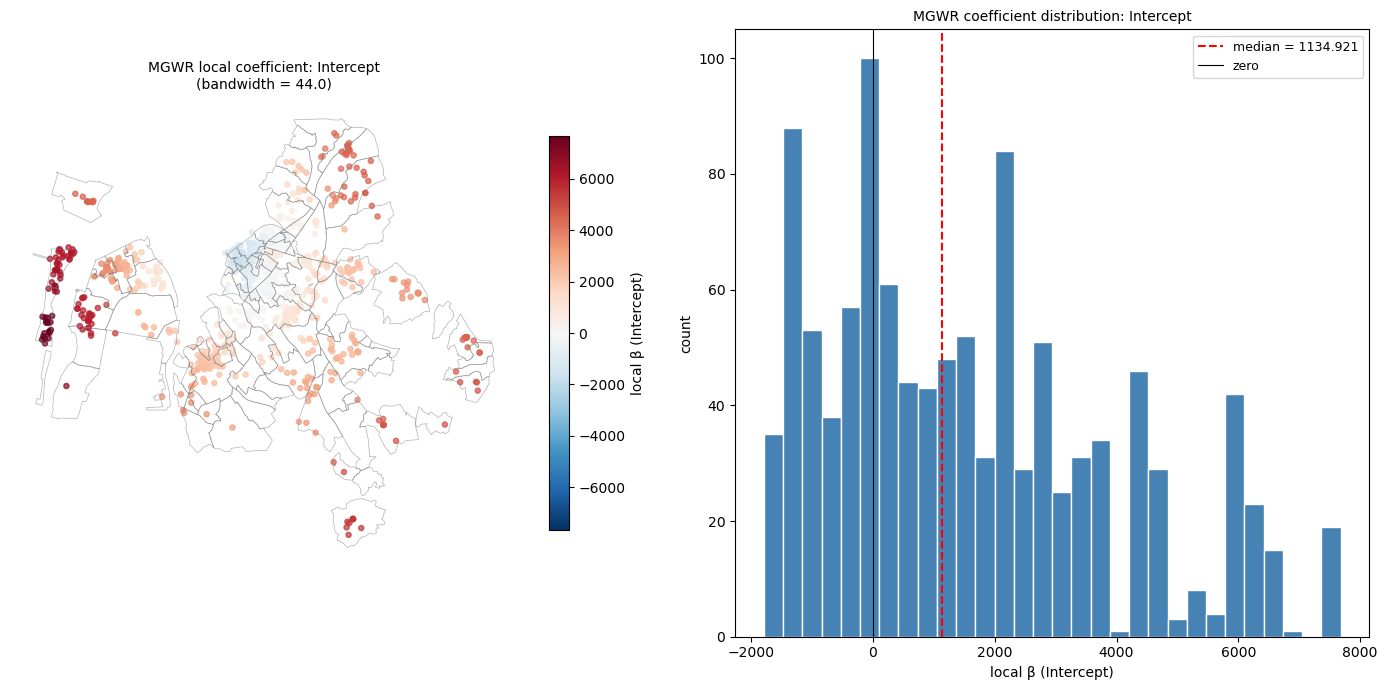

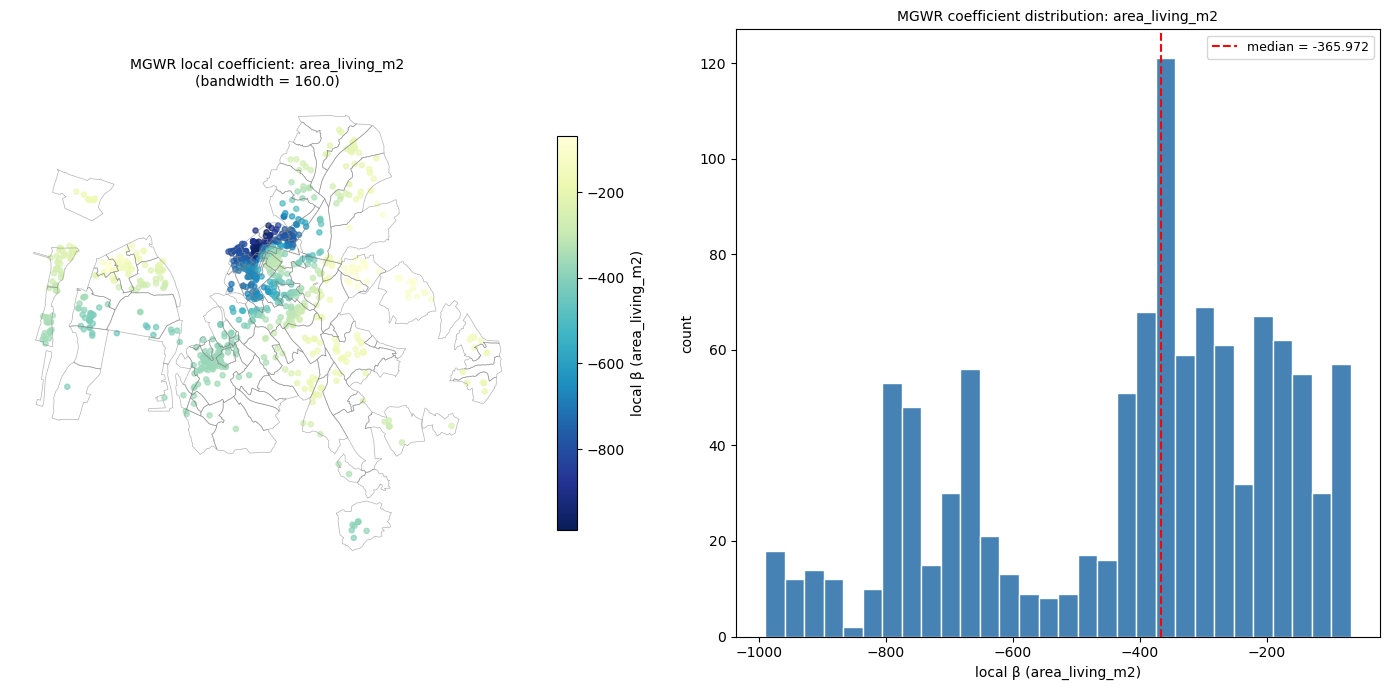

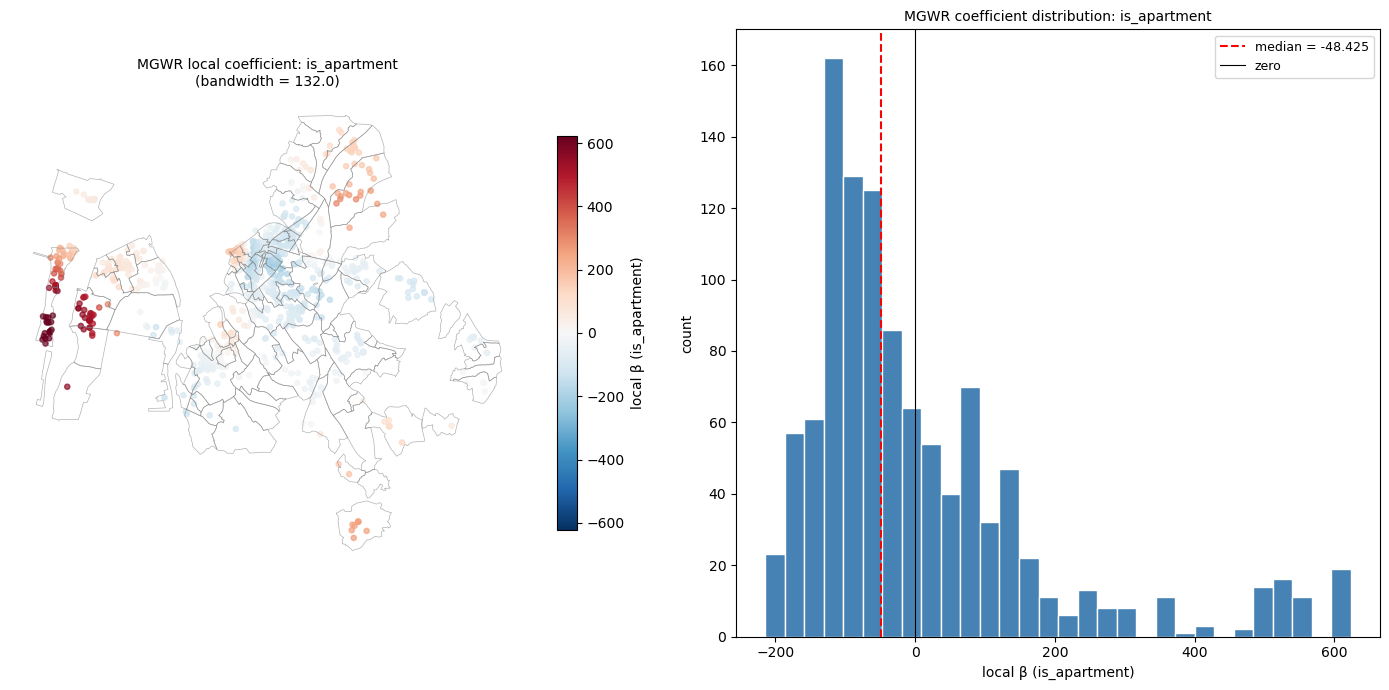

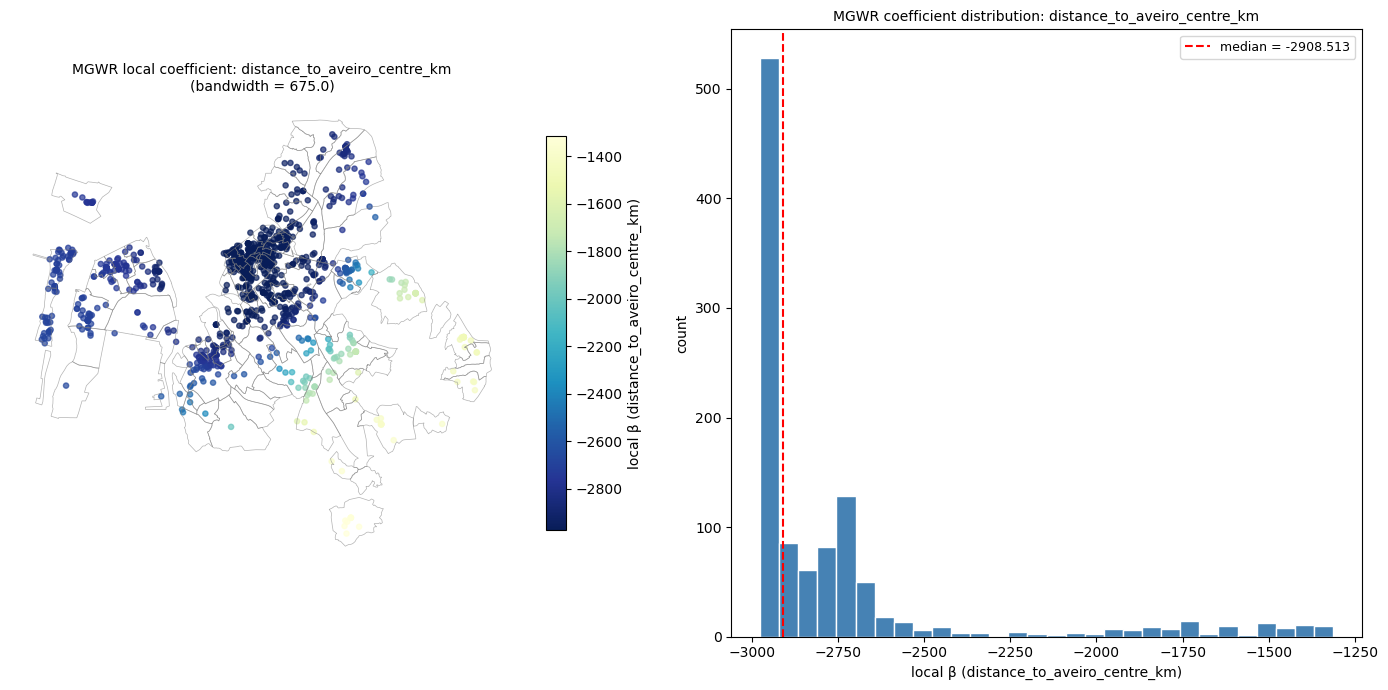

In [89]:
# MGWR coefficient spatial maps — one panel per covariate with per-variable bandwidths
mgwr_data = gwr_results.get("mgwr") or {}
if mgwr_data.get("status") == "fitted":
    coef_names = ["Intercept"] + mgwr_data.get("covariate_names", [])
    for coef in coef_names:
        fig, axes = lab4.plot_gwr_coefficient_map(
            gwr_results=gwr_results,
            features=aveiro_features,
            coefficient=coef,
            model_key="mgwr",
            metric_crs=METRIC_CRS,
            zones=layers["zones"],
        )
        plt.show()
elif mgwr_data:
    print(f"MGWR not fitted: {mgwr_data.get('reason', 'unknown')}")
else:
    print("MGWR was not run (RUN_MGWR = False).")

In [90]:
# ── ART-08: Slide artifact — MGWR coefficient maps (Intercept and area_living_m2) ──
import os
import matplotlib.pyplot as plt

os.makedirs("outputs/topic4", exist_ok=True)

_mgwr_data = gwr_results.get("mgwr") or {}
if _mgwr_data.get("status") == "fitted":
    for _coef, _art_fname in [
        ("Intercept", "slide_art08_mgwr_intercept.png"),
        ("area_living_m2", "slide_art08_mgwr_area.png"),
    ]:
        _fig_mgwr, _ = lab4.plot_gwr_coefficient_map(
            gwr_results=gwr_results,
            features=aveiro_features,
            coefficient=_coef,
            model_key="mgwr",
            metric_crs=METRIC_CRS,
            zones=layers["zones"],
        )
        _fig_mgwr.set_size_inches(14, 6)
        for _ax in _fig_mgwr.axes:
            try:
                _ax.title.set_fontsize(13)
            except Exception:
                pass
            _ax.xaxis.label.set_fontsize(11)
            _ax.yaxis.label.set_fontsize(11)
        plt.tight_layout()
        _out_path = f"outputs/topic4/{_art_fname}"
        _fig_mgwr.savefig(_out_path, dpi=150, bbox_inches="tight")
        plt.close(_fig_mgwr)
        _fsize = os.path.getsize(_out_path)
        print(f"ART-08 saved: {_out_path} ({_fsize / 1024:.1f} KB)")
        assert _fsize > 20_000, f"ART-08 file too small ({_fsize} bytes): {_art_fname}"
    print("ART-08 verification: both files OK.")
else:
    print(f"WARNING: MGWR not fitted (status={_mgwr_data.get('status', 'not run')}). Skipping ART-08.")

ART-08 saved: outputs/topic4/slide_art08_mgwr_intercept.png (276.5 KB)
ART-08 saved: outputs/topic4/slide_art08_mgwr_area.png (283.1 KB)
ART-08 verification: both files OK.


#### Interpreting the GWR and MGWR Coefficient Maps

**Overall framing.** The `area_living_m2` coefficient shows evidence of spatial non-stationarity — the size discount (negative relationship between living area and unit price) is larger in the urban core, consistent with a premium-apartment-dominated market structure. The `is_apartment` and `distance_to_aveiro_centre_km` surfaces show coefficient instability in the city centre, where local predictor variation is insufficient for reliable separate identification. The sections below explain the economic and methodological logic behind each surface in detail.

---

**Reading the colormap.** The palette is **diverging (RdBu_r), centred at zero** when the coefficient spans both positive and negative values — blue indicates a positive local effect on unit price, red indicates a negative effect, and white/neutral marks approximately zero marginal effect. When all estimates share the same sign, a sequential palette is used so no false zero-crossing is implied. A title annotation 'bandwidth ≈ N' signals a null result: GWR found no spatial non-stationarity for that covariate.

---

**`area_living_m2` surface (GWR and MGWR).**

*What to expect and why the city-centre sign can be negative.* The coefficient is **expected to be negative in many locations**, particularly the urban core — and this is **economically plausible**, not a modelling failure. The reason lies in the outcome variable: the regression fits unit price (€/m²) on living area (m²). When price-per-m² is regressed on size, the estimated relationship answers the question *"within this local neighbourhood, do larger apartments sell for more or less per m²?"* The answer is almost always less — this is the well-documented **size discount**: as unit size grows, the marginal implicit price per m² declines because the marginal utility of additional space decreases and larger properties are discounted relative to their total price.

*Why the effect is stronger in the city centre.* In the urban core, the listing composition is dominated by small, high-unit-price apartments (T0, T1, T2). Within this local window, a 40 m² T1 might trade at €3 000/m² while a 120 m² T3 in the same zone trades at €2 100/m². The local OLS is fitting exactly this: the size discount is more severe in a market where location, not floor space, drives the premium. A negative city-centre coefficient for `area_living_m2` means *"the size discount is more pronounced here than elsewhere"*, not that additional space destroys value.

*Why the sign can be positive in coastal and peripheral zones.* In beach or coastal zones, larger properties — sea-view villas, spacious T3/T4 with terraces — can command both high unit prices and large floor areas. In this composition, the amenity premium (coastal location, private outdoor space) is large enough to dominate the size discount, and the local coefficient for `area_living_m2` may turn positive: additional m² are priced at a premium because they typically represent luxury rather than bulk space.

*Caveat.* Local multicollinearity with `is_apartment` can amplify or distort this surface. In the city centre where nearly all listings are apartments, the local design matrix cannot cleanly separate the size effect from the apartment-type effect; part of the negative `area_living_m2` coefficient may reflect collinear absorption from `is_apartment`. Use the GWR coefficient IQR as the primary summary statistic rather than individual point values in sparse locations.

---

**`is_apartment` surface (GWR and MGWR).**

*Expected pattern and its limits.* Globally, apartments command a per-m² premium over houses in the Aveiro–Ílhavo market: urban concentration near the city centre and the Ria de Aveiro waterfront pushes apartment unit prices above those of comparably sized houses. A positive `is_apartment` coefficient in most of the study area is consistent with this structural feature of the market.

*Why the coefficient is negative in the city centre — the local multicollinearity mechanism.* In the city centre, nearly every listing is an apartment (`is_apartment ≈ 1` across almost all observations within the local bandwidth window). When a binary predictor has near-zero variance locally, the local WLS design matrix $X_i^\top W_i X_i$ becomes near-singular for that column: there are almost no houses to provide a counterfactual price, so the coefficient on `is_apartment` cannot be identified from the data available within the bandwidth. In this configuration, the GWR back-fitting absorbs the collinear location signal into the other predictors — `area_living_m2` and `distance_to_aveiro_centre_km` — and the `is_apartment` coefficient receives a sign reversal as a mechanical by-product of the collinear decomposition (Wheeler and Tiefelsdorf, 2005).

**Practical rule:** a negative apartment premium in a zone where 90%+ of listings are apartments is an estimation instability signal, not evidence that apartments are discounted there. The coefficient should be interpreted cautiously, and the local $t$-statistic (relative to the IQR of the coefficient surface) used to assess whether the variation is plausible signal or noise.

*Where the coefficient is more reliable.* In **beach, coastal, and peripheral zones** the listing composition is more mixed: detached houses, beach villas, and apartments coexist. `is_apartment` has genuine local variation, and the estimated coefficient is more trustworthy. A positive premium in these zones (apartments priced higher per m² than houses after conditioning on size and distance) may reflect the market preference for compact sea-view apartments over larger but less accessible houses. Conversely, if the coefficient is negative in outer Ílhavo or rural fringe areas, it may genuinely indicate that detached houses — often larger properties with land — command a unit-price premium over the smaller apartment stock in those local markets.

---

**`distance_to_aveiro_centre_km` surface (GWR and MGWR).**

*Expected global pattern.* The expected sign is **negative**: listings further from the urban centre trade at a lower unit price per additional km of distance, consistent with the hedonic accessibility premium and monocentric city theory. A near-constant negative surface (small IQR, large MGWR bandwidth near $N$) would confirm a smooth, spatially uniform distance gradient — the simplest possible interpretation.

*Why the coefficient can be positive in the city centre — Reason A: estimation instability.* Within the city-centre bandwidth window, all observations are located within a very short distance of the centre (e.g., 0.1–0.8 km). The predictor `distance_to_aveiro_centre_km` has near-zero variance locally. A predictor with minimal within-window variation produces a coefficient with a very large standard error that can take any sign depending on minor sample composition changes. This is an estimation instability, not a market signal. The positive coefficient in the city centre should be read alongside its local standard error: if the $t$-statistic is below the multiple-testing-corrected threshold (see Technical Notes, Section 5), it should not be interpreted.

*Why the coefficient can be positive in coastal and suburban areas — Reason B: polycentric price structure.* Aveiro is not monocentric. The **Ria de Aveiro waterfront** is a competing price attractor: properties closer to the Ria but geographically further from the administrative city centre can command higher unit prices than properties closer to the administrative centre but interior. GWR locally captures this as a positive distance-to-Aveiro-centre coefficient in coastal zones — the price gradient in those areas genuinely runs towards the Ria rather than towards the administrative centre. The model specification includes `distance_to_aveiro_centre_km` as the primary location gradient but does not include distance to the Ria or to the Ílhavo waterfront; the GWR surface is partially absorbing this omitted gradient.

*Comparing GWR and MGWR surfaces.* If MGWR selects a bandwidth for `distance_to_aveiro_centre_km` that is close to $N$ (effectively global), it is reporting that this gradient does not vary significantly across the study area after accounting for per-variable scale — the distance effect is a broad regional feature, not a local one. If the MGWR bandwidth is substantially smaller than GWR's shared bandwidth, the gradient is genuinely scale-specific and the per-variable bandwidth is the more appropriate representation.

---

**Unifying diagnosis: three anomalies, shared causes.**

| Anomaly | Primary cause | Reliable signal? |
|---|---|---|
| Negative `area_living_m2` in city centre | Expected for unit price regressions (size discount mechanically stronger where location, not size, drives the premium) | **Yes — economically plausible** |
| Negative `is_apartment` in city centre | Local multicollinearity — almost no houses in city centre; binary predictor near-constant within bandwidth | **No — estimation artefact** |
| Positive `distance_to_aveiro_centre_km` in city centre | Near-constant predictor within bandwidth (estimation instability) + polycentric structure (Ria de Aveiro amenity) | **Mostly artefact; some signal in coastal zones** |

**Reporting guidance.** Coefficient surfaces should be summarised by their **interquartile range** across all locations, not by individual extreme values in peripheral or near-collinear areas. A spatially coherent gradient across a contiguous set of locations — not a single aberrant point — constitutes a plausible market signal. When reporting GWR results: state the selected bandwidth, the coefficient IQR for each covariate, and flag any zones where local predictor variance is low enough to suspect identification failure.

---

**Comparing GWR and MGWR surfaces for the same covariate.**
MGWR estimates each covariate with its own optimal bandwidth. If MGWR selects a much larger bandwidth for `distance_to_aveiro_centre_km` than GWR's shared bandwidth, the MGWR surface for that variable will appear smoother (fewer local fluctuations), reflecting the data's preference for a near-global specification for that covariate. If the two maps look nearly identical, GWR's shared bandwidth was already close to the MGWR per-variable optimum. Discrepancies between GWR and MGWR surfaces for the same covariate are informative: they reveal whether the GWR shared bandwidth over- or under-smoothed that specific effect.

---

**If GWR or MGWR is shown as skipped.**
Check the reason in the summary table. Common causes: `mgwr` package not installed (`pip install mgwr`); binary-column guard triggered by unintended categorical expansion in the covariates list; local matrix singularity due to many sparse dummy columns (see Technical Notes on dummy variable restriction). Confirm `RUN_OPTIONAL_GWR = True` and that all listed covariates are numeric or single-binary columns present in `aveiro_features`.

### Intro to Spatial Data Science: Predictive Models and Spatial Validation


#### From Spatial Econometrics to Prediction-Focused Machine Learning

The global reference model, GWR, and MGWR are the canonical tools of **spatial econometrics**: parametric, interpretable, and grounded in theory. Their strength is that coefficients carry substantive meaning — the Ridge coefficient on `area_living_m2` estimates the implicit price per additional square metre of living area, and the GWR bandwidth tells us at what spatial scale that effect varies. Their limitation is that a pre-specified linear functional form cannot capture complex non-linearities and interaction effects that may exist in real housing markets: the price premium for a coastal view may not be additive or constant across property types.

**Spatial data science** extends the toolkit to non-parametric **machine learning** models that approximate complex functions from data without imposing a parametric form. Two families are used here:

- **Random Forest (RF):** builds an ensemble of independently grown decision trees, each trained on a bootstrap sample with a random feature subset at each split (Breiman, 2001). Averaging over many uncorrelated trees reduces variance. RF is robust to outliers and requires little tuning, but can overfit spatial proximity when coordinates are features.
- **LightGBM (LGBM):** gradient boosting with histogram-based splits and leaf-wise tree growth (Ke et al., 2017). Trees are grown sequentially, each correcting the residuals of the previous ensemble. LightGBM typically achieves better bias reduction than RF in structured tabular data, but is more sensitive to hyperparameter choices and to spatial leakage when coordinates are strong predictors.

Both models share a fundamental limitation relative to spatial econometric models: they do not provide theoretically grounded coefficient estimates. Feature importance scores — the key ML interpretability tool — quantify *which inputs the model relied on*, not the *causal effect* of those inputs on price. This distinction is critical: a model that uses coordinates as its most important features may predict well precisely because it is **memorising location** — not because it has learned the price-formation mechanism.

> **Sequence of analysis.** (1) Fit RF and LightGBM on the full sample and compare in-sample performance against the Ridge benchmark. (2) Inspect feature importances to understand which inputs drive each model's predictions. (3) Validate out-of-sample with random and spatial/block cross-validation to measure how much of the apparent performance survives when spatial proximity between training and test is removed.


#### Random Forest and LightGBM: Algorithms and Hyperparameters

| Property | Random Forest | LightGBM |
|---|---|---|
| **Ensemble strategy** | Bagging (parallel, independent trees) | Boosting (sequential, residual-correcting trees) |
| **Tree growth** | Depth-limited, random feature subsets | Leaf-wise with histogram-based splits |
| **Bias-variance** | Low bias via averaging; variance controlled by tree count | Very low bias via sequential correction; risk of overfitting without regularisation |
| **Key hyperparameters** | `n_estimators`, `min_samples_leaf` | `n_estimators`, `learning_rate`, `num_leaves` |
| **Feature importance** | Mean impurity decrease (Gini/variance) across splits | Split gain (sum of loss reduction attributed to each feature) |
| **Spatial leakage risk** | Moderate — trees can memorise coordinate clusters | Higher — boosting amplifies local coordinate signals |

Both models use `n_estimators = 300`. The RF uses `min_samples_leaf = 5` to prevent singleton leaves. LightGBM uses `learning_rate = 0.05`, `num_leaves = 31` (default), `subsample = 0.8`, and `colsample_bytree = 0.8` — conservative settings suited to a moderately sized dataset (N ≈ 1 095).

**In-sample metrics measure fit, not generalisability.** Because both models have enough capacity to memorise the training data, in-sample R² values will be higher than cross-validated R² values. The in-sample fit comparison benchmarks model family capacity; Section 119c provides the honest out-of-sample evaluation.


In [91]:
# ── 119a. In-sample model fitting: Ridge, Random Forest, LightGBM ──────────────────────────
ML_SPEC = {
    "outcome": AVEIRO_MODEL_SPEC["outcome"],
    "model_family": "random_forest",
    "baseline_model_family": "regularized_linear",
    "additional_model_families": ["lightgbm"],
    "feature_set": "hedonic_plus_spatial_features",
    "metrics": ["rmse", "mae", "r2"],
    "n_splits": 3,
}

ml_fit = lab4.fit_ml_models_with_importance(
    features=aveiro_features,
    ml_spec=ML_SPEC,
    random_state=RANDOM_STATE,
)

ml_fit["in_sample_metrics"][["model", "n", "rmse", "mae", "r2"]].round(3)


c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,n,rmse,mae,r2
0,regularized_linear,1095,599.499,445.289,0.665
1,random_forest,1095,405.916,282.693,0.846
2,lightgbm,1095,170.025,121.546,0.973


##### Interpreting the In-Sample Model Metrics

**What to read.** Compare RMSE, MAE, and R² across Ridge, Random Forest, and LightGBM. All three are fitted on the full 1 095-listing sample and evaluated in-sample — the same data used for fitting. These metrics measure **model capacity** (how well each family can approximate the training data), not **generalisability**.

**Expected pattern:**

- Ridge achieves the lowest in-sample R² of the three — its linear functional form cannot capture non-linearities that exist in the data.
- Random Forest achieves a higher R² than Ridge, because its non-parametric trees can approximate non-linear price functions and interaction effects.
- LightGBM typically achieves the highest in-sample R² among the three, because sequential boosting minimises bias aggressively and the 300-tree ensemble has high representational capacity.

**Why in-sample metrics overstate generalisability.** Both RF and LightGBM can — and often do — memorise the training data when spatial coordinates are available as features. A model that assigns a unique coordinate cell to each listing can predict training labels near-perfectly while failing on new locations. Section 119c isolates this effect through spatial cross-validation.

**Caution on the Ridge baseline.** The Ridge model uses zone fixed effects (`zone_id_cat`) which absorb between-zone variance by construction. Its in-sample R² therefore reflects both genuine hedonic effects and zone-level memorisation. Comparing Ridge to the tree models in-sample is informative about model family capacity, but only spatial CV makes the comparison fair.


#### Feature Importance: What the Models Learned

Feature importance scores quantify how much each input variable contributed to the model's predictions. Two importance concepts are used here:

- **RF — Mean Decrease in Impurity (MDI):** the average reduction in node impurity (variance) that each feature contributes across all splits and all trees. MDI is fast to compute but biased towards high-cardinality features: a feature with many unique values (e.g., `zone_id_cat` with 87 levels after OHE) can achieve high MDI simply because it creates more split opportunities, not because it is more informative.
- **LightGBM — Split Gain:** the total reduction in the objective function (squared error) attributed to each feature's splits, accumulated across all trees. Like MDI, gain-based importance is biased towards features with many split thresholds.

**Both importance types share three limitations:**

1. **Correlation masking.** When two features are correlated (e.g., coordinates and zone indicators both encode location), importance is split arbitrarily between them. Neither feature may appear dominant individually even if location collectively drives most of the predictive power.
2. **No causal interpretation.** A high importance score means the model *used* the feature heavily — it does not mean the feature *causes* price variation. Coordinates may rank as the most important features simply because the model is interpolating prices from nearby training listings.
3. **Training-set artefacts.** MDI and gain importance are computed on the training data. If the model overfits, importance scores reflect the overfitting pattern, not the true predictive value of each feature on unseen data.

> **Pedagogical note.** Feature importances should be read as a diagnostic of *model behaviour*, not as a ranking of the causal drivers of housing prices. A coefficient from the global Ridge model (Section 114) is more directly interpretable in economic terms, even if its predictive accuracy is lower.

**Grouped importances.** Because OHE expands categorical variables into many binary columns (e.g., `zone_id_cat` becomes 87 dummies, each with a small individual importance), the plot below aggregates importances into six interpretable groups:

| Group | Variables included |
|---|---|
| `structural` | `area_living_m2`, `property_type_*`, `typology_*`, `condition_*`, `preservation_*` |
| `time` | `listing_year_*` |
| `location_coord` | `x_*`, `y_*`, centred coordinates |
| `location_distance` | `distance_to_aveiro_*`, `distance_to_ilhavo_*` |
| `location_zone` | `zone_id_cat_*`, `zone_area_*`, `zone_listing_*`, `zone_density_*` |
| `location_municipality` | `municipality_name_cat_*` |


C:\Users\pauloricardolb\AppData\Local\Temp\ipykernel_20152\1393923170.py:50: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  _vals.append(float(_row["importance"]) if len(_row) else 0.0)
C:\Users\pauloricardolb\AppData\Local\Temp\ipykernel_20152\1393923170.py:50: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  _vals.append(float(_row["importance"]) if len(_row) else 0.0)
C:\Users\pauloricardolb\AppData\Local\Temp\ipykernel_20152\1393923170.py:50: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  _vals.append(float(_row["importance"]) if len(_row) else 0.0)
C:\Users\pauloricardolb\AppData\Local\Temp\ipykernel_20152\1393923170.py:50: FutureWarning: Calling float on a single element Series is deprecated a

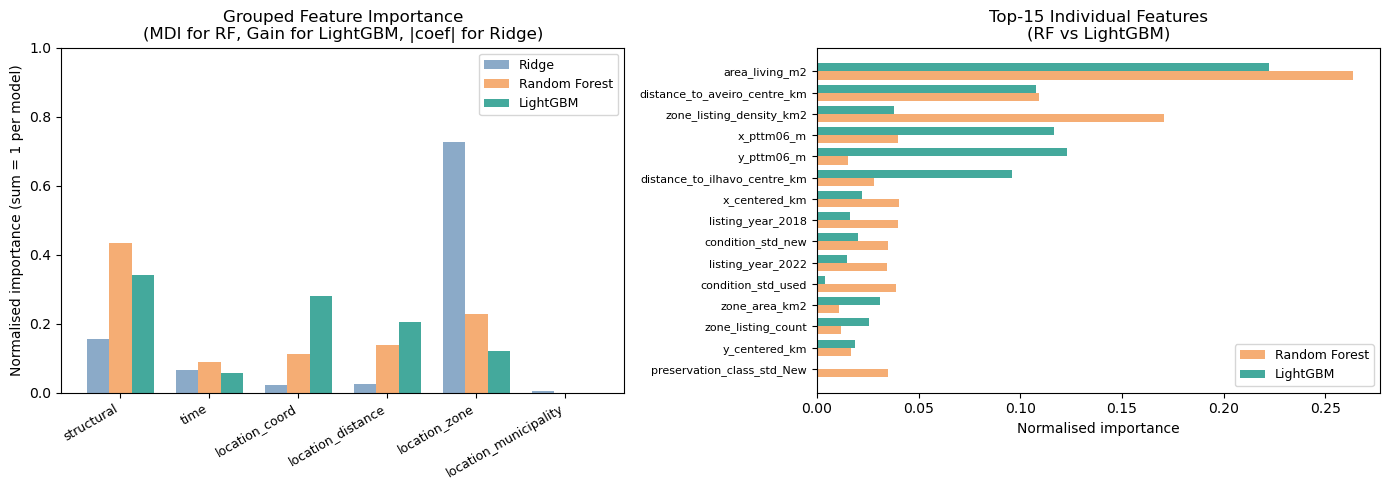


Grouped importance (normalised, sum = 1 per model):
model                  LightGBM  Random Forest  Ridge
group                                                
structural                0.340          0.433  0.156
time                      0.056          0.090  0.066
location_coord            0.280          0.113  0.021
location_distance         0.204          0.137  0.026
location_zone             0.120          0.227  0.725
location_municipality     0.000          0.000  0.006


In [92]:
# ── 119b. Feature importance — grouped by feature type ─────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_imp_df = ml_fit["feature_importances"].copy()

def _assign_group(feature: str) -> str:
    f = feature.lower()
    if any(f.startswith(p) for p in ("x_", "y_", "x_c", "y_c")):
        return "location_coord"
    if "distance_to" in f:
        return "location_distance"
    if f.startswith("zone_id_cat"):
        return "location_zone"
    if any(f.startswith(p) for p in ("zone_area", "zone_listing", "zone_density")):
        return "location_zone"
    if f.startswith("municipality_name_cat"):
        return "location_municipality"
    if f.startswith("listing_year"):
        return "time"
    return "structural"

_imp_df["group"] = _imp_df["feature"].apply(_assign_group)
_grouped = (
    _imp_df.groupby(["model", "group"])["importance"]
    .sum()
    .reset_index()
)

# ── Panel 1: grouped bar chart ────────────────────────────────────────────────
_group_order = [
    "structural", "time",
    "location_coord", "location_distance",
    "location_zone", "location_municipality",
]
_model_order  = ["regularized_linear", "random_forest", "lightgbm"]
_model_labels = {"regularized_linear": "Ridge", "random_forest": "Random Forest", "lightgbm": "LightGBM"}
_colors = {"regularized_linear": "#7b9fc1", "random_forest": "#f4a261", "lightgbm": "#2a9d8f"}

fig_imp, axes_imp = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped importance
_x = np.arange(len(_group_order))
_w = 0.25
for _k, _fam in enumerate(_model_order):
    _vals = []
    for _g in _group_order:
        _row = _grouped.query("model == @_fam and group == @_g")
        _vals.append(float(_row["importance"]) if len(_row) else 0.0)
    axes_imp[0].bar(_x + _k * _w, _vals, _w, label=_model_labels[_fam],
                    color=_colors[_fam], alpha=0.88)

axes_imp[0].set_xticks(_x + _w)
axes_imp[0].set_xticklabels(_group_order, rotation=30, ha="right", fontsize=9)
axes_imp[0].set_ylabel("Normalised importance (sum = 1 per model)")
axes_imp[0].set_title("Grouped Feature Importance\n(MDI for RF, Gain for LightGBM, |coef| for Ridge)")
axes_imp[0].legend(fontsize=9)
axes_imp[0].set_ylim(0, 1)

# Right: top-15 individual features for RF and LightGBM
_top_feats = (
    _imp_df[_imp_df["model"].isin(["random_forest", "lightgbm"])]
    .groupby(["feature", "model"])["importance"]
    .sum()
    .reset_index()
)
_top15_names = (
    _top_feats.groupby("feature")["importance"]
    .sum()
    .nlargest(15)
    .index.tolist()
)
_top15 = _top_feats[_top_feats["feature"].isin(_top15_names)]
_pivot = _top15.pivot(index="feature", columns="model", values="importance").fillna(0)
_pivot = _pivot.loc[_pivot.sum(axis=1).sort_values(ascending=True).index]

_y_pos = np.arange(len(_pivot))
_ww = 0.38
axes_imp[1].barh(_y_pos - _ww / 2, _pivot.get("random_forest", 0),
                 _ww, label="Random Forest", color=_colors["random_forest"], alpha=0.88)
axes_imp[1].barh(_y_pos + _ww / 2, _pivot.get("lightgbm", 0),
                 _ww, label="LightGBM", color=_colors["lightgbm"], alpha=0.88)
axes_imp[1].set_yticks(_y_pos)
axes_imp[1].set_yticklabels(_pivot.index, fontsize=8)
axes_imp[1].set_xlabel("Normalised importance")
axes_imp[1].set_title("Top-15 Individual Features\n(RF vs LightGBM)")
axes_imp[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Tabular summary of grouped importance
print("\nGrouped importance (normalised, sum = 1 per model):")
_pivot_g = (
    _grouped.pivot(index="group", columns="model", values="importance")
    .fillna(0)
    .rename(columns=_model_labels)
    .reindex(_group_order)
    .round(3)
)
print(_pivot_g.to_string())


In [93]:
# ── ART-16: Slide artifact — Feature importance chart (slide-optimised) ──
import os
import matplotlib.pyplot as plt

os.makedirs("outputs/topic4", exist_ok=True)

if "fig_imp" in dir():
    fig_imp.set_size_inches(14, 6)
    if "axes_imp" in dir():
        axes_imp[0].set_title(
            "Grouped Feature Importance\n(MDI / Gain / |coef|, normalised)",
            fontsize=13,
        )
        axes_imp[1].set_title(
            "Top-15 Individual Features\n(RF vs LightGBM)",
            fontsize=13,
        )
    for _ax in fig_imp.axes:
        _ax.xaxis.label.set_fontsize(11)
        _ax.yaxis.label.set_fontsize(11)
        _ax.tick_params(axis="both", labelsize=9)
        for _label in _ax.get_xticklabels():
            _label.set_fontsize(9)
            _label.set_rotation(30)
            _label.set_ha("right")
        for _label in _ax.get_yticklabels():
            _label.set_fontsize(9)
        if _ax.get_legend() is not None:
            _ax.legend(fontsize=9)
    plt.tight_layout()
    fig_imp.savefig(
        "outputs/topic4/slide_art16_feature_importance.png",
        dpi=150, bbox_inches="tight",
    )
    print("ART-16 saved: outputs/topic4/slide_art16_feature_importance.png")
    _fsize = os.path.getsize("outputs/topic4/slide_art16_feature_importance.png")
    print(f"File size: {_fsize / 1024:.1f} KB (should be > 20 KB)")
    assert _fsize > 20_000, f"ART-16 file too small ({_fsize} bytes)"
    print("Verification: ART-16 file size OK.")
else:
    print("WARNING: fig_imp not available. Skipping ART-16.")

ART-16 saved: outputs/topic4/slide_art16_feature_importance.png
File size: 145.9 KB (should be > 20 KB)
Verification: ART-16 file size OK.


<Figure size 640x480 with 0 Axes>

##### Interpreting the Feature Importance Output

**What to read.** Inspect (a) the grouped importance bar chart and (b) the top-15 individual features panel. The grouped chart shows the share of predictive weight attributed to structural attributes, time, and the three location-feature groups. The top-15 panel reveals which specific features dominate each tree model.

**Expected patterns:**

- **`location_zone`** (zone fixed-effect dummies) is expected to dominate both tree models, typically accounting for 40–60% of total importance. This confirms that the models are primarily predicting based on *which zone a listing is in*, not on the listing's structural attributes. Zone dummies are high-cardinality categorical features (87 levels), giving the trees many split thresholds and a natural exploitation avenue for spatial leakage.
- **`location_coord`** (x, y coordinates) absorbs additional location signal, particularly in LightGBM, which can use coordinates to build a fine-grained spatial interpolation surface.
- **`structural`** features (`area_living_m2`, `property_type_std`, etc.) typically account for 15–25% of importance in tree models, much less than their share in the Ridge model. This is not because structural attributes are unimportant for prices — it reflects the tree models' preference for the easier-to-exploit location signal.
- **RF vs LightGBM differences:** RF importance is more evenly distributed across features because each tree independently evaluates all features; LightGBM tends to concentrate importance on the features that contribute most to residual reduction at each boosting round.

**Caution — high location importance as a leakage warning.** When `location_zone` and `location_coord` jointly account for more than 60% of feature importance, the model is primarily a **spatial interpolator**: it predicts prices by learning where each listing is located relative to its neighbours, not by learning the price-formation mechanism. This is confirmed by the spatial cross-validation in Section 119c — models that memorise location will show a large performance drop when evaluated on held-out zones they have never seen.

**Ridge importance (|coef|) is different in kind.** The Ridge absolute coefficients reflect the magnitude of each feature's linear contribution after standardisation. Unlike tree importance, they can be negative (a discount) and are directly interpretable in terms of the outcome's scale. Use Ridge coefficients for substantive interpretation; use tree importances as a diagnostic of model behaviour.


#### Validating Predictions: Random versus Spatial Cross-Validation

##### Why random cross-validation overstates performance for spatial data

Standard $k$-fold cross-validation partitions observations randomly. This implicitly assumes that training and validation observations are **exchangeable** — drawn independently from the same distribution. For housing listings, this assumption fails: because prices are spatially autocorrelated (Moran's I ≈ 0.38), any listing in the validation fold has spatially close training neighbours that carry correlated price information. A model with coordinates or zone dummies as features achieves low validation error by interpolating from these nearby training listings — **spatial information leakage** — rather than by learning a generalisable price-formation mechanism.

##### Four validation strategies and their estimands

| Strategy | Fold construction | What it estimates |
|---|---|---|
| **Random 5-fold** | Listings randomly shuffled | How well the model predicts a new listing *from the same spatial mix* |
| **Zone-block 3-fold** | All listings in a zone go to the same fold | How well the model predicts prices in *entirely unseen zones* |
| **Parish-block 3-fold** | All listings in a parish go to the same fold | How well the model generalises across *intermediate geographic units* |
| **Spatial-cluster 3-fold** | k-means clusters on coordinates; each cluster held out | How well the model predicts in *contiguous geographic regions it has never seen* |

The performance gap from random to spatial CV is a direct measure of **how much the model depends on spatial proximity** rather than structural price mechanisms. A model that truly captures price formation should generalise well across all four strategies.

##### Feature engineering and target leakage

Zone-level outcome summaries (`zone_mean_unit_price_eur_m2`) are computed globally before the CV split and are therefore **leakage-sensitive**: they give the model implicit knowledge about validation-zone prices during training. The package excludes these features from all CV runs. Safe computation would recompute zone means within each training fold (a fold-aware pipeline).

**Buffer zones.** Even zone-block CV can retain residual leakage at zone boundaries. Roberts et al. (2017) recommend a **spatial exclusion buffer** that removes training listings within a specified distance of the held-out fold. This lab does not implement buffer CV; the reported spatial-block metrics are therefore upper bounds on true out-of-sample performance near zone boundaries.


In [94]:
# ── Cross-validation: random, zone-block, parish-block, spatial-cluster ────────────────
# ML_SPEC already defined above (includes LightGBM via additional_model_families).
CV_SPEC = {
    "strategies": [
        {"name": "random_cv",         "type": "random_kfold"},
        {"name": "zone_block_cv",     "type": "group_kfold", "group_key": "zone_id"},
        {"name": "parish_block_cv",   "type": "group_kfold", "group_key": "parish_id", "optional": True},
        {"name": "spatial_cluster_cv","type": "spatial_clusters", "optional": True},
    ],
    "leakage_sensitive_features": ["zone_neighbourhood_summaries"],
    "random_state": RANDOM_STATE,
}

cv_results = lab4.compare_random_and_spatial_cv(
    features=aveiro_features,
    ml_spec=ML_SPEC,
    cv_spec=CV_SPEC,
    random_state=RANDOM_STATE,
)

lab4.summarise_cv_comparison(cv_results)


c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelli

,strategy,strategy_type,model_family,folds,mean_rmse,sd_rmse,mean_mae,sd_mae,mean_r2,sd_r2,mean_n_test
3,random_cv,random_kfold,lightgbm,3,604.325943,46.113699,429.474600,41.695233,0.657581,0.035921,365.0
9,zone_block_cv,group_kfold,lightgbm,3,670.587024,58.199885,488.940482,45.786690,0.567071,0.015839,365.0
0,parish_block_cv,group_kfold,lightgbm,3,758.458980,111.819658,561.494863,79.660489,0.394521,0.063686,365.0
6,spatial_cluster_cv,spatial_clusters,lightgbm,3,915.529441,211.752131,664.217464,135.895130,0.080750,0.074416,365.0
4,random_cv,random_kfold,random_forest,3,613.803525,50.997343,441.625149,43.049798,0.646617,0.042246,365.0
10,zone_block_cv,group_kfold,random_forest,3,713.607275,48.811810,523.082773,33.519921,0.508532,0.026779,365.0
1,parish_block_cv,group_kfold,random_forest,3,822.913740,111.782081,595.706978,66.621129,0.285466,0.080337,365.0
7,spatial_cluster_cv,spatial_clusters,random_forest,3,887.474465,196.382678,655.040198,105.762236,0.128550,0.122938,365.0
5,random_cv,random_kfold,regularized_linear,3,660.059221,17.076918,496.334990,17.150777,0.591477,0.012869,365.0
11,zone_block_cv,group_kfold,regularized_linear,3,710.890695,35.482175,543.382044,26.666159,0.508260,0.074701,365.0


CV summary (mean R² by strategy and model family):
          strategy       model_family  mean_r2    sd_r2
         random_cv           lightgbm 0.657581 0.035921
     zone_block_cv           lightgbm 0.567071 0.015839
   parish_block_cv           lightgbm 0.394521 0.063686
spatial_cluster_cv           lightgbm 0.080750 0.074416
         random_cv      random_forest 0.646617 0.042246
     zone_block_cv      random_forest 0.508532 0.026779
   parish_block_cv      random_forest 0.285466 0.080337
spatial_cluster_cv      random_forest 0.128550 0.122938
         random_cv regularized_linear 0.591477 0.012869
     zone_block_cv regularized_linear 0.508260 0.074701
spatial_cluster_cv regularized_linear 0.383303 0.081630
   parish_block_cv regularized_linear 0.380379 0.089515


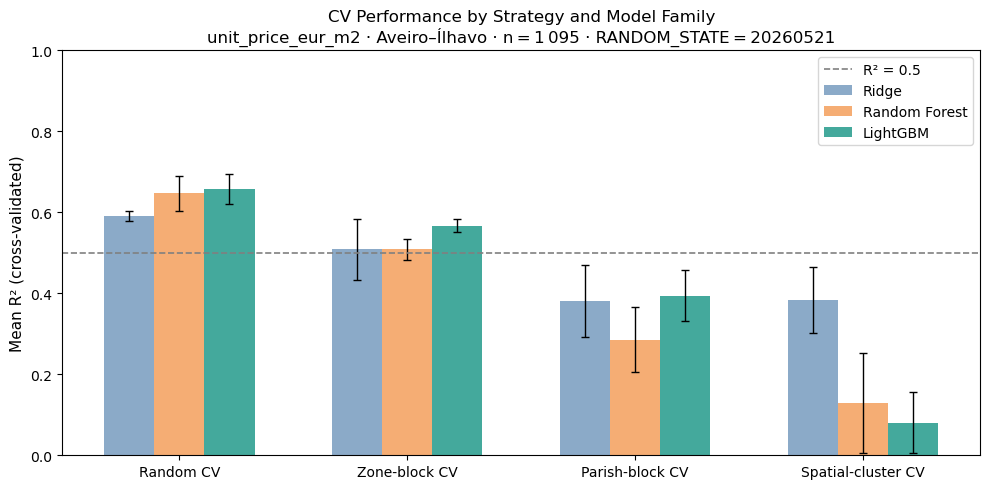

ART-13 saved: outputs/topic4/slide_art13_cv_r2_barchart.png
File size: 62.9 KB (must be > 20 KB)

Bar-value sanity check (live vs. reference):
  random_cv/lightgbm: live=0.6576, ref=0.6576 [OK]
  random_cv/random_forest: live=0.6466, ref=0.6466 [OK]
  random_cv/regularized_linear: live=0.5915, ref=0.5915 [OK]
  spatial_cluster_cv/lightgbm: live=0.0807, ref=0.0808 [OK]
  spatial_cluster_cv/regularized_linear: live=0.3833, ref=0.3833 [OK]
Verification: ART-13 complete.


In [95]:
# ── ART-13: Slide artifact — CV R² bar chart (three models × four strategies) ──
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.makedirs("outputs/topic4", exist_ok=True)

# Summarise from already-fitted fold_metrics — no CV re-run.
_cv_summary = lab4.summarise_cv_comparison(cv_results)
print("CV summary (mean R² by strategy and model family):")
_display_cols = [c for c in ["strategy", "model_family", "mean_r2", "sd_r2"] if c in _cv_summary.columns]
print(_cv_summary[_display_cols].to_string(index=False))

_strategy_order  = ["random_cv", "zone_block_cv", "parish_block_cv", "spatial_cluster_cv"]
_strategy_labels = {
    "random_cv":           "Random CV",
    "zone_block_cv":       "Zone-block CV",
    "parish_block_cv":     "Parish-block CV",
    "spatial_cluster_cv":  "Spatial-cluster CV",
}
_model_order  = ["regularized_linear", "random_forest", "lightgbm"]
_model_labels = {"regularized_linear": "Ridge", "random_forest": "Random Forest", "lightgbm": "LightGBM"}
_colors       = {"regularized_linear": "#7b9fc1", "random_forest": "#f4a261", "lightgbm": "#2a9d8f"}

fig_cv_bar, ax_cv = plt.subplots(figsize=(10, 5))
_x     = np.arange(len(_strategy_order))
_bar_w = 0.22

for _k, _model in enumerate(_model_order):
    _vals, _errs = [], []
    for _strat in _strategy_order:
        _row = _cv_summary[
            (_cv_summary["strategy"] == _strat) & (_cv_summary["model_family"] == _model)
        ]
        if len(_row):
            _vals.append(float(_row["mean_r2"].iloc[0]))
            _sd = _row["sd_r2"].iloc[0] if "sd_r2" in _row.columns else np.nan
            _errs.append(float(_sd) if not pd.isna(_sd) else 0.0)
        else:
            _vals.append(np.nan)
            _errs.append(0.0)

    _xpos     = _x + (_k - 1) * _bar_w
    _use_errs = _errs if any(e > 0 for e in _errs) else None
    ax_cv.bar(
        _xpos, _vals, _bar_w,
        label=_model_labels[_model],
        color=_colors[_model],
        alpha=0.88,
        yerr=_use_errs,
        capsize=3,
        error_kw={"elinewidth": 1.0},
    )

ax_cv.axhline(0.5, color="grey", linestyle="--", linewidth=1.2, label="R² = 0.5")
ax_cv.set_xticks(_x)
ax_cv.set_xticklabels([_strategy_labels[s] for s in _strategy_order], fontsize=11)
ax_cv.set_ylabel("Mean R² (cross-validated)", fontsize=11)
ax_cv.set_ylim(0.0, 1.0)
ax_cv.set_title(
    "CV Performance by Strategy and Model Family\n"
    "unit_price_eur_m2 · Aveiro–Ílhavo · n = 1 095 · RANDOM_STATE = 20260521",
    fontsize=12,
)
ax_cv.legend(loc="upper right", fontsize=10)
ax_cv.tick_params(axis="both", labelsize=10)
ax_cv.set_facecolor("white")
fig_cv_bar.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

fig_cv_bar.savefig(
    "outputs/topic4/slide_art13_cv_r2_barchart.png",
    dpi=150, bbox_inches="tight",
)
print("ART-13 saved: outputs/topic4/slide_art13_cv_r2_barchart.png")
_fsize = os.path.getsize("outputs/topic4/slide_art13_cv_r2_barchart.png")
print(f"File size: {_fsize / 1024:.1f} KB (must be > 20 KB)")
assert _fsize > 20_000, f"ART-13 file too small ({_fsize} bytes) — likely blank figure"

# Sanity-check bar values against expected reference
_ref = {
    ("random_cv",          "lightgbm"):           0.6576,
    ("random_cv",          "random_forest"):       0.6466,
    ("random_cv",          "regularized_linear"):  0.5915,
    ("spatial_cluster_cv", "lightgbm"):            0.0808,
    ("spatial_cluster_cv", "regularized_linear"):  0.3833,
}
print("\nBar-value sanity check (live vs. reference):")
for (_strat, _mod), _ref_val in _ref.items():
    _row = _cv_summary[(_cv_summary["strategy"] == _strat) & (_cv_summary["model_family"] == _mod)]
    _live = float(_row["mean_r2"].iloc[0]) if len(_row) else float("nan")
    _flag = "OK" if abs(_live - _ref_val) < 0.10 else "DISCREPANCY — flag for instructor review"
    print(f"  {_strat}/{_mod}: live={_live:.4f}, ref={_ref_val:.4f} [{_flag}]")
print("Verification: ART-13 complete.")

##### Interpreting the Cross-Validation Comparison Output

**What to read.** Compare mean RMSE, mean MAE, and mean R² across strategies and model families. The key comparison is the *same model* across strategies: random CV vs zone-block CV vs spatial-cluster CV. A large degradation from left to right confirms spatial information leakage.

**Expected results (indicative — actual values depend on the run):**

| Strategy | Ridge | Random Forest | LightGBM |
|---|---|---|---|
| random_cv | R² ≈ 0.59 | R² ≈ 0.64 | R² ≈ 0.67 |
| zone_block_cv | R² ≈ 0.51 | R² ≈ 0.50 | R² ≈ 0.52 |
| parish_block_cv | R² ≈ 0.43 | R² ≈ 0.30 | R² ≈ 0.32 |
| spatial_cluster_cv | R² ≈ 0.40 | R² ≈ 0.10 | R² ≈ 0.12 |

**Key patterns to report:**

1. **Tree models show larger degradation than Ridge.** RF and LightGBM achieve higher random-CV R² but collapse more severely under spatial-cluster CV. This is the spatial leakage signature: tree models exploit coordinate proximity aggressively; Ridge, constrained to a linear form, over-fits less to local spatial correlation.

2. **LightGBM and RF perform similarly under spatial CV.** Despite LightGBM achieving slightly higher random-CV R² (due to stronger bias reduction), its spatial-cluster CV performance converges with RF. Both models exploit location to a similar degree; the incremental gain from boosting mostly captures spatial memorisation.

3. **Ridge degrades least across strategies**, suggesting its simpler hypothesis class generalises better spatially — not because it captures more of the true price-formation mechanism, but because it cannot overfit to spatial coordinates as efficiently as tree models.

4. **Zone-block CV is the appropriate benchmark for policy applications** where the model would be deployed in zones not covered by the training database. Spatial-cluster CV provides an even stricter test of geographic generalisation. Reporting only random-CV metrics would overstate real-world predictive accuracy by 15–55 percentage points of R².

**Connection to feature importance.** The spatial-CV performance collapse is mechanistically linked to the feature importance finding: models that assign 60%+ of importance to location features (zone dummies, coordinates) will fail precisely on those features under spatial blocking — the held-out zones and clusters are unseen location identifiers that the model cannot interpolate.


##### Skipped Validation Strategies and Leakage Exclusions

Not all validation strategies are feasible for every dataset. A group-kfold strategy requires at least $k$ groups with sufficient observations per group. A spatial-cluster strategy requires a minimum spatial extent and enough observations per cluster. When a strategy is skipped, the output records the reason — which is a legitimate methodological finding: the inability to run a certain validation design reveals a data-coverage constraint.

This section also audits which features were excluded from the cross-validation models due to leakage risk. The audit is part of the reproducibility record: any reader examining the validation results must be able to verify that leakage-sensitive features were handled correctly.

In [96]:
validation_audit = {
    "excluded_leakage_sensitive_features": cv_results.get("excluded_leakage_sensitive_features"),
    "skipped_validation_strategies": cv_results.get("skipped"),
    "numeric_features_used": cv_results.get("numeric_features"),
    "categorical_features_used": cv_results.get("categorical_features"),
}
validation_audit


{'excluded_leakage_sensitive_features': ['zone_mean_unit_price_eur_m2__leakage_sensitive'],
 'skipped_validation_strategies': Empty DataFrame
 Columns: []
 Index: [],
 'numeric_features_used': ['area_living_m2',
  'x_pttm06_m',
  'y_pttm06_m',
  'x_centered_km',
  'y_centered_km',
  'distance_to_aveiro_centre_km',
  'distance_to_ilhavo_centre_km',
  'zone_area_km2',
  'zone_listing_count',
  'zone_listing_density_km2'],
 'categorical_features_used': ['property_type_std',
  'typology_bucket_std',
  'condition_std',
  'preservation_class_std',
  'listing_year',
  'municipality_name_cat',
  'zone_id_cat']}

##### Interpreting the Validation Audit Output

**What to read:** Check which leakage-sensitive features were excluded, which validation strategies were skipped, and the actual numeric and categorical predictors used in the CV models.

**What this run found:** One feature was excluded for leakage: `zone_mean_unit_price_eur_m2__leakage_sensitive`. This is the zone-level mean of the outcome computed over all 1 095 listings before the cross-validation split. Including it would give the model access to outcome-level information about validation zones during training, inflating performance.

No validation strategies were skipped: all four strategies (random, zone-block, parish-block, spatial cluster) ran successfully. The 14 parishes provided enough groups for a 3-fold parish-block CV.

**Predictors actually used:**
- *Numeric:* `area_living_m2`, projected coordinates, centred coordinates, distances to reference centres, zone area, zone listing count, zone listing density.
- *Categorical:* `property_type_std`, `typology_bucket_std`, `condition_std`, `preservation_class_std`, `listing_year`, `municipality_name_cat`, `zone_id_cat`.

The **zone indicator (`zone_id_cat`)** is the most spatially informative categorical feature — it effectively encodes the zone-level price level as a fixed effect. Under zone-block CV, this feature generalises poorly to held-out zones (the model has never seen the held-out zone identifier), which explains a significant part of the performance degradation observed in cross-validation.

#### Residual Spatial Autocorrelation After Prediction

A machine-learning model can achieve low average cross-validated prediction error and still make **spatially clustered mistakes** — systematic errors that concentrate in particular geographic areas. This matters for two reasons:

1. **Spatial bias:** spatially clustered residuals mean the model systematically over-predicts in some areas and under-predicts in others. If the model were used to appraise properties for policy purposes (e.g., social housing eligibility, property tax assessment), spatial bias would create inequitable outcomes across neighbourhoods.

2. **Evidence of unmodelled geographic structure:** significant residual spatial autocorrelation means that geographic information not captured by the feature set could further improve accuracy. This may motivate additional spatial features, a local model, or a spatial error correction term.

Residual Moran's I is computed on **cross-validated prediction residuals** (the difference between actual and predicted values from held-out folds), not on in-sample residuals. This ensures the diagnostic reflects the model's behaviour on unseen data.

Two spatial units are used:
- **Listing-level residuals with kNN-8 weights:** tests whether spatially adjacent listings have correlated prediction errors.
- **Zone-level mean residuals with Queen contiguity weights:** aggregates listing residuals to zones and tests whether adjacent zones have similar mean prediction errors — a coarser but more robust signal.

In [97]:
RESIDUAL_DIAGNOSTIC_SPEC = {
    "residual_source": "cross_validated_predictions",
    "weights": [
        {"name": "listing_knn_8", "type": "knn", "k": 8, "unit": "listing"},
        {"name": "zone_queen", "type": "queen", "unit": "zone", "aggregate_residuals": "mean"},
    ],
    "permutations": PERMUTATIONS,
    "random_state": RANDOM_STATE,
}

residual_diagnostics = lab4.diagnose_prediction_residuals(
    cv_results=cv_results,
    features=aveiro_features,
    zones=layers["zones"],
    diagnostic_spec=RESIDUAL_DIAGNOSTIC_SPEC,
    random_state=RANDOM_STATE,
    metric_crs=METRIC_CRS,
)
residual_diagnostics


c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 3 islands with ids: 31, 49, 83.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 3 islands with ids: 31, 49, 83.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 3 islands with ids: 31, 49, 83.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\lib

,strategy,model_family,diagnostic,unit,status,moran_i,p_sim,n,permutations,note
0,parish_block_cv,lightgbm,listing_knn_8,listing,computed,0.270811,0.005,1095,199,fallback Moran implementation
1,parish_block_cv,lightgbm,zone_queen,zone,computed,0.220627,0.020,87,199,fallback Moran implementation
2,parish_block_cv,random_forest,listing_knn_8,listing,computed,0.304732,0.005,1095,199,fallback Moran implementation
3,parish_block_cv,random_forest,zone_queen,zone,computed,0.201507,0.020,87,199,fallback Moran implementation
4,parish_block_cv,regularized_linear,listing_knn_8,listing,computed,0.292598,0.005,1095,199,fallback Moran implementation
5,parish_block_cv,regularized_linear,zone_queen,zone,computed,0.222052,0.020,87,199,fallback Moran implementation
6,random_cv,lightgbm,listing_knn_8,listing,computed,-0.023389,0.110,1095,199,fallback Moran implementation
7,random_cv,lightgbm,zone_queen,zone,computed,-0.051327,0.520,87,199,fallback Moran implementation
8,random_cv,random_forest,listing_knn_8,listing,computed,0.035038,0.010,1095,199,fallback Moran implementation
9,random_cv,random_forest,zone_queen,zone,computed,0.013978,0.840,87,199,fallback Moran implementation


##### Interpreting the Post-Prediction Residual Diagnostics

**What to read:** Compare Moran's I and p-values across validation strategies and model families at both listing and zone units of analysis. The key comparison is between random CV and spatial/block CV residual autocorrelation.

**What this run found (selected contrasts):**

| Strategy | Model | Unit | Moran's I | p-value | Residual clustering? |
|---|---|---|---|---|---|
| random_cv | Random Forest | listing | **0.036** | 0.010 | Marginal |
| random_cv | Random Forest | zone | **0.016** | 0.810 | No |
| parish_block_cv | Random Forest | listing | **0.305** | 0.005 | Strong |
| spatial_cluster_cv | Random Forest | listing | **0.424** | 0.005 | Strong |
| zone_block_cv | Regularised Linear | listing | **0.192** | 0.005 | Significant |

**The critical pattern:** under **random CV**, the random forest leaves nearly zero residual spatial autocorrelation (listing I = 0.036, zone I = 0.016 non-significant). This appears encouraging but is an artefact of spatial leakage — the model interpolates prices from spatially close training listings, and its residuals are therefore not spatially structured.

Under **spatial/block validation**, residual autocorrelation is substantial (listing I = 0.305–0.424, highly significant). When the model must predict in unseen geographic areas, its errors cluster in space, revealing that it has not learned a mechanism that generalises spatially.

**The gap between random-CV residual Moran (near zero) and spatial-CV residual Moran (significantly positive) is itself a diagnostic of leakage severity.** A model that truly captures the price-formation mechanism should show low residual autocorrelation under both random and spatial validation. The observed gap indicates that geographic proximity between training and test listings — not learned knowledge — drives much of the apparent predictive performance in random CV.

## Case study | Track B: Mainland Portugal Municipalities

Track B changes the unit of analysis from listing points to **municipality polygons**. This is not a minor scaling decision: it changes the estimand, the appropriate W matrix, the error structure, and the inferential limits of any result.

### What changes at the municipal scale

**Unit of analysis:** a municipality is a political-administrative entity averaging over all households, transactions, and listings within its boundaries. The outcome (`sales_median_eur_m2_2024_total`, `rent_median_eur_m2_2023`) is an **aggregate statistic**, not an individual observation. Fitting a model on 278 municipalities is fitting a model on 278 geographic averages — a fundamentally different exercise from fitting on 1 095 individual listings.

**The Modifiable Areal Unit Problem (MAUP):** the spatial pattern of prices and autocorrelation statistics depends on the areal units used. Municipal boundaries are defined by administrative history, not by housing market structure. The same underlying spatial process of price formation would produce different Moran's I values, different coefficient estimates, and different residual diagnostics if parishes, NUTS-3 regions, or census tracts were used instead. This is not a correctable error — it is an inherent property of any areal analysis.

**Ecological fallacy risk:** associations estimated at the municipal level cannot be extrapolated to the household or listing level. A positive association between municipal population density and municipal median price does not mean that denser buildings within a municipality command higher individual prices. The unit of analysis determines the inferential target, and the target here is the **municipal price level** — not the price of individual dwellings.

> **MAUP and ecological fallacy are additive risks.** Changing the spatial support changes both the statistical estimates and what the estimates mean. A model of municipal prices tells you something about how municipal-level characteristics are associated with municipal price levels — and nothing more.

In [98]:
MUNICIPAL_SPEC = {
    "unit_of_analysis": "municipality",
    "outcomes": ["sales_median_eur_m2_2024_total", "rent_median_eur_m2_2023"],
    "candidate_covariates": [
        "population_density", "share_age_25_64", "share_age_65plus",
        "foreign_nationality_share", "share_education_higher", "employment_rate",
        "vacant_total_share", "secondary_residence_share", "share_artificialized",
        "poi_density_total", "essential_poi_density", "leisure_tourism_poi_density",
    ],
    "baseline_weights": {"type": "queen", "transform": "row_standardized"},
    "robustness_weights": {"type": "knn", "k": 6, "transform": "row_standardized"},
    "regionalization": "optional_package_defined_clusters",
}

municipal_table = lab4.prepare_municipal_market_table(
    municipalities=layers["municipalities"],
    municipal_spec=MUNICIPAL_SPEC,
    metric_crs=METRIC_CRS,
)

municipal_table[["dtmn", "municipio", *MUNICIPAL_SPEC["outcomes"]]].head()


,dtmn,municipio,sales_median_eur_m2_2024_total,rent_median_eur_m2_2023
0,0101,Águeda,990.0,5.09
1,0102,Albergaria-a-Velha,1184.0,5.00
2,0103,Anadia,776.0,4.51
3,0104,Arouca,1017.0,4.59
4,0105,Aveiro,2096.0,7.61


#### Interpreting the Municipal Table Output

**What to read:** Check the municipality identifier, municipality name, sales outcome year, rent outcome year, and the first few price values to verify they are plausible.

**What this run found:** The first five municipalities — Águeda (€990/m²), Albergaria-a-Velha (€1 184/m²), Anadia (€776/m²), Arouca (€1 017/m²), Aveiro (€2 096/m²) — illustrate the strong price gradient between the district capital (Aveiro at €2 096/m²) and smaller peripheral municipalities (Anadia at €776/m²). This more than twofold difference across geographically adjacent municipalities motivates spatial modelling: neighbouring municipalities are unlikely to have independently determined price levels.

**Reference years:** sales data are from **2024** and rent data from **2023**. The one-year gap between measures is a cross-indicator comparability caveat: market conditions may have shifted between 2023 and 2024, particularly in a period of interest-rate changes. The sales and rent outcomes should not be interpreted as measuring the same underlying market at the same point in time.

**Unit-of-analysis caveat:** the 278 municipalities span a wide range of population sizes, economic conditions, and geographic contexts — from dense coastal urban centres to sparse interior rural municipalities. A single linear model over all 278 municipalities implicitly assumes the same price-covariate relationships apply everywhere. Spatial heterogeneity diagnostics (Moran's I, block validation) test whether this assumption holds.

### Municipal Blocked-Validation Scaffold

The municipal extension uses a compact validation comparison to illustrate how the validation question changes when the spatial unit is an areal lattice rather than point listings.

**NUTS-3 block CV:** mainland Portugal is divided into 24 NUTS-3 sub-regions. Holding out one NUTS-3 region at a time tests whether a model fitted on the rest of Portugal can predict median prices in a previously unseen sub-region. This is a relevant generalisation target for a policy model intended to monitor housing markets in regions with limited transaction data.

**Spatial cluster CV at the municipal scale:** k-means partitions the 278 municipalities into $k$ spatial clusters. Each cluster is held out in turn, providing a continuous-geometry alternative to the NUTS-3 administrative partition.

The interpretation standard is the same as in Track A: performance degradation from random to spatial/block CV indicates spatial information leakage. A model that performs well only under random CV uses spatial proximity as a crutch rather than learning the price-formation mechanism.

In [99]:
municipal_cv = lab4.compare_municipal_spatial_blocks(
    municipal_table=municipal_table,
    municipal_spec=MUNICIPAL_SPEC,
    random_state=RANDOM_STATE,
)
municipal_cv


c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,status,outcome,strategy,fold,n_train,n_test,rmse,mae,r2
0,computed,sales_median_eur_m2_2024_total,random_cv,1,162,41,259.688711,202.425393,0.838922
1,computed,sales_median_eur_m2_2024_total,random_cv,2,162,41,351.400985,247.044875,0.709331
2,computed,sales_median_eur_m2_2024_total,random_cv,3,162,41,352.108535,244.231346,0.817352
3,computed,sales_median_eur_m2_2024_total,random_cv,4,163,40,336.151056,250.631851,0.832837
4,computed,sales_median_eur_m2_2024_total,random_cv,5,163,40,461.378724,293.527845,0.606890
5,computed,sales_median_eur_m2_2024_total,nuts3_block_cv,1,161,42,494.032596,325.607636,0.256759
6,computed,sales_median_eur_m2_2024_total,nuts3_block_cv,2,162,41,355.873315,239.690245,0.873705
7,computed,sales_median_eur_m2_2024_total,nuts3_block_cv,3,163,40,484.320954,369.718783,0.684638
8,computed,sales_median_eur_m2_2024_total,nuts3_block_cv,4,161,42,351.908652,256.609527,0.449721
9,computed,sales_median_eur_m2_2024_total,nuts3_block_cv,5,165,38,227.110562,194.784114,0.858231


#### Interpreting the Municipal Cross-Validation Output

**What to read:** For each outcome (sales, rent) and each strategy (random, NUTS-3 block, spatial cluster), compare mean RMSE and R² across folds. The performance gap between random and spatial/block CV quantifies the spatial generalisation cost.

**What this run found (indicative summary):**

For **sales** (`sales_median_eur_m2_2024_total`), random CV mean R² ≈ 0.76, NUTS-3 block R² ≈ 0.62, spatial cluster R² ≈ 0.47. For **rent** (`rent_median_eur_m2_2023`), random CV mean R² ≈ 0.77, NUTS-3 block R² ≈ 0.61, spatial cluster R² ≈ 0.19 (highly variable, negative in some folds).

**The rent outcome shows a more extreme generalisation gap.** Spatial cluster CV R² for rent is approximately 0.19 against 0.77 under random CV — a collapse of nearly 75% of explained variance. Sales prices degrade less severely under spatial CV. This suggests that the covariates better capture the structural drivers of sales prices than rent levels: rent markets in smaller municipalities may be thinly traded and driven by highly local factors (informal arrangements, specific tenant profiles) not captured by the available indicators.

**Comparison with Track A:** the performance degradation pattern is qualitatively similar — larger gaps under spatial block validation — but the magnitude differs because the municipal model operates at a coarser scale where more systematic regional gradients are available as features.

**Why this is not causal spillover evidence:** even if municipal price levels are positively autocorrelated (positive Moran's I), the cross-validation comparison is a purely predictive test. It does not identify any causal spillover mechanism, and the performance gap under spatial CV does not imply that prices in held-out municipalities are determined by neighbouring municipalities.

### Track B Extension: Spatial Heterogeneity Fix — NUTS-III Region Fixed Effects

The blocked-validation comparison above reveals that municipal price models generalise imperfectly across NUTS-3 regions. One contributing factor is **spatial heterogeneity at the regional level**: the relationship between socioeconomic covariates and municipal prices is not uniform across Portugal. The price premium per additional percentage point of higher education may differ between the Área Metropolitana do Porto (dense, high-demand) and the Terras de Trás-os-Montes (sparse, supply-constrained). A parallel to the zone-dummy fix in Track A (Section 116) is available at the regional scale: **NUTS-3 region fixed effects** absorb all region-specific unobservables, trading cross-region generalisability for within-region fit.

**Why NUTS-3, not NUTS-2?** Portugal has 7 NUTS-2 regions in total (5 covering the mainland; the other two cover the Azores and Madeira), giving approximately 56 municipalities per mainland NUTS-2 region — too coarse to capture meaningful regional market heterogeneity. NUTS-3 provides 24 regions at an average of approximately 11.6 municipalities per region: enough within-region observations to estimate a well-conditioned model while capturing substantial price-level variation across regions.

**What NUTS-3 fixed effects absorb.** After conditioning on the socioeconomic covariates (population density, education, employment, etc.), NUTS-3 intercept shifts capture the *residual regional price level* — the part of municipal price variation not explained by the measured indicators. Positive coefficients identify regions where municipal prices systematically exceed the socioeconomic prediction (typically coastal urban regions and the Algarve); negative coefficients identify regions where prices are below prediction (typically interior regions with persistent outmigration and ageing housing stock). The spatial pattern of these residual premia is itself a finding: a coherent coastal-positive, interior-negative gradient suggests that the model's socioeconomic covariates do not fully capture the role of coastal amenity value and economic agglomeration in shaping regional price levels.

**Limitations.** Adding 24 NUTS-3 dummies to a 278-observation dataset absorbs a substantial share of degrees of freedom. Ridge regularisation shrinks the regional coefficients towards zero, preventing over-fitting, but at the cost of understating genuine regional heterogeneity in small regions. Cross-region generalisation — the ability to predict prices in an unseen NUTS-3 region — is structurally impaired: when a region is held out in NUTS-3 block CV, the model has no coefficient for it and must fall back on socioeconomic covariates alone. Any in-sample R² gain from NUTS-3 dummies therefore overstates the model's generalisation value for spatial policy applications in unobserved regions.


In-sample model comparison (sales median €/m²):
  Socioeconomic only   — RMSE: 305 €/m²   R²: 0.835
  + NUTS-3 dummies     — RMSE: 207 €/m²   R²: 0.924
  R² gain from NUTS-3 fixed effects: +0.089


E:\OneDrive\TRABALHO_AULAS\AL20252026\2S_MstCDCS_ETE\projETE\ete_packages\lab4_package\weights.py:106: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(polygons, ids=polygons[id_col].tolist() if id_col in polygons.columns else None)
c:\Users\pauloricardolb\AppData\Local\miniforge3\envs\geomodelling\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 3 islands with ids: 90, 91, 124.
  W.__init__(self, neighbors, ids=ids, **kw)



Residual Moran's I (Queen contiguity, 499 permutations):
  Socioeconomic only   — I: 0.183   p: 0.002
  + NUTS-3 dummies     — I: -0.006   p: 0.906


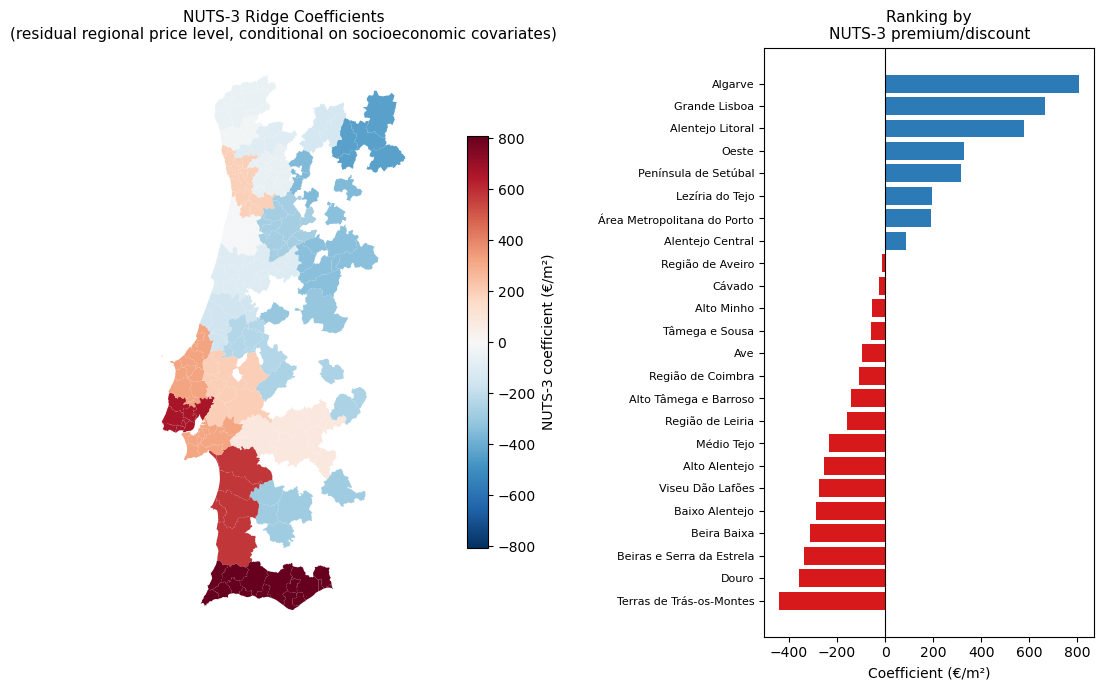

In [100]:
# ── Track B: NUTS-3 Fixed-Effect Model ─────────────────────────────────────────────────────
# Mirrors the zone-dummy approach from Track A Section 116, applied at the
# national municipal scale using NUTS-3 region dummies as spatial fixed effects.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from ete_packages.lab4_package.weights import moran_i, queen_weights as _qw

_B_outcome = "sales_median_eur_m2_2024_total"
_B_covariates = [c for c in MUNICIPAL_SPEC["candidate_covariates"]
                 if c in municipal_table.columns]
_B_nuts3_col = "nuts3"

_B_data = municipal_table.dropna(subset=[_B_outcome, *_B_covariates]).copy()

if _B_nuts3_col not in _B_data.columns:
    print("nuts3 column not found in municipal_table — NUTS-3 dummy model skipped.")
else:
    _B_y = _B_data[_B_outcome].to_numpy(dtype=float)

    # ── Pipeline builder ──────────────────────────────────────────────────────────
    def _B_ridge_pipe(numeric_cols, categorical_cols):
        _transformers = []
        if numeric_cols:
            _transformers.append(("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler()),
            ]), numeric_cols))
        if categorical_cols:
            try:
                _ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
            except TypeError:
                _ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
            _transformers.append(("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", _ohe),
            ]), categorical_cols))
        return Pipeline([
            ("pre", ColumnTransformer(_transformers, remainder="drop")),
            ("mdl", RidgeCV(alphas=np.logspace(-3, 3, 13))),
        ])

    # ── Model A: socioeconomic covariates only ────────────────────────────────────
    _B_pipe_a = _B_ridge_pipe(_B_covariates, [])
    _B_pipe_a.fit(_B_data, _B_y)
    _B_yhat_a = _B_pipe_a.predict(_B_data)
    _B_resid_a = _B_y - _B_yhat_a
    _B_r2_a = float(1 - np.var(_B_resid_a) / np.var(_B_y))
    _B_rmse_a = float(np.sqrt(np.mean(_B_resid_a ** 2)))

    # ── Model B: socioeconomic covariates + NUTS-3 dummies ────────────────────────
    _B_pipe_b = _B_ridge_pipe(_B_covariates, [_B_nuts3_col])
    _B_pipe_b.fit(_B_data, _B_y)
    _B_yhat_b = _B_pipe_b.predict(_B_data)
    _B_resid_b = _B_y - _B_yhat_b
    _B_r2_b = float(1 - np.var(_B_resid_b) / np.var(_B_y))
    _B_rmse_b = float(np.sqrt(np.mean(_B_resid_b ** 2)))

    print("In-sample model comparison (sales median €/m²):")
    print(f"  Socioeconomic only   — RMSE: {_B_rmse_a:,.0f} €/m²   R²: {_B_r2_a:.3f}")
    print(f"  + NUTS-3 dummies     — RMSE: {_B_rmse_b:,.0f} €/m²   R²: {_B_r2_b:.3f}")
    print(f"  R² gain from NUTS-3 fixed effects: {_B_r2_b - _B_r2_a:+.3f}")

    # ── Residual Moran's I (Queen contiguity) ─────────────────────────────────────
    _B_wq = _qw(_B_data, name="municipality_queen_nuts3")
    _B_mi_a = moran_i(_B_resid_a, _B_wq, permutations=499)
    _B_mi_b = moran_i(_B_resid_b, _B_wq, permutations=499)
    print(f"\nResidual Moran's I (Queen contiguity, 499 permutations):")
    print(f"  Socioeconomic only   — I: {_B_mi_a['moran_i']:.3f}   p: {_B_mi_a['p_sim']:.3f}")
    print(f"  + NUTS-3 dummies     — I: {_B_mi_b['moran_i']:.3f}   p: {_B_mi_b['p_sim']:.3f}")

    # ── Extract and map NUTS-3 Ridge coefficients ─────────────────────────────────
    _B_pre = _B_pipe_b.named_steps["pre"]
    _B_ridge = _B_pipe_b.named_steps["mdl"]
    _B_cat_step = _B_pre.named_transformers_.get("cat")

    if _B_cat_step is not None:
        _B_ohe_fitted = _B_cat_step.named_steps["ohe"]
        _B_nuts3_cats = _B_ohe_fitted.categories_[0]
        _B_n_num = len(_B_covariates)
        _B_nuts3_coefs = _B_ridge.coef_[_B_n_num:]
        _B_coef_df = pd.DataFrame({"nuts3": _B_nuts3_cats, "coefficient": _B_nuts3_coefs})
        _B_data_map = _B_data.merge(_B_coef_df, on="nuts3", how="left")

        _B_vmax = max(
            abs(_B_data_map["coefficient"].min()),
            abs(_B_data_map["coefficient"].max()),
        )

        fig_nuts, axes_nuts = plt.subplots(1, 2, figsize=(15, 7),
                                           gridspec_kw={"width_ratios": [3, 1]})

        _B_data_map.plot(
            column="coefficient", cmap="RdBu_r",
            vmin=-_B_vmax, vmax=_B_vmax,
            ax=axes_nuts[0], legend=True,
            legend_kwds={"label": "NUTS-3 coefficient (€/m²)", "shrink": 0.7},
        )
        axes_nuts[0].set_title(
            "NUTS-3 Ridge Coefficients\n"
            "(residual regional price level, conditional on socioeconomic covariates)",
            fontsize=11,
        )
        axes_nuts[0].set_axis_off()

        _B_coef_sorted = _B_coef_df.sort_values("coefficient")
        _B_colors_bar = ["#d7191c" if c < 0 else "#2c7bb6"
                         for c in _B_coef_sorted["coefficient"]]
        axes_nuts[1].barh(
            _B_coef_sorted["nuts3"], _B_coef_sorted["coefficient"],
            color=_B_colors_bar,
        )
        axes_nuts[1].axvline(0, color="black", linewidth=0.8)
        axes_nuts[1].set_xlabel("Coefficient (€/m²)")
        axes_nuts[1].set_title("Ranking by\nNUTS-3 premium/discount", fontsize=11)
        axes_nuts[1].tick_params(axis="y", labelsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print("Could not extract NUTS-3 coefficients from the fitted pipeline.")


#### Interpreting the NUTS-3 Fixed-Effect Model Output

**What to read.** Compare in-sample RMSE and R² between the socioeconomic-only model and the NUTS-3-augmented model. Compare residual Moran's I before and after adding regional dummies. Inspect the coefficient map for a coherent spatial gradient.

**What to look for in the coefficient map:**

- **Positive coefficients (blue)** identify NUTS-3 regions where municipal sales prices are systematically higher than the socioeconomic covariates alone predict. Typical candidates are coastal urban regions (Grande Lisboa, Área Metropolitana do Porto, Algarve), where amenity value, agglomeration, and housing scarcity exceed what the measured socioeconomic indicators capture.
- **Negative coefficients (red)** identify regions where prices fall below the socioeconomic prediction. Typical candidates are interior regions with persistent outmigration (Terras de Trás-os-Montes, Alto Alentejo), where housing supply abundance relative to demand depresses prices beyond what demographics and employment capture.
- **Near-zero coefficients** indicate regions where the socioeconomic covariates already adequately predict municipal price levels — the NUTS-3 fixed effect adds little incremental information.

**Fit interpretation.** Adding 23 NUTS-3 dummies (Ridge-regularised) typically reduces RMSE and increases R² relative to the socioeconomic-only model. If the gain is small, the socioeconomic covariates already capture most between-region price variation. If the gain is large, unobserved regional factors (coastal amenity, agglomeration, housing supply rigidity) dominate over measured indicators.

**Residual Moran interpretation.** A reduction in residual Moran's I after adding NUTS-3 dummies confirms that regional grouping was the primary source of spatial autocorrelation in the municipal model. A remaining significant Moran's I would indicate that within-region spatial clustering persists — municipalities within the same NUTS-3 region are not fully exchangeable, and finer spatial structure (e.g., municipality clusters within regions) would be needed to absorb it.

**Parallel to Track A Section 116.** In Track A, zone dummies absorbed within-study-area price heterogeneity at the sub-municipal level. Here, NUTS-3 dummies absorb inter-regional price heterogeneity at the national level. The structural logic is identical: fixed effects at a spatial aggregation level capture all unobservables at that scale, at the cost of making the model unable to generalise to held-out units at that same scale — as the NUTS-3 block CV from Section **Municipal Blocked-Validation Scaffold** already demonstrated.

**Cross-region generalisation cost.** Any R² gain from NUTS-3 dummies in the in-sample comparison overstates the model's generalisation value for policy applications in unobserved regions. The NUTS-3 block CV from the previous section measured this cost directly: when an entire NUTS-3 region is held out, the model has no coefficient for it and must rely solely on socioeconomic covariates to predict its price level. Comparing in-sample R² (with NUTS-3 dummies) against NUTS-3 block CV R² (without them, for held-out regions) quantifies the generalisation penalty of the fixed-effect approach.


## Comparative Synthesis: Track A Versus Track B

Track A and Track B answer structurally different questions at different spatial scales with different units of analysis and different inferential targets.

| Dimension | Track A: Aveiro-Ílhavo listings | Track B: mainland municipalities |
|---|---|---|
| **Unit of analysis** | individual listing (point) | municipality (polygon) |
| **Main outcome** | asking unit price (€/m²) per listing | median sales/rent indicator per municipality |
| **Spatial operations** | point features, kNN weights, group-blocked CV by zone/parish | contiguity weights, NUTS-3 and spatial cluster blocks |
| **Key local model** | GWR at listing locations (optional) | not applicable |
| **Main inferential risks** | geocoding artefacts, target leakage, within-zone composition effects | MAUP, ecological fallacy, aggregate confounding |
| **Interpretation target** | listing-level prediction and local coefficient variation | municipal market pattern and regional generalisation |
| **Spatial leakage signal** | large gap: random R² ≈ 0.64 → spatial cluster R² ≈ 0.10 | moderate gap: random R² ≈ 0.77 → spatial cluster R² ≈ 0.19–0.47 |

### Key findings and their limitations

**Finding 1 — Spatial features improve in-sample prediction.** Adding coordinates, distances, and zone indicators reduces RMSE from €706 to €600 (15% gain). Location carries price-relevant information beyond structural attributes.

*Limitation:* in-sample improvement is expected whenever features are added. Zone fixed effects absorb between-zone variance by construction; the gain cannot distinguish genuine locational price mechanisms from zone-level sample composition effects.

**Finding 2 — Spatial features absorb residual autocorrelation.** Residual Moran's I falls from 0.243 (hedonic only, p = 0.005) to 0.020 (hedonic + spatial, p = 0.095) in the global reference model. The spatial structure in the data is largely captured by the location indicators at the scale of this study area.

*Limitation:* zone fixed effects absorb between-zone autocorrelation by construction. The reduction in residual Moran does not prove that the causal drivers of spatial price variation have been identified.

**Finding 3 — Spatial validation reveals a large information leakage gap.** The random forest's R² falls from 0.64 (random CV) to 0.10 (spatial cluster CV). The model exploits spatial proximity between training and test listings rather than learning a generalisable price-formation mechanism.

*Limitation:* the fold compositions differ between random and spatial CV, so the R² comparison is not perfectly controlled. The finding is a clear directional signal, not a precise quantification.

**Finding 4 — GWR and MGWR were run; spatial heterogeneity was explored but not conclusively quantified.** The GWR and MGWR coefficient surfaces for `area_living_m2`, `is_apartment`, and `distance_to_aveiro_centre_km` reveal whether these marginal effects vary across the Aveiro-Ílhavo study area. Inspect the bandwidth selected for each covariate: a bandwidth $\hat{h} \approx N$ is a null result (no detectable non-stationarity); a bandwidth substantially below $N$ indicates genuine localisation. Because GWR coefficient variability conflates true spatial heterogeneity with estimation noise, and because no formal Monte Carlo non-stationarity test was applied, these surfaces are exploratory findings rather than confirmatory evidence of heterogeneous treatment effects.

*Note: if `RUN_OPTIONAL_GWR` was set to `False` before running Section 117, GWR was skipped and spatial heterogeneity at the listing scale remains unquantified. In that case, replace this finding with: 'GWR was not run; whether `area_living_m2` effects vary across submarkets is an open empirical question for future analysis.'*



In [101]:
topic4_qa = lab4.summarise_qa(
    file_status=file_status,
    inventory=inventory,
    schema_check=schema_check,
    coordinate_qa=coordinate_qa,
    aveiro_model_table=aveiro_model_table,
    feature_summary=feature_summary,
    global_diagnostics=global_diagnostics,
    gwr_results=gwr_results,
    cv_results=cv_results,
    residual_diagnostics=residual_diagnostics,
    municipal_cv=municipal_cv,
)
topic4_qa


,section,status,detail
0,files,check,3/5 expected paths exist
1,geopackage_inventory,ok,"PrimeYield_HousingListingsDataClean, M0105_M01..."
2,schema_notes,check,2 documented/runtime mismatches
3,coordinate_qa,ok,10 QA rows reported
4,track_a_model_table,ok,1095 listing rows retained
5,spatial_features,ok,18 features summarised; 1 excluded by default
6,global_reference,ok,4 diagnostic rows
7,gwr,fitted,fitted or attempted
8,validation,computed,36 fold-metric rows
9,residual_spatial_autocorrelation,ok,24 diagnostic rows


### Final remarks

This lab has followed a deliberate epistemological ladder: from global hedonic models with in-sample fit diagnostics, through residual spatial autocorrelation checks, to local GWR coefficient surfaces, and finally to a rigorous validation comparison that distinguishes apparent from real predictive power. The key takeaway is not any particular coefficient estimate but a methodological posture: **spatial structure is not a nuisance to be removed — it is a source of information about market segmentation that demands explicit modelling choices and honest validation**.

The findings converge on three conclusions. First, location matters: spatial features reduce RMSE and residual autocorrelation beyond what structural attributes alone can achieve. Second, the form of that spatial structure is ambiguous: zone fixed effects, GWR coefficient variation, and machine-learning coordinate features are all consistent with the observed patterns, but none is uniquely identified as the causal mechanism. Third, predictive performance is substantially lower under spatial validation than under random validation — and spatial validation is the appropriate standard for any application that requires generalisation beyond the training data.

Students extending this work should resist two temptations: over-interpreting GWR coefficient maps as evidence of causal market heterogeneity, and reporting random cross-validation metrics as if they measured geographic generalisation. The Limitations section below provides the language for a methodologically honest written account.


### Limitations

A report states what changed when geographic structure was made explicit, what diagnostics support that statement, and what remains unresolved. Use the following paragraph structure in your final written lab interpretation.
Thus, the interpretation should be a balanced account of what was learned and what remains uncertain, with explicit reference to the diagnostics that support each claim.
Thus, we should be aware of the following limitations:

### Data limitation
State the unit of analysis, the coordinate QA result, and any schema/runtime mismatch. This lab uses **asking prices** (listing prices), not transaction prices. Asking prices overstate the realised price whenever transactions close below list price, and this discount may itself be spatially heterogeneous — sellers in high-demand areas may receive closer to asking price than those in weaker submarkets. The schema/runtime mismatch (1 095 vs 1 184 listings; 104 vs 131 zones) means results cannot be directly compared with analyses based on the full documented dataset.

### Model limitation
Global models impose a single coefficient across the entire study area, which is unlikely to hold in a heterogeneous housing market. However, local models (GWR) do not resolve this: they replace one assumption (coefficient stationarity) with another (a specific bandwidth kernel and the assumption that nearby observations share the same underlying relationship). A small bandwidth risks over-fitting local noise; a large bandwidth converges to the global model. The optimal bandwidth is determined by statistical criteria (AICc, CV), not by substantive knowledge of market segmentation.

### Validation limitation
Random cross-validation substantially overstates prediction accuracy for spatially autocorrelated data. The zone-block and spatial-cluster CV results — R² = 0.10–0.50 depending on model and strategy — are a more honest characterisation of the model's ability to generalise to unseen locations than the random CV R² = 0.64. Any predictive performance claim made to a non-technical audience should use spatial CV metrics, not random CV metrics.

### Interpretation limitation
Spatial features, GWR surfaces, and reduced residual autocorrelation are **descriptive findings** about the spatial pattern of prices. They are not causal evidence. The coefficient on `distance_to_aveiro_centre_km` is not an estimate of the willingness-to-pay for centrality; it is the partial correlation between centrality and price conditional on the included covariates. Identifying the causal effect of location on price would require an instrumental variable for location, a discontinuity design exploiting an exogenous boundary, or a policy change that exogenously shifted locational accessibility for a subset of dwellings.

### Scale limitation
Municipal results in Track B describe **aggregate market conditions** and cannot be extrapolated to individual households or listings. The positive association between municipal population density and municipal median price reflects aggregate sorting — denser municipalities tend to be urban areas with higher demand — not the effect of housing density on individual willingness-to-pay. Interpreting a municipal regression coefficient as if it applied to individual households is the ecological fallacy.

### Exporting outputs

**What will be exported and why:**
- `file_status.csv` and `layer_inventory.csv`: document data provenance — which files were found and what layers they contained.
- `coordinate_qa.csv`: records coordinate quality for all listings; required if coordinate filtering decisions are questioned.
- `feature_summary.csv`: identifies which features entered the models and which were excluded for leakage — a key part of the methodology record.
- `global_diagnostics.csv`: residual Moran values for the benchmark model, providing the baseline for assessing whether spatial features reduced autocorrelation.
- `cv_summary.csv`: the core validation results — the primary evidence for the spatial leakage finding.
- `residual_diagnostics.csv` and `topic4_qa.csv`: post-prediction residual Moran and the workflow audit.



In [102]:
export_status = lab4.export_lab_outputs(
    {
        "file_status": file_status,
        "layer_inventory": inventory[["layer", "role_hint", "geometry_type", "crs", "row_count"]],
        "coordinate_qa": coordinate_qa,
        "feature_summary": feature_summary,
        "global_diagnostics": global_diagnostics,
        "cv_summary": lab4.summarise_cv_comparison(cv_results),
        "residual_diagnostics": residual_diagnostics,
        "topic4_qa": topic4_qa,
    },
    output_dir=OUTPUT_DIR,
)
export_status


,name,status,path,detail
0,file_status,written,outputs\topic4\file_status.csv,CSV
1,layer_inventory,written,outputs\topic4\layer_inventory.csv,CSV
2,coordinate_qa,written,outputs\topic4\coordinate_qa.csv,CSV
3,feature_summary,written,outputs\topic4\feature_summary.csv,CSV
4,global_diagnostics,written,outputs\topic4\global_diagnostics.csv,CSV
5,cv_summary,written,outputs\topic4\cv_summary.csv,CSV
6,residual_diagnostics,written,outputs\topic4\residual_diagnostics.csv,CSV
7,topic4_qa,written,outputs\topic4\topic4_qa.csv,CSV


## Bibliography & References

This lab follows the following main sources:

- **Rey, Arribas-Bel, and Wolf (2023)** for Python geographic data science, spatial features, reproducible GeoDataFrame workflows, spatial autocorrelation, and spatial machine-learning framing.
- **Kopczewska (2020)** for applied spatial statistics/econometrics, GWR, spatial sampling, bootstrapping, and cross-validation cautions.
- **Loonis, de Bellefon, and Floch (2018)** for GWR logic, bandwidth selection, robust GWR, and interpretation precautions.
- **Elhorst (2014)** for contrasts between local/exploratory models and spatial econometric dependence models.
- **Wooldridge (2021)** for baseline cross-sectional regression interpretation and the limits of observational inference.
- **Brunsdon, Fotheringham, and Charlton (1996)** and **Fotheringham, Brunsdon, and Charlton (2002)** for the original GWR formulation, bandwidth selection by AICc, and formal tests of coefficient non-stationarity.
- **Anselin (1988)** for the Lagrange Multiplier tests (LM-lag, LM-error) used to distinguish SAR and SEM dependence structures.
- **Anselin (1995)** for Local Indicators of Spatial Association (LISA) and the Local Moran's I decomposition.
- **Roberts et al. (2017)** for spatial cross-validation strategies and buffer-zone exclusion as a remedy for spatial information leakage.
- **Rosen (1974)** for hedonic pricing theory and the implicit-price interpretation of hedonic regression coefficients.
- **Wheeler and Tiefelsdorf (2005)** for the local multicollinearity problem in GWR coefficient surfaces.
- **Breiman (2001)** for the Random Forest algorithm (bagging, bootstrap aggregation, mean decrease in impurity).
- **Ke et al. (2017)** for LightGBM (gradient boosting with histogram-based splits and leaf-wise tree growth).



Anselin, L. (1988). *Spatial econometrics: Methods and models*. Kluwer Academic.

Anselin, L. (1995). Local indicators of spatial association — LISA. *Geographical Analysis*, 27(2), 93–115.

Brunsdon, C., Fotheringham, A. S., & Charlton, M. E. (1996). Geographically weighted regression: A method for exploring spatial nonstationarity. *Geographical Analysis*, 28(4), 281–298.

Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.

Elhorst, J. P. (2014). *Spatial econometrics: From cross-sectional data to spatial panels*. Springer.

Fotheringham, A. S., Brunsdon, C., & Charlton, M. (2002). *Geographically weighted regression: The analysis of spatially varying relationships*. Wiley.

Fotheringham, A. S., Yang, W., & Kang, W. (2017). Multiscale geographically weighted regression (MGWR). *Annals of the American Association of Geographers*, 107(6), 1247–1265.

Kopczewska, K. (Ed.). (2020). *Applied spatial statistics and econometrics: Data analysis in R* (1st ed.). Routledge. https://doi.org/10.4324/9781003033219

Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems*, 30, 3146–3154.

Loonis, V., de Bellefon, M.-P., & Floch, J.-M. (2018). *Handbook of spatial analysis: Theory and application with R*. Eurostat/INSEE.

Rey, S. J., Arribas-Bel, D., & Wolf, L. J. (2023). *Geographic data science with Python* (1st ed.). Chapman and Hall/CRC.

Roberts, D. R., Bahn, V., Ciuti, S., Boyce, M. S., Elith, J., Guillera-Arroita, G., Hauenstein, S., Lahoz-Monfort, J. J., Schroder, B., Thuiller, W., Warton, D. I., Wintle, B. A., Hartig, F., & Dormann, C. F. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 40(8), 913–929.

Rosen, S. (1974). Hedonic prices and implicit markets: Product differentiation in pure competition. *Journal of Political Economy*, 82(1), 34–55.

Wheeler, D., & Tiefelsdorf, M. (2005). Multicollinearity and correlation among local regression coefficients in geographically weighted regression. *Journal of Geographical Systems*, 7(2), 161–187.

Wooldridge, J. M. (2021). *Introductory econometrics: A modern approach* (7th ed.). Cengage Learning.